In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/time_imm_project/Time-IMM-master
!pwd
!ls

Mounted at /content/drive
/content/drive/MyDrive/time_imm_project/Time-IMM-master
/content/drive/MyDrive/time_imm_project/Time-IMM-master
analysis_outputs	      mimic_master_runner.ipynb  run_logs
data			      mimic_master_runner.py	 visualize_data.ipynb
feature_importance_runner.py  README.md


In [3]:
from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = "/content/drive/MyDrive/time_imm_project/Time-IMM-master"

%cd $REPO_ROOT

import os
import sys

print("Current working directory:", os.getcwd())
print("Repo exists:", os.path.exists(REPO_ROOT))
print("lib exists:", os.path.exists(os.path.join(REPO_ROOT, "lib")))
print("main.py exists:", os.path.exists(os.path.join(REPO_ROOT, "main.py")))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("\nTop of sys.path:")
for p in sys.path[:5]:
    print(p)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/time_imm_project/Time-IMM-master
Current working directory: /content/drive/MyDrive/time_imm_project/Time-IMM-master
Repo exists: True
lib exists: False
main.py exists: False

Top of sys.path:
/content/drive/MyDrive/time_imm_project/Time-IMM-master
/content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/time_imm_project/Time-IMM-master/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_classification_runs"

%cd $REPO_ROOT

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("cwd:", os.getcwd())
print("main.py exists:", os.path.exists(os.path.join(REPO_ROOT, "main.py")))
print("lib exists:", os.path.exists(os.path.join(REPO_ROOT, "lib")))
print("models exists:", os.path.exists(os.path.join(REPO_ROOT, "models")))
print("utils exists:", os.path.exists(os.path.join(REPO_ROOT, "utils")))
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))
print("SAVE_ROOT:", SAVE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
cwd: /content/drive/MyDrive/IMM-TSF
main.py exists: True
lib exists: True
models exists: True
utils exists: True
FNSPID exists: True
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_classification_runs


In [9]:
from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("Imports worked.")

Imports worked.


In [8]:
!pip install reformer-pytorch einops
!pip install pandas numpy scikit-learn matplotlib tqdm
!pip install torch torchvision torchaudio

In [7]:
!pip install reformer-pytorch einops

In [10]:
# =========================================================
# SINGLE-NOTEBOOK FNSPID CLASSIFICATION RUN
# Uses:
#   REPO_ROOT = /content/drive/MyDrive/IMM-TSF
#   DATA_ROOT = /content/drive/MyDrive/time_imm_project/Time-IMM-master/data
# Saves to Drive
# =========================================================

import os
import json
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model


# =========================================================
# USER SETTINGS
# =========================================================
RUN_NAME = "fnspid_mmf_gr_add_notebook"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
DROPOUT = 0.1
THRESHOLD = 0.5

RUN_DIR = os.path.join(SAVE_ROOT, RUN_NAME)
Path(RUN_DIR).mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Run dir:", RUN_DIR)


# =========================================================
# INLINE CLASS: classification GR-Add fusion
# =========================================================
class MMF_GR_Add_Class(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.C = C
        self.d_txt = d_txt

        self.gru = nn.GRU(
            input_size=C + d_txt,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        B, T, C = Y_ts.shape

        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)

        delta_y = self.residual_head(h)
        delta_norm = self.layer_norm(delta_y)
        delta_drop = self.dropout(delta_norm)

        gate_logits = self.gate_net(x)
        g = torch.sigmoid(gate_logits)

        mask = M_txt.unsqueeze(-1).expand(-1, -1, C).bool()
        g = torch.where(mask, g, torch.ones_like(g))

        return g * Y_ts + (1 - g) * (Y_ts + delta_drop)


# =========================================================
# INLINE CLASS: classifier wrapper
# =========================================================
class MultimodalStockClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports=None):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module

        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, args.hid_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(args.hid_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if self.mmf is not None and text_embeddings is not None:
            t_mask_expanded = text_mask.unsqueeze(-1)
            pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)

            text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)
            m_txt_pooled = torch.ones((numerical_repr.size(0), numerical_repr.size(1)), device=X.device)

            fused_repr = self.mmf(numerical_repr, text_repr, m_txt_pooled)
        else:
            fused_repr = numerical_repr

        pooled_context = torch.mean(fused_repr, dim=1)
        probability = self.classifier_head(pooled_context)
        return probability


# =========================================================
# HELPERS
# =========================================================
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }

    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan

    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep_df(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)
    rows = []
    for th in thresholds:
        rows.append(compute_binary_metrics(y_true, y_prob, threshold=float(th)))
    return pd.DataFrame(rows)


# =========================================================
# BUILD ARGS
# =========================================================
args = SimpleNamespace()

args.dataset = "FNSPID"
args.model = "tPatchGNN"
args.TTF_module = "TTF_RecAvg"
args.MMF_module = "MMF_GR_Add"
args.llm_model_fusion = "GPT2"

args.device = DEVICE
args.data_root = DATA_ROOT
args.enable_text = True
args.use_text_embeddings = True
args.batch_size = BATCH_SIZE
args.lr = LR
args.seed = SEED
args.epoch = EPOCHS
args.task = "classification"
args.overwrite_args = True

args.history = 24
args.pred_window = 1
args.nhead = 1
args.res = 1
args.note = ""
args.use_gpu = DEVICE.startswith("cuda")
args.gpu = 0
args.num_workers = 0
args.pin_memory = False
args.llm_layers_fusion = "full"

set_seed(SEED)

args = update_args_for_dataset(args)
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

save_json(vars(args), os.path.join(RUN_DIR, "args.json"))

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("Data loaders ready.")
print("args.C:", args.C)
print("args.hid_dim:", args.hid_dim)


# =========================================================
# MODEL
# =========================================================
mmf = MMF_GR_Add_Class(
    d_txt=768,
    C=args.hid_dim,
    hidden_dim=args.hid_dim,
    dropout=DROPOUT
).to(args.device)

model = MultimodalStockClassifier(args, mmf).to(args.device)

optimizer = optim.Adam(model.parameters(), lr=args.lr)
criterion = nn.BCELoss()

BEST_MODEL_PATH = os.path.join(RUN_DIR, "best_model.pt")


# =========================================================
# LABELS / PREP
# =========================================================
def build_labels_from_batch(batch, device):
    X_ts = batch["observed_data"].to(device)
    current_price = X_ts[:, -1, -1, 0]
    next_price = batch["data_to_predict"][:, 0, 0].to(device)
    labels = (next_price > current_price).float().unsqueeze(1)
    return labels

def preprocess_batch_for_encoder(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)

    text_emb = batch["notes_embeddings"].to(args.device) if args.enable_text else None
    text_mask = None
    if text_emb is not None:
        text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask


# =========================================================
# EVALUATION
# =========================================================
def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()

    all_probs = []
    all_labels = []
    losses = []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask = preprocess_batch_for_encoder(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            probs = model(X_final, mask_flat, text_emb, text_mask)
            loss = criterion(probs, labels)

            all_probs.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            all_labels.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_binary_metrics(all_labels, all_probs, threshold=threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": all_labels,
        "y_prob": all_probs,
        "y_pred": (np.array(all_probs) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(
            classification_report(
                all_labels,
                (np.array(all_probs) >= threshold).astype(int),
                target_names=["Class 0", "Class 1"],
                zero_division=0
            )
        )

    save_confusion_matrix(
        all_labels, all_probs,
        os.path.join(out_dir, f"{split_name}_confusion_matrix.png"),
        threshold=threshold,
        title=f"{split_name} confusion matrix"
    )
    save_roc_curve(
        all_labels, all_probs,
        os.path.join(out_dir, f"{split_name}_roc_curve.png"),
        title=f"{split_name} ROC curve"
    )
    save_pr_curve(
        all_labels, all_probs,
        os.path.join(out_dir, f"{split_name}_pr_curve.png"),
        title=f"{split_name} PR curve"
    )

    threshold_sweep_df(all_labels, all_probs).to_csv(
        os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"),
        index=False
    )

    return metrics


# =========================================================
# TRAINING LOOP
# =========================================================
history = []
best_val_f1 = -np.inf

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for i, batch in enumerate(train_loader):
        X_final, mask_flat, text_emb, text_mask = preprocess_batch_for_encoder(batch, model, args)
        labels = build_labels_from_batch(batch, args.device)

        optimizer.zero_grad()
        probs = model(X_final, mask_flat, text_emb, text_mask)
        loss = criterion(probs, labels)
        loss.backward()
        optimizer.step()

        batch_losses.append(float(loss.item()))

        if i % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Iter {i} | Loss {loss.item():.4f}")

    train_metrics = evaluate_split(model, train_loader, args, "train_epoch", RUN_DIR, threshold=THRESHOLD)
    val_metrics = evaluate_split(model, val_loader, args, "val_epoch", RUN_DIR, threshold=THRESHOLD)

    row = {
        "epoch": epoch + 1,
        "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "train_auroc": train_metrics["auroc"],
        "train_auprc": train_metrics["auprc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auroc": val_metrics["auroc"],
        "val_auprc": val_metrics["auprc"],
    }
    history.append(row)
    pd.DataFrame(history).to_csv(os.path.join(RUN_DIR, "training_history.csv"), index=False)

    print("\nEpoch summary:")
    print(row)

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Saved best model to:", BEST_MODEL_PATH)


# =========================================================
# FINAL EVALUATION
# =========================================================
print("\nLoading best model and running final evaluation...")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=args.device))

train_best = evaluate_split(model, train_loader, args, "train_best", RUN_DIR, threshold=THRESHOLD)
val_best = evaluate_split(model, val_loader, args, "val_best", RUN_DIR, threshold=THRESHOLD)
test_best = evaluate_split(model, test_loader, args, "test_best", RUN_DIR, threshold=THRESHOLD)

summary_df = pd.DataFrame([train_best, val_best, test_best])
summary_path = os.path.join(RUN_DIR, "classification_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("\nFinal summary:")
display(summary_df)

print("\nSaved outputs in:", RUN_DIR)
print("\nFiles:")
for fn in sorted(os.listdir(RUN_DIR)):
    print("-", fn)

Device: cuda
Run dir: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_classification_runs/fnspid_mmf_gr_add_notebook
Using dataset path: /content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID


AttributeError: 'types.SimpleNamespace' object has no attribute 'max_length'

In [11]:
# ============================================================
# FIX ARGS FOR FNSPID NOTEBOOK RUN
# ============================================================
import os
import sys
from types import SimpleNamespace

# ---- REPO / DATA PATHS ----
REPO = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = os.path.join(REPO, "data")
DATASET_PATH = os.path.join(DATA_ROOT, "FNSPID")
RUN_DIR = os.path.join(REPO, "analysis_outputs", "fnspid_classification_runs", "fnspid_mmf_gr_add_notebook")
os.makedirs(RUN_DIR, exist_ok=True)

# make repo importable
if REPO not in sys.path:
    sys.path.insert(0, REPO)

print("REPO exists:", os.path.exists(REPO))
print("DATASET exists:", os.path.exists(DATASET_PATH))
print("Run dir:", RUN_DIR)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from main import update_args_for_dataset, update_args_for_model

# ------------------------------------------------------------
# NOTEBOOK ARGS
# ------------------------------------------------------------
args = SimpleNamespace()

# core
args.dataset = "FNSPID"
args.data_root = DATA_ROOT
args.device = "cuda"
args.seed = 42
args.batch_size = 32
args.lr = 1e-3
args.epoch = 20
args.overwrite_args = True

# model selection
args.model = "tPatchGNN"
args.TTF_module = "TTF_RecAvg"
args.MMF_module = "MMF_GR_Add"

# text settings
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024   # <-- this is the missing one causing your error

# common tPatchGNN / repo defaults
args.nhead = 1
args.dropout = 0.1
args.patch_size = 24
args.stride = 24
args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10
args.alpha = 0.9
args.res = 1
args.norm = False

# task flags
args.task = "classification"
args.task_type = "classification"

# dataset / loader defaults that some repo branches expect
args.history = 31
args.pred_window = 1
args.num_workers = 2
args.pin_memory = True

# harmless defaults often expected by repo helpers
args.feature_removal_level = "no_removal"
args.features_to_remove = ""
args.checkpoints = os.path.join(RUN_DIR, "checkpoints")
args.save_dir = RUN_DIR
args.output_dir = RUN_DIR
os.makedirs(args.checkpoints, exist_ok=True)

# ------------------------------------------------------------
# SEED + DATASET UPDATE
# ------------------------------------------------------------
set_seed(args.seed)

# this fills in repo-specific dataset defaults
args = update_args_for_dataset(args)

# after dataset update, re-assert notebook values you want fixed
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.batch_size = 32
args.epoch = 20
args.device = "cuda"

# ------------------------------------------------------------
# SAFETY PATCH: ensure missing expected attrs exist
# ------------------------------------------------------------
required_defaults = {
    "max_length": 1024,
    "llm_model_fusion": "GPT2",
    "llm_layers_fusion": 6,
    "enable_text": True,
    "use_text_embeddings": True,
    "batch_size": 32,
    "epoch": 20,
    "lr": 1e-3,
    "device": "cuda",
    "task": "classification",
    "task_type": "classification",
    "dropout": 0.1,
    "hid_dim": 32,
    "patch_size": 24,
    "stride": 24,
    "nhead": 1,
}
for k, v in required_defaults.items():
    if not hasattr(args, k):
        setattr(args, k, v)

print("\nKey args going into parse_datasets:")
for k in [
    "dataset", "data_root", "device", "batch_size", "epoch",
    "enable_text", "use_text_embeddings",
    "llm_model_fusion", "llm_layers_fusion", "max_length",
    "TTF_module", "MMF_module", "hid_dim", "patch_size", "stride"
]:
    print(f"{k}: {getattr(args, k, None)}")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
data_obj = parse_datasets(args, show_summary=False)

# input dimension now known
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

print("\nLoaded dataset successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("train batches:", len(data_obj["train_dataloader"]))
print("val batches:", len(data_obj["val_dataloader"]))
print("test batches:", len(data_obj["test_dataloader"]))

REPO exists: True
DATASET exists: True
Run dir: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_classification_runs/fnspid_mmf_gr_add_notebook

Key args going into parse_datasets:
dataset: FNSPID
data_root: /content/drive/MyDrive/IMM-TSF/data
device: cuda
batch_size: 32
epoch: 20
enable_text: True
use_text_embeddings: True
llm_model_fusion: GPT2
llm_layers_fusion: 6
max_length: 1024
TTF_module: TTF_RecAvg
MMF_module: MMF_GR_Add
hid_dim: 32
patch_size: 24
stride: 31
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID


FileNotFoundError: Missing text embeddings file: /content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt

In [12]:
import os
from glob import glob

paths_to_check = [
    "/content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID",
    "/content/drive/MyDrive/IMM-TSF/data/FNSPID",
]

for base in paths_to_check:
    print("\n====", base, "====")
    print("exists:", os.path.exists(base))
    if os.path.exists(base):
        embs = glob(os.path.join(base, "processed", "*", "text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"))
        texts = glob(os.path.join(base, "processed", "*", "text.csv"))
        print("num embedding files:", len(embs))
        print("num text.csv files:", len(texts))
        if len(embs) > 0:
            print("sample embedding file:", embs[0])
        if len(texts) > 0:
            print("sample text file:", texts[0])


==== /content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID ====
exists: True
num embedding files: 0
num text.csv files: 10
sample text file: /content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID/processed/AMAT/text.csv

==== /content/drive/MyDrive/IMM-TSF/data/FNSPID ====
exists: True
num embedding files: 0
num text.csv files: 10
sample text file: /content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text.csv


In [13]:
import os
from glob import glob

base = "/content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID"

text_files = glob(os.path.join(base, "processed", "*", "text.csv"))
emb_files = glob(os.path.join(base, "processed", "*", "text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"))

print("text.csv count:", len(text_files))
print("embedding file count:", len(emb_files))

if len(text_files) > 0:
    print("sample text file:", text_files[0])
if len(emb_files) > 0:
    print("sample embedding file:", emb_files[0])

text.csv count: 10
embedding file count: 0
sample text file: /content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID/processed/AMAT/text.csv


In [14]:
# ============================================================
# GENERATE MISSING FNSPID TEXT EMBEDDINGS FOR IMM-TSF
# Saves exactly:
#   text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
# in each processed/* folder
# ============================================================

!pip install transformers sentencepiece -q

import os
import glob
import torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

# -----------------------------
# SETTINGS
# -----------------------------
FNSPID_PROCESSED = "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed"
MODEL_NAME = "gpt2"
LAYER_INDEX = 6
MAX_LENGTH = 1024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8

OUT_NAME = f"text_embeddings_model=GPT2_layers={LAYER_INDEX}_maxlen={MAX_LENGTH}.pt"

print("Using processed root:", FNSPID_PROCESSED)
print("Device:", DEVICE)
print("Output filename:", OUT_NAME)

# -----------------------------
# LOAD MODEL
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True).to(DEVICE)
model.eval()

# GPT2 has no pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# -----------------------------
# HELPERS
# -----------------------------
def find_text_column(df):
    candidates = ["text", "note", "notes", "note_text", "content"]
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: first object/string column
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if len(obj_cols) == 0:
        raise ValueError("Could not find a text column in text.csv")
    return obj_cols[0]

@torch.no_grad()
def embed_texts(texts, batch_size=8):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), leave=False):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        out = model(**enc)
        hidden_states = out.hidden_states  # tuple: embeddings + layers
        layer_h = hidden_states[LAYER_INDEX]  # [B, T, H]

        # masked mean pooling
        attn = enc["attention_mask"].unsqueeze(-1)  # [B, T, 1]
        summed = (layer_h * attn).sum(dim=1)
        denom = attn.sum(dim=1).clamp(min=1)
        pooled = summed / denom  # [B, H]

        all_embs.append(pooled.detach().cpu())

    return torch.cat(all_embs, dim=0)

# -----------------------------
# PROCESS ALL text.csv FILES
# -----------------------------
text_files = sorted(glob.glob(os.path.join(FNSPID_PROCESSED, "*", "text.csv")))
print("Found text.csv files:", len(text_files))

summary_rows = []

for text_path in tqdm(text_files, desc="Folders"):
    folder = os.path.dirname(text_path)
    out_path = os.path.join(folder, OUT_NAME)

    try:
        df = pd.read_csv(text_path)

        if df.shape[0] == 0:
            print(f"Skipping empty text.csv: {text_path}")
            continue

        text_col = find_text_column(df)
        texts = (
            df[text_col]
            .fillna("")
            .astype(str)
            .str.strip()
            .replace("", "[EMPTY_NOTE]")
            .tolist()
        )

        embs = embed_texts(texts, batch_size=BATCH_SIZE)

        if embs.shape[0] != len(df):
            raise ValueError(
                f"Embedding row mismatch for {text_path}: "
                f"{embs.shape[0]} embeddings vs {len(df)} rows"
            )

        torch.save(embs, out_path)

        summary_rows.append({
            "folder": os.path.basename(folder),
            "text_path": text_path,
            "out_path": out_path,
            "n_notes": len(df),
            "embedding_dim": int(embs.shape[1]),
            "status": "saved"
        })

    except Exception as e:
        summary_rows.append({
            "folder": os.path.basename(folder),
            "text_path": text_path,
            "out_path": out_path,
            "n_notes": None,
            "embedding_dim": None,
            "status": f"ERROR: {e}"
        })
        print(f"\nError in {text_path}:\n{e}\n")

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(FNSPID_PROCESSED, "embedding_generation_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nDone.")
print("Summary saved to:", summary_csv)
display(summary_df)

Using processed root: /content/drive/MyDrive/IMM-TSF/data/FNSPID/processed
Device: cuda
Output filename: text_embeddings_model=GPT2_layers=6_maxlen=1024.pt


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/348 [00:00<?, ?it/s]

  0%|          | 0/302 [00:00<?, ?it/s]


Done.
Summary saved to: /content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/embedding_generation_summary.csv


,folder,text_path,out_path,n_notes,embedding_dim,status
0,AMAT,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,1655,768,saved
1,AMT,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,2006,768,saved
2,DVN,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,1619,768,saved
3,EA,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,1805,768,saved
4,EXPE,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,1441,768,saved
5,KO,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,3015,768,saved
6,PEP,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,2358,768,saved
7,TXN,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,1757,768,saved
8,USO,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,2779,768,saved
9,XLF,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,2415,768,saved


In [15]:
import os
import glob

embs = sorted(glob.glob("/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/*/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"))
print("Embedding files found:", len(embs))
for p in embs[:10]:
    print(p)

Embedding files found: 10
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMT/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/DVN/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EA/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EXPE/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/KO/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/PEP/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/TXN/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/USO/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt
/c

In [16]:
REPO = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
args.dataset = "FNSPID"

In [17]:
from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import math
import glob
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

import shap

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"   # use the data folder that now has embeddings
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification
FNSPID exists: True


In [18]:
# =========================================================
# FUSION MODULES
# =========================================================

class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)

        delta_y = self.residual_head(h)
        delta_y = self.dropout(self.layer_norm(delta_y))

        g = torch.sigmoid(self.gate_net(x))

        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))

        return g * Y_ts + (1 - g) * (Y_ts + delta_y)


class MMF_RA_GRAdd_Ablation(nn.Module):
    # residual-aware gate, but no reliability adjustment
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)

        delta_y = self.residual_head(h)
        delta_y = self.dropout(self.layer_norm(delta_y))

        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))

        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))

        return g * Y_ts + (1 - g) * (Y_ts + delta_y)


class MMF_RA_GRAdd_Full(nn.Module):
    # residual-aware gate + simple reliability adjustment from text presence
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)

        delta_y = self.residual_head(h)
        delta_y = self.dropout(self.layer_norm(delta_y))

        reliability = M_txt.unsqueeze(-1).float()  # [B,T,1]
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))

        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))

        return g * Y_ts + (1 - g) * (Y_ts + delta_y)


# =========================================================
# CLASSIFIER WRAPPER
# =========================================================
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports=None):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module

        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, args.hid_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(args.hid_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if self.mmf is not None and text_embeddings is not None:
            t_mask_expanded = text_mask.unsqueeze(-1)
            pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)

            text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)
            m_txt_pooled = torch.ones((numerical_repr.size(0), numerical_repr.size(1)), device=X.device)

            fused_repr = self.mmf(numerical_repr, text_repr, m_txt_pooled)
        else:
            fused_repr = numerical_repr

        pooled_context = torch.mean(fused_repr, dim=1)
        prob = self.classifier_head(pooled_context)
        return prob


# =========================================================
# HELPERS
# =========================================================
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0))
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"]); ax.set_yticklabels(["True 0","True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

def build_labels_from_batch(batch, device):
    # same label logic as your partner’s classifier
    X_ts = batch["observed_data"].to(device)
    current_price = X_ts[:, -1, -1, 0]
    next_price = batch["data_to_predict"][:, 0, 0].to(device)
    return (next_price > current_price).float().unsqueeze(1)

def preprocess_batch_for_encoder(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)

    text_emb = batch["notes_embeddings"].to(args.device) if args.enable_text else None
    text_mask = None
    if text_emb is not None:
        text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()

    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask = preprocess_batch_for_encoder(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold=threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0","Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")

    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)
    return metrics

In [26]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

args = SimpleNamespace()
args.dataset = "FNSPID"
args.data_root = DATA_ROOT
args.device = DEVICE
args.seed = 42
args.batch_size = 32
args.lr = 1e-3
args.epoch = 15

args.model = "tPatchGNN"
args.TTF_module = "TTF_RecAvg"
args.MMF_module = "MMF_GR_Add"

args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024

args.task = "classification"
args.task_type = "classification"

args.history = 24
args.pred_window = 1
args.nhead = 1
args.dropout = 0.1
args.patch_size = 24
args.stride = 31
args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10
args.alpha = 0.9
args.res = 1
args.norm = False
args.overwrite_args = True
args.num_workers = 2
args.pin_memory = True
args.use_gpu = DEVICE.startswith("cuda")
args.gpu = 0

set_seed(args.seed)
args = update_args_for_dataset(args)

# re-assert text settings
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.task = "classification"
args.task_type = "classification"

data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("Loaded FNSPID")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)


AttributeError: 'types.SimpleNamespace' object has no attribute 'split_method'

In [20]:
import os
import glob
import torch
import pandas as pd

ROOTS = [
    "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed",
    "/content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID/processed",
]

TARGET_NAME = "text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"

rows = []

for root in ROOTS:
    if not os.path.exists(root):
        continue

    files = sorted(glob.glob(os.path.join(root, "*", TARGET_NAME)))
    print(f"\nChecking root: {root}")
    print("Found files:", len(files))

    for fp in files:
        try:
            obj = torch.load(fp, map_location="cpu")

            if isinstance(obj, dict) and "embeddings" in obj:
                emb = obj["embeddings"]
                status = "already_ok"
            elif torch.is_tensor(obj):
                emb = obj
                torch.save({"embeddings": emb}, fp)
                status = "wrapped_tensor_to_dict"
            else:
                raise ValueError(f"Unsupported object type: {type(obj)}")

            rows.append({
                "file": fp,
                "status": status,
                "shape": tuple(emb.shape),
                "dtype": str(emb.dtype),
                "has_nan": bool(torch.isnan(emb).any().item()) if emb.dtype.is_floating_point else False
            })

        except Exception as e:
            rows.append({
                "file": fp,
                "status": f"ERROR: {e}",
                "shape": None,
                "dtype": None,
                "has_nan": None
            })

summary_df = pd.DataFrame(rows)
summary_path = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_embedding_format_fix_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
summary_df.to_csv(summary_path, index=False)

print("\nSaved summary to:", summary_path)
display(summary_df)


Checking root: /content/drive/MyDrive/IMM-TSF/data/FNSPID/processed
Found files: 10

Checking root: /content/drive/MyDrive/time_imm_project/Time-IMM-master/data/FNSPID/processed
Found files: 0

Saved summary to: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_embedding_format_fix_summary.csv


,file,status,shape,dtype,has_nan
0,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(1655, 768)",torch.float32,False
1,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(2006, 768)",torch.float32,False
2,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(1619, 768)",torch.float32,False
3,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(1805, 768)",torch.float32,False
4,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(1441, 768)",torch.float32,False
5,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(3015, 768)",torch.float32,False
6,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(2358, 768)",torch.float32,False
7,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(1757, 768)",torch.float32,False
8,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(2779, 768)",torch.float32,False
9,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,wrapped_tensor_to_dict,"(2415, 768)",torch.float32,False


In [21]:
import torch

test_path = "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"
obj = torch.load(test_path, map_location="cpu")

print("Type:", type(obj))
print("Keys:", obj.keys() if isinstance(obj, dict) else "not a dict")
print("Embedding shape:", obj["embeddings"].shape if isinstance(obj, dict) else None)

Type: <class 'dict'>
Keys: dict_keys(['embeddings'])
Embedding shape: torch.Size([1655, 768])


In [23]:
import pandas as pd

sample_text = "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text.csv"
df = pd.read_csv(sample_text)

print("Columns:")
print(df.columns.tolist())
print("\nHead:")
display(df.head())

Columns:
['date_time', 'summary', 'record_id']

Head:


,date_time,summary,record_id
0,2010-04-15,"The article discusses the current ""tech renais...",AMAT
1,2010-04-27,The article discusses a resurgence in telecom ...,AMAT
2,2010-04-30,The article discusses the rise of Netflix and ...,AMAT
3,2010-05-19,The Dow Jones Industrial Average fell 115 poin...,AMAT
4,2010-05-20,"Applied Materials, Inc. reported a second-quar...",AMAT


In [24]:
import os
import glob
import torch
import pandas as pd
import numpy as np

PROCESSED_ROOT = "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed"
EMB_NAME = "text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"

def find_time_column(df):
    candidates = [
        "rel_times", "rel_time", "relative_time", "relative_times",
        "time", "times", "note_time", "t", "hours", "hour",
        "elapsed_hours", "minutes_from_start", "hours_from_start"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def build_rel_times(df):
    time_col = find_time_column(df)

    if time_col is not None:
        s = df[time_col]

        # numeric case
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().sum() == len(df):
            return torch.tensor(num.astype(float).values, dtype=torch.float32), time_col, "numeric_existing"

        # datetime case
        dt = pd.to_datetime(s, errors="coerce")
        if dt.notna().sum() == len(df):
            rel_hours = (dt - dt.iloc[0]).dt.total_seconds() / 3600.0
            return torch.tensor(rel_hours.astype(float).values, dtype=torch.float32), time_col, "datetime_to_rel_hours"

    # fallback: use row index as relative order
    rel = np.arange(len(df), dtype=float)
    return torch.tensor(rel, dtype=torch.float32), None, "row_index_fallback"

rows = []

folders = sorted(glob.glob(os.path.join(PROCESSED_ROOT, "*")))
for folder in folders:
    text_path = os.path.join(folder, "text.csv")
    emb_path = os.path.join(folder, EMB_NAME)

    if not os.path.exists(text_path) or not os.path.exists(emb_path):
        rows.append({
            "folder": os.path.basename(folder),
            "status": "missing_text_or_embedding",
            "text_path": text_path,
            "emb_path": emb_path
        })
        continue

    try:
        df = pd.read_csv(text_path)
        obj = torch.load(emb_path, map_location="cpu")

        if torch.is_tensor(obj):
            emb = obj
        elif isinstance(obj, dict) and "embeddings" in obj:
            emb = obj["embeddings"]
        else:
            raise ValueError(f"Unsupported embedding object type: {type(obj)}")

        rel_times, used_col, mode = build_rel_times(df)

        if emb.shape[0] != len(df):
            raise ValueError(
                f"Row mismatch: embeddings has {emb.shape[0]} rows but text.csv has {len(df)} rows"
            )
        if rel_times.shape[0] != emb.shape[0]:
            raise ValueError(
                f"rel_times length {rel_times.shape[0]} does not match embeddings rows {emb.shape[0]}"
            )

        save_obj = {
            "embeddings": emb,
            "rel_times": rel_times
        }
        torch.save(save_obj, emb_path)

        rows.append({
            "folder": os.path.basename(folder),
            "status": "saved",
            "n_rows": int(emb.shape[0]),
            "emb_dim": int(emb.shape[1]),
            "time_col_used": used_col,
            "time_mode": mode,
            "text_path": text_path,
            "emb_path": emb_path
        })

    except Exception as e:
        rows.append({
            "folder": os.path.basename(folder),
            "status": f"ERROR: {e}",
            "text_path": text_path,
            "emb_path": emb_path
        })

summary_df = pd.DataFrame(rows)
summary_path = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_rel_times_patch_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
summary_df.to_csv(summary_path, index=False)

print("Saved patch summary to:", summary_path)
display(summary_df)

Saved patch summary to: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_rel_times_patch_summary.csv


,folder,status,n_rows,emb_dim,time_col_used,time_mode,text_path,emb_path
0,AMAT,saved,1655.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
1,AMT,saved,2006.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
2,DVN,saved,1619.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
3,EA,saved,1805.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
4,EXPE,saved,1441.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
5,KO,saved,3015.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
6,PEP,saved,2358.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
7,TXN,saved,1757.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
8,USO,saved,2779.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...
9,XLF,saved,2415.0,768.0,NaN,row_index_fallback,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...,/content/drive/MyDrive/IMM-TSF/data/FNSPID/pro...


In [25]:
import torch

p = "/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"
obj = torch.load(p, map_location="cpu")

print(type(obj))
print(obj.keys())
print("embeddings shape:", obj["embeddings"].shape)
print("rel_times shape:", obj["rel_times"].shape)
print("first 10 rel_times:", obj["rel_times"][:10])

<class 'dict'>
dict_keys(['embeddings', 'rel_times'])
embeddings shape: torch.Size([1655, 768])
rel_times shape: torch.Size([1655])
first 10 rel_times: tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])


In [27]:
from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import math
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import shap

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification
FNSPID exists: True


In [28]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def make_args():
    args = SimpleNamespace()

    # core
    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    # task
    args.task = "classification"
    args.task_type = "classification"

    # model
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    # text
    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    # common architecture defaults
    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    # data / split defaults
    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    # runtime
    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    # harmless extras often expected in repos
    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)

    return args

args = make_args()
set_seed(args.seed)

# let repo dataset helper fill additional fields if needed
args = update_args_for_dataset(args)

# re-assert the settings we want fixed
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (instance): train=387, val=136, test=155


AttributeError: 'types.SimpleNamespace' object has no attribute 'npatch'

In [29]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        # return None for any missing repo arg instead of raising AttributeError
        return None

def make_args():
    args = DefaultNamespace()

    # ----------------------------
    # core
    # ----------------------------
    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    # ----------------------------
    # task
    # ----------------------------
    args.task = "classification"
    args.task_type = "classification"

    # ----------------------------
    # model
    # ----------------------------
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    # ----------------------------
    # text
    # ----------------------------
    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    # ----------------------------
    # architecture
    # ----------------------------
    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.patch_stride = 24
    args.npatch = 5
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    # ----------------------------
    # data / split
    # ----------------------------
    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    # ----------------------------
    # runtime
    # ----------------------------
    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    # ----------------------------
    # extras often expected by repo
    # ----------------------------
    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    args.load_model_path = None
    args.load_ckpt = None
    args.finetune = False
    args.freeze_encoder = False
    args.use_amp = False
    args.scheduler = None
    args.weight_decay = 0.0

    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)

# let repo fill dataset/model specifics
args = update_args_for_dataset(args)

# re-assert the settings we want fixed
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15

# patch settings that parse_datasets is now explicitly asking for
args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (instance): train=387, val=136, test=155
Using Patch Collate Fn: patch_size=24, npatch=5, patch_stride=24

Loaded FNSPID successfully.
input_dim: 6
hid_dim: 32
patch_size: 24
npatch: 5
patch_stride: 24
train batches: 13
val batches: 5
test batches: 5


In [30]:
# ============================================================
# FNSPID MASTER NOTEBOOK PIPELINE
# - robust dataset loading
# - GR-Add original
# - RA-GRAdd ablation
# - RA-GRAdd full
# - train / val / test evaluation
# - confusion matrices, ROC, PR, threshold sweeps
# - comparison plots
# - surrogate feature importance, permutation importance, SHAP
# - save everything to Google Drive
# ============================================================

# -----------------------------
# 0) SETUP
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import math
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import shap

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))


# -----------------------------
# 1) ROBUST ARGS + LOAD DATA
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def make_args():
    args = DefaultNamespace()

    # core
    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    # task
    args.task = "classification"
    args.task_type = "classification"

    # model
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    # text
    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    # architecture
    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.patch_stride = 24
    args.npatch = 5
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    # data/split
    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    # runtime
    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    # repo extras
    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    args.load_model_path = None
    args.load_ckpt = None
    args.finetune = False
    args.freeze_encoder = False
    args.use_amp = False
    args.scheduler = None
    args.weight_decay = 0.0

    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)

# re-assert critical settings
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15
args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args = update_args_for_model(args)

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))


# -----------------------------
# 2) INSPECT ONE BATCH
# -----------------------------
first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v))


# -----------------------------
# 3) PREPROCESS + LABELS
# -----------------------------
def build_labels_from_batch(batch, device):
    # binary target: next value > current value
    X_ts = batch["observed_data"].to(device)
    next_target = batch["data_to_predict"][:, 0, 0].to(device)
    current_value = X_ts[:, -1, -1, 0]
    labels = (next_target > current_value).float().unsqueeze(1)
    return labels

def preprocess_batch_for_encoder(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)

    text_emb = batch["notes_embeddings"].to(args.device) if args.enable_text else None
    text_mask = None
    if text_emb is not None:
        text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    # expected: [B, M, L, N]
    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask


# -----------------------------
# 4) FUSION MODULES
# -----------------------------
class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    # residual-aware gate, no reliability term
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    # residual-aware gate + reliability adjustment
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)


# -----------------------------
# 5) CLASSIFIER WRAPPER
# -----------------------------
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports=None):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if self.mmf is not None and text_embeddings is not None:
            t_mask_expanded = text_mask.unsqueeze(-1)
            pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
            text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)
            m_txt_pooled = torch.ones((numerical_repr.size(0), numerical_repr.size(1)), device=X.device)
            fused_repr = self.mmf(numerical_repr, text_repr, m_txt_pooled)
        else:
            fused_repr = numerical_repr

        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)


# -----------------------------
# 6) EVALUATION HELPERS
# -----------------------------
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask = preprocess_batch_for_encoder(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics


# -----------------------------
# 7) TRAIN ALL VARIANTS
# -----------------------------
VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)

    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    model = MultimodalBinaryClassifier(args, mmf).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask = preprocess_batch_for_encoder(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 20 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)


# -----------------------------
# 8) COMPARISON VISUALS
# -----------------------------
summary = pd.read_csv(os.path.join(SAVE_ROOT, "all_variants_summary.csv"))
test_df = summary[summary["split"] == "test_best"].copy()

for metric in ["f1", "auroc", "auprc", "accuracy", "precision", "recall"]:
    plt.figure(figsize=(7, 4))
    plt.bar(test_df["variant"], test_df[metric])
    plt.title(f"FNSPID test {metric} by variant")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, f"comparison_test_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

display(test_df.sort_values("f1", ascending=False))
print("Saved comparison plots to:", SAVE_ROOT)


# -----------------------------
# 9) SURROGATE FEATURE TABLE
# -----------------------------
best_variant = test_df.sort_values(["f1", "auroc", "auprc"], ascending=False).iloc[0]["variant"]
print("Best variant:", best_variant)

def tensor_slope(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    t = np.arange(len(x))
    if np.std(x) == 0:
        return 0.0
    return float(np.polyfit(t, x, 1)[0])

def summarize_one_sample(obs, mask):
    # obs, mask shape [M, L, N]
    M, L, N = obs.shape
    row = {}
    for n in range(N):
        vals = obs[:, :, n].reshape(-1)
        msk = mask[:, :, n].reshape(-1)
        observed = vals[msk > 0]

        prefix = f"ts_var{n}"
        if len(observed) == 0:
            row[f"{prefix}_mean"] = np.nan
            row[f"{prefix}_std"] = np.nan
            row[f"{prefix}_min"] = np.nan
            row[f"{prefix}_max"] = np.nan
            row[f"{prefix}_last"] = np.nan
            row[f"{prefix}_slope"] = np.nan
            row[f"{prefix}_missing"] = 1.0
        else:
            row[f"{prefix}_mean"] = float(np.mean(observed))
            row[f"{prefix}_std"] = float(np.std(observed))
            row[f"{prefix}_min"] = float(np.min(observed))
            row[f"{prefix}_max"] = float(np.max(observed))
            row[f"{prefix}_last"] = float(observed[-1])
            row[f"{prefix}_slope"] = float(tensor_slope(observed))
            row[f"{prefix}_missing"] = float(1.0 - np.mean(msk))
    return row

def extract_surrogate_df(loader, split_name):
    rows = []
    for batch in loader:
        obs = batch["observed_data"].cpu().numpy()
        mask = batch["observed_mask"].cpu().numpy()
        notes = batch["notes_embeddings"].cpu().numpy()
        labels = build_labels_from_batch(batch, "cpu").cpu().numpy().reshape(-1).astype(int)

        note_mask = (np.abs(notes).sum(axis=-1) != 0).astype(float)
        pooled_txt = (notes * note_mask[..., None]).sum(axis=1) / np.clip(note_mask.sum(axis=1, keepdims=True), 1e-9, None)

        for i in range(obs.shape[0]):
            r = summarize_one_sample(obs[i], mask[i])
            r["split"] = split_name
            r["label"] = int(labels[i])

            for j in range(pooled_txt.shape[1]):
                r[f"text_emb_{j}"] = float(pooled_txt[i, j])

            rows.append(r)
    return pd.DataFrame(rows)

train_tab = extract_surrogate_df(train_loader, "train")
val_tab = extract_surrogate_df(val_loader, "val")
test_tab = extract_surrogate_df(test_loader, "test")

tab_df = pd.concat([train_tab, val_tab, test_tab], ignore_index=True)
tab_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_table.csv")
tab_df.to_csv(tab_path, index=False)

print("Saved surrogate table to:", tab_path)
print("Shape:", tab_df.shape)
display(tab_df.head())


# -----------------------------
# 10) SURROGATE MODEL + SHAP
# -----------------------------
df = tab_df.copy()

text_cols = [c for c in df.columns if c.startswith("text_emb_")]
ts_cols = [c for c in df.columns if c.startswith("ts_")]

for c in ts_cols + text_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[ts_cols + text_cols] = df[ts_cols + text_cols].fillna(df[ts_cols + text_cols].median())

# reduce text dimensions for stable explainability
n_text_pcs = min(20, len(text_cols), max(len(df) - 1, 1))
pca = PCA(n_components=n_text_pcs, random_state=42)
text_pcs = pca.fit_transform(df[text_cols].values)

pc_cols = [f"text_pc_{i+1}" for i in range(n_text_pcs)]
text_pc_df = pd.DataFrame(text_pcs, columns=pc_cols, index=df.index)

model_df = pd.concat([df[["split", "label"] + ts_cols], text_pc_df], axis=1)
model_df_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_model_df.csv")
model_df.to_csv(model_df_path, index=False)

feature_cols = ts_cols + pc_cols

train_idx = model_df["split"] == "train"
val_idx = model_df["split"] == "val"
test_idx = model_df["split"] == "test"

X_train = model_df.loc[train_idx, feature_cols]
y_train = model_df.loc[train_idx, "label"]

X_val = model_df.loc[val_idx, feature_cols]
y_val = model_df.loc[val_idx, "label"]

X_test = model_df.loc[test_idx, feature_cols]
y_test = model_df.loc[test_idx, "label"]

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

test_prob = rf.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

surrogate_metrics = pd.DataFrame([compute_metrics(y_test, test_prob, 0.5)])
surrogate_metrics.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_metrics.csv"), index=False)
display(surrogate_metrics)

# built-in feature importance
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
fi.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_fi = fi.head(25).iloc[::-1]
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title(f"{best_variant}: surrogate feature importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

# permutation importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_perm = perm_df.head(25).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"{best_variant}: surrogate permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

# SHAP
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure()
shap.summary_plot(shap_vals, X_test, show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"), dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"), dpi=300, bbox_inches="tight")
plt.close()

# top feature correlation heatmap
top_feats = fi.head(20)["feature"].tolist()
corr = model_df[top_feats].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(top_feats)), top_feats, rotation=90)
plt.yticks(range(len(top_feats)), top_feats)
plt.title(f"{best_variant}: top feature correlation heatmap")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_top_feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.close()

print("\nSaved all explainability outputs to:", SAVE_ROOT)
print("Top built-in importance:")
display(fi.head(15))
print("Top permutation importance:")
display(perm_df.head(15))


# -----------------------------
# 11) FINAL SAVE SUMMARY
# -----------------------------
final_summary = {
    "save_root": SAVE_ROOT,
    "best_variant": str(best_variant),
    "comparison_csv": os.path.join(SAVE_ROOT, "all_variants_summary.csv"),
    "surrogate_feature_table": tab_path,
    "surrogate_model_df": model_df_path,
    "top_feature_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"),
    "top_permutation_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"),
    "shap_summary_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"),
    "shap_bar_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"),
}
save_json(final_summary, os.path.join(SAVE_ROOT, "final_summary.json"))

print("\nDONE. Master outputs saved to:")
print(SAVE_ROOT)
print("\nKey files:")
for k, v in final_summary.items():
    if k != "best_variant":
        print(f"{k}: {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification
FNSPID exists: True
Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (instance)

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [31]:
# ============================================================
# FNSPID MASTER NOTEBOOK PIPELINE USING tPatchGNN
# - robust dataset loading
# - tPatchGNN encoder
# - GR-Add original
# - RA-GRAdd ablation
# - RA-GRAdd full
# - train / val / test evaluation
# - confusion matrices, ROC, PR, threshold sweeps
# - comparison plots
# - surrogate feature importance, permutation importance, SHAP
# - save everything to Google Drive
# ============================================================

# -----------------------------
# 0) SETUP
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import shap

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))


# -----------------------------
# 1) ROBUST ARGS + LOAD DATA
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def make_args():
    args = DefaultNamespace()

    # core
    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    # task
    args.task = "classification"
    args.task_type = "classification"

    # model
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    # text
    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    # architecture
    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.patch_stride = 24
    args.npatch = 5
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    # graph/tpatch defaults
    args.gcn_true = True
    args.buildA_true = False
    args.subgraph_size = 6
    args.conv_channels = 32
    args.residual_channels = 32
    args.skip_channels = 32
    args.end_channels = 32
    args.layers = 2
    args.propalpha = 0.05
    args.tanhalpha = 3
    args.order = 2

    # data/split
    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    # runtime
    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    # repo extras
    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    args.load_model_path = None
    args.load_ckpt = None
    args.finetune = False
    args.freeze_encoder = False
    args.use_amp = False
    args.scheduler = None
    args.weight_decay = 0.0

    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)

# re-assert critical settings
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15
args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args.num_nodes = args.C
args.subgraph_size = args.C
args.conv_channels = args.hid_dim
args.residual_channels = args.hid_dim
args.skip_channels = args.hid_dim
args.end_channels = args.hid_dim

args = update_args_for_model(args)

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v))


# -----------------------------
# 2) SUPPORTS FOR tPatchGNN
# -----------------------------
# Neutral identity support across input variables
identity_support = torch.eye(args.C, dtype=torch.float32, device=args.device)
supports = [identity_support]
args.support_len = len(supports)

print("\nSupport matrix ready.")
print("support_len:", args.support_len)
print("support shape:", supports[0].shape)


# -----------------------------
# 3) PREPROCESS + LABELS
# -----------------------------
def build_labels_from_batch(batch, device):
    # Binary target:
    # class 1 if first future value of first variable > latest observed value of first variable
    X_ts = batch["observed_data"].to(device)         # [B, M, L, N]
    y_future = batch["data_to_predict"].to(device)   # [B, H, N]

    next_target = y_future[:, 0, 0]                  # first horizon, first variable
    current_value = X_ts[:, -1, -1, 0]               # most recent observed, first variable
    labels = (next_target > current_value).float().unsqueeze(1)
    return labels

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)       # [B, M, L, N]
    mask = batch["observed_mask"].to(args.device)       # [B, M, L, N]
    tt = batch["observed_tp"].to(args.device)           # [B, M, L, N] in your run
    text_emb = batch["notes_embeddings"].to(args.device)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    # flatten per variable so encoder sees [B*N*M?, L, feat]
    # preserve same style used in earlier mimic-adapted code
    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B


# -----------------------------
# 4) FUSION MODULES
# -----------------------------
class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)


# -----------------------------
# 5) tPatchGNN-BASED CLASSIFIER
# -----------------------------
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        # encoder representation
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        # make representation shape robust
        # expected final shape [B, T, H]
        if numerical_repr.dim() == 2:
            # [B, H] -> [B, 1, H]
            numerical_repr = numerical_repr.unsqueeze(1)
        elif numerical_repr.dim() == 3:
            pass
        else:
            # flatten anything unexpected into [B, T, H]
            numerical_repr = numerical_repr.reshape(batch_size, -1, numerical_repr.shape[-1])

        # pooled text [B, d_txt]
        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)

        # repeat text across temporal dimension
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        # text reliability/presence per batch item
        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)


# -----------------------------
# 6) EVALUATION HELPERS
# -----------------------------
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics


# -----------------------------
# 7) TRAIN ALL VARIANTS
# -----------------------------
VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)

    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 10 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)


# -----------------------------
# 8) COMPARISON VISUALS
# -----------------------------
summary = pd.read_csv(os.path.join(SAVE_ROOT, "all_variants_summary.csv"))
test_df = summary[summary["split"] == "test_best"].copy()

for metric in ["f1", "auroc", "auprc", "accuracy", "precision", "recall"]:
    plt.figure(figsize=(7, 4))
    plt.bar(test_df["variant"], test_df[metric])
    plt.title(f"FNSPID test {metric} by variant")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, f"comparison_test_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

display(test_df.sort_values("f1", ascending=False))
print("Saved comparison plots to:", SAVE_ROOT)


# -----------------------------
# 9) SURROGATE FEATURE TABLE
# -----------------------------
best_variant = test_df.sort_values(["f1", "auroc", "auprc"], ascending=False).iloc[0]["variant"]
print("Best variant:", best_variant)

def tensor_slope(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    t = np.arange(len(x))
    if np.std(x) == 0:
        return 0.0
    return float(np.polyfit(t, x, 1)[0])

def summarize_one_sample(obs, mask):
    M, L, N = obs.shape
    row = {}
    for n in range(N):
        vals = obs[:, :, n].reshape(-1)
        msk = mask[:, :, n].reshape(-1)
        observed = vals[msk > 0]

        prefix = f"ts_var{n}"
        if len(observed) == 0:
            row[f"{prefix}_mean"] = np.nan
            row[f"{prefix}_std"] = np.nan
            row[f"{prefix}_min"] = np.nan
            row[f"{prefix}_max"] = np.nan
            row[f"{prefix}_last"] = np.nan
            row[f"{prefix}_slope"] = np.nan
            row[f"{prefix}_missing"] = 1.0
        else:
            row[f"{prefix}_mean"] = float(np.mean(observed))
            row[f"{prefix}_std"] = float(np.std(observed))
            row[f"{prefix}_min"] = float(np.min(observed))
            row[f"{prefix}_max"] = float(np.max(observed))
            row[f"{prefix}_last"] = float(observed[-1])
            row[f"{prefix}_slope"] = float(tensor_slope(observed))
            row[f"{prefix}_missing"] = float(1.0 - np.mean(msk))
    return row

def extract_surrogate_df(loader, split_name):
    rows = []
    for batch in loader:
        obs = batch["observed_data"].cpu().numpy()
        mask = batch["observed_mask"].cpu().numpy()
        notes = batch["notes_embeddings"].cpu().numpy()
        labels = build_labels_from_batch(batch, "cpu").cpu().numpy().reshape(-1).astype(int)

        note_mask = (np.abs(notes).sum(axis=-1) != 0).astype(float)
        pooled_txt = (notes * note_mask[..., None]).sum(axis=1) / np.clip(note_mask.sum(axis=1, keepdims=True), 1e-9, None)

        for i in range(obs.shape[0]):
            r = summarize_one_sample(obs[i], mask[i])
            r["split"] = split_name
            r["label"] = int(labels[i])

            for j in range(pooled_txt.shape[1]):
                r[f"text_emb_{j}"] = float(pooled_txt[i, j])

            rows.append(r)
    return pd.DataFrame(rows)

train_tab = extract_surrogate_df(train_loader, "train")
val_tab = extract_surrogate_df(val_loader, "val")
test_tab = extract_surrogate_df(test_loader, "test")

tab_df = pd.concat([train_tab, val_tab, test_tab], ignore_index=True)
tab_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_table.csv")
tab_df.to_csv(tab_path, index=False)

print("Saved surrogate table to:", tab_path)
print("Shape:", tab_df.shape)
display(tab_df.head())


# -----------------------------
# 10) SURROGATE MODEL + SHAP
# -----------------------------
df = tab_df.copy()

text_cols = [c for c in df.columns if c.startswith("text_emb_")]
ts_cols = [c for c in df.columns if c.startswith("ts_")]

for c in ts_cols + text_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[ts_cols + text_cols] = df[ts_cols + text_cols].fillna(df[ts_cols + text_cols].median())

n_text_pcs = min(20, len(text_cols), max(len(df) - 1, 1))
pca = PCA(n_components=n_text_pcs, random_state=42)
text_pcs = pca.fit_transform(df[text_cols].values)

pc_cols = [f"text_pc_{i+1}" for i in range(n_text_pcs)]
text_pc_df = pd.DataFrame(text_pcs, columns=pc_cols, index=df.index)

model_df = pd.concat([df[["split", "label"] + ts_cols], text_pc_df], axis=1)
model_df_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_model_df.csv")
model_df.to_csv(model_df_path, index=False)

feature_cols = ts_cols + pc_cols

train_idx = model_df["split"] == "train"
val_idx = model_df["split"] == "val"
test_idx = model_df["split"] == "test"

X_train = model_df.loc[train_idx, feature_cols]
y_train = model_df.loc[train_idx, "label"]

X_val = model_df.loc[val_idx, feature_cols]
y_val = model_df.loc[val_idx, "label"]

X_test = model_df.loc[test_idx, feature_cols]
y_test = model_df.loc[test_idx, "label"]

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

test_prob = rf.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

surrogate_metrics = pd.DataFrame([compute_metrics(y_test, test_prob, 0.5)])
surrogate_metrics.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_metrics.csv"), index=False)
display(surrogate_metrics)

fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
fi.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_fi = fi.head(25).iloc[::-1]
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title(f"{best_variant}: surrogate feature importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_perm = perm_df.head(25).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"{best_variant}: surrogate permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure()
shap.summary_plot(shap_vals, X_test, show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"), dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"), dpi=300, bbox_inches="tight")
plt.close()

top_feats = fi.head(20)["feature"].tolist()
corr = model_df[top_feats].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(top_feats)), top_feats, rotation=90)
plt.yticks(range(len(top_feats)), top_feats)
plt.title(f"{best_variant}: top feature correlation heatmap")
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_top_feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.close()

print("\nSaved all explainability outputs to:", SAVE_ROOT)
print("Top built-in importance:")
display(fi.head(15))
print("Top permutation importance:")
display(perm_df.head(15))


# -----------------------------
# 11) FINAL SAVE SUMMARY
# -----------------------------
final_summary = {
    "save_root": SAVE_ROOT,
    "best_variant": str(best_variant),
    "comparison_csv": os.path.join(SAVE_ROOT, "all_variants_summary.csv"),
    "surrogate_feature_table": tab_path,
    "surrogate_model_df": model_df_path,
    "top_feature_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"),
    "top_permutation_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"),
    "shap_summary_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"),
    "shap_bar_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"),
}
with open(os.path.join(SAVE_ROOT, "final_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\nDONE. Master outputs saved to:")
print(SAVE_ROOT)
print("\nKey files:")
for k, v in final_summary.items():
    if k != "best_variant":
        print(f"{k}: {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch
FNSPID exists: True
Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (in

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [32]:
# ============================================================
# FNSPID MASTER NOTEBOOK PIPELINE USING tPatchGNN
# FULL SINGLE CHUNK WITH support_len / supports_len / gcn_depth FIX
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

# ------------------------------------------------------------
# ROBUST ARGS
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def make_args():
    args = DefaultNamespace()

    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.patch_stride = 24
    args.npatch = 5
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    # graph defaults
    args.gcn_true = True
    args.buildA_true = False
    args.subgraph_size = 6
    args.conv_channels = 32
    args.residual_channels = 32
    args.skip_channels = 32
    args.end_channels = 32
    args.layers = 2
    args.propalpha = 0.05
    args.tanhalpha = 3
    args.order = 2
    args.gcn_depth = 2
    args.support_len = 1
    args.supports_len = 1

    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    args.load_model_path = None
    args.load_ckpt = None
    args.finetune = False
    args.freeze_encoder = False
    args.use_amp = False
    args.scheduler = None
    args.weight_decay = 0.0

    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)

# reassert critical args after dataset updater
args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15
args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args.num_nodes = args.C
args.subgraph_size = args.C
args.conv_channels = args.hid_dim
args.residual_channels = args.hid_dim
args.skip_channels = args.hid_dim
args.end_channels = args.hid_dim

args = update_args_for_model(args)

# reassert again after model updater
args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE

args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

args.hid_dim = args.hid_dim or 32
args.num_nodes = args.C
args.subgraph_size = args.C
args.node_dim = args.node_dim or 10
args.conv_channels = args.hid_dim
args.residual_channels = args.hid_dim
args.skip_channels = args.hid_dim
args.end_channels = args.hid_dim
args.layers = args.layers or 2
args.propalpha = args.propalpha or 0.05
args.tanhalpha = args.tanhalpha or 3

# these are the key fixes
args.order = args.order or 2
args.gcn_depth = args.gcn_depth or 2
args.support_len = args.support_len or 1
args.supports_len = args.supports_len or 1

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))
print("order:", args.order)
print("gcn_depth:", args.gcn_depth)
print("support_len:", args.support_len)
print("supports_len:", args.supports_len)

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v))

# ------------------------------------------------------------
# SUPPORTS
# ------------------------------------------------------------
identity_support = torch.eye(args.C, dtype=torch.float32, device=args.device)
supports = [identity_support]

# set all aliases again right before model init
args.support_len = len(supports)
args.supports_len = len(supports)
args.order = args.order or 2
args.gcn_depth = args.gcn_depth or 2

print("\nSupport matrix ready.")
print("support_len:", args.support_len)
print("supports_len:", args.supports_len)
print("order:", args.order)
print("gcn_depth:", args.gcn_depth)
print("support shape:", supports[0].shape)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def build_labels_from_batch(batch, device):
    X_ts = batch["observed_data"].to(device)
    y_future = batch["data_to_predict"].to(device)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    labels = (next_target > current_value).float().unsqueeze(1)
    return labels

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)
    text_emb = batch["notes_embeddings"].to(args.device)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# FUSION MODULES
# ------------------------------------------------------------
class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

# ------------------------------------------------------------
# tPatchGNN CLASSIFIER
# ------------------------------------------------------------
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports):
        super().__init__()

        # force aliases immediately before init
        args.support_len = len(supports)
        args.supports_len = len(supports)
        args.order = args.order or 2
        args.gcn_depth = args.gcn_depth or 2

        print("\nInitializing tPatchGNN with:")
        print("  support_len =", args.support_len)
        print("  supports_len =", args.supports_len)
        print("  order =", args.order)
        print("  gcn_depth =", args.gcn_depth)

        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)
        elif numerical_repr.dim() == 3:
            pass
        else:
            numerical_repr = numerical_repr.reshape(batch_size, -1, numerical_repr.shape[-1])

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------
def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)

    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    # force aliases again right before init
    args.support_len = len(supports)
    args.supports_len = len(supports)
    args.order = args.order or 2
    args.gcn_depth = args.gcn_depth or 2

    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 10 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)

# ------------------------------------------------------------
# COMPARISON PLOTS
# ------------------------------------------------------------
summary = pd.read_csv(os.path.join(SAVE_ROOT, "all_variants_summary.csv"))
test_df = summary[summary["split"] == "test_best"].copy()

for metric in ["f1", "auroc", "auprc", "accuracy", "precision", "recall"]:
    plt.figure(figsize=(7, 4))
    plt.bar(test_df["variant"], test_df[metric])
    plt.title(f"FNSPID test {metric} by variant")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, f"comparison_test_{metric}.png"), dpi=300, bbox_inches="tight")
    plt.close()

display(test_df.sort_values("f1", ascending=False))

# ------------------------------------------------------------
# SURROGATE FEATURES FOR INTERPRETABILITY
# ------------------------------------------------------------
best_variant = test_df.sort_values(["f1", "auroc", "auprc"], ascending=False).iloc[0]["variant"]
print("Best variant:", best_variant)

def tensor_slope(x):
    x = np.asarray(x, dtype=float)
    if len(x) <= 1:
        return 0.0
    t = np.arange(len(x))
    if np.std(x) == 0:
        return 0.0
    return float(np.polyfit(t, x, 1)[0])

def summarize_one_sample(obs, mask):
    M, L, N = obs.shape
    row = {}
    for n in range(N):
        vals = obs[:, :, n].reshape(-1)
        msk = mask[:, :, n].reshape(-1)
        observed = vals[msk > 0]

        prefix = f"ts_var{n}"
        if len(observed) == 0:
            row[f"{prefix}_mean"] = np.nan
            row[f"{prefix}_std"] = np.nan
            row[f"{prefix}_min"] = np.nan
            row[f"{prefix}_max"] = np.nan
            row[f"{prefix}_last"] = np.nan
            row[f"{prefix}_slope"] = np.nan
            row[f"{prefix}_missing"] = 1.0
        else:
            row[f"{prefix}_mean"] = float(np.mean(observed))
            row[f"{prefix}_std"] = float(np.std(observed))
            row[f"{prefix}_min"] = float(np.min(observed))
            row[f"{prefix}_max"] = float(np.max(observed))
            row[f"{prefix}_last"] = float(observed[-1])
            row[f"{prefix}_slope"] = float(tensor_slope(observed))
            row[f"{prefix}_missing"] = float(1.0 - np.mean(msk))
    return row

def extract_surrogate_df(loader, split_name):
    rows = []
    for batch in loader:
        obs = batch["observed_data"].cpu().numpy()
        mask = batch["observed_mask"].cpu().numpy()
        notes = batch["notes_embeddings"].cpu().numpy()
        labels = build_labels_from_batch(batch, "cpu").cpu().numpy().reshape(-1).astype(int)

        note_mask = (np.abs(notes).sum(axis=-1) != 0).astype(float)
        pooled_txt = (notes * note_mask[..., None]).sum(axis=1) / np.clip(note_mask.sum(axis=1, keepdims=True), 1e-9, None)

        for i in range(obs.shape[0]):
            r = summarize_one_sample(obs[i], mask[i])
            r["split"] = split_name
            r["label"] = int(labels[i])

            for j in range(pooled_txt.shape[1]):
                r[f"text_emb_{j}"] = float(pooled_txt[i, j])

            rows.append(r)
    return pd.DataFrame(rows)

train_tab = extract_surrogate_df(train_loader, "train")
val_tab = extract_surrogate_df(val_loader, "val")
test_tab = extract_surrogate_df(test_loader, "test")

tab_df = pd.concat([train_tab, val_tab, test_tab], ignore_index=True)
tab_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_table.csv")
tab_df.to_csv(tab_path, index=False)

df = tab_df.copy()
text_cols = [c for c in df.columns if c.startswith("text_emb_")]
ts_cols = [c for c in df.columns if c.startswith("ts_")]

for c in ts_cols + text_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[ts_cols + text_cols] = df[ts_cols + text_cols].fillna(df[ts_cols + text_cols].median())

n_text_pcs = min(20, len(text_cols), max(len(df) - 1, 1))
pca = PCA(n_components=n_text_pcs, random_state=42)
text_pcs = pca.fit_transform(df[text_cols].values)

pc_cols = [f"text_pc_{i+1}" for i in range(n_text_pcs)]
text_pc_df = pd.DataFrame(text_pcs, columns=pc_cols, index=df.index)

model_df = pd.concat([df[["split", "label"] + ts_cols], text_pc_df], axis=1)
model_df_path = os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_model_df.csv")
model_df.to_csv(model_df_path, index=False)

feature_cols = ts_cols + pc_cols

X_train = model_df.loc[model_df["split"] == "train", feature_cols]
y_train = model_df.loc[model_df["split"] == "train", "label"]
X_test = model_df.loc[model_df["split"] == "test", feature_cols]
y_test = model_df.loc[model_df["split"] == "test", "label"]

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

test_prob = rf.predict_proba(X_test)[:, 1]
surrogate_metrics = pd.DataFrame([compute_metrics(y_test, test_prob, 0.5)])
surrogate_metrics.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_metrics.csv"), index=False)

fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
fi.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_fi = fi.head(25).iloc[::-1]
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title(f"{best_variant}: surrogate feature importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)
perm_df.to_csv(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"), index=False)

plt.figure(figsize=(8, 8))
top_perm = perm_df.head(25).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"{best_variant}: surrogate permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.close()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure()
shap.summary_plot(shap_vals, X_test, show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"), dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type="bar", show=False, max_display=25)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"), dpi=300, bbox_inches="tight")
plt.close()

final_summary = {
    "save_root": SAVE_ROOT,
    "best_variant": str(best_variant),
    "comparison_csv": os.path.join(SAVE_ROOT, "all_variants_summary.csv"),
    "surrogate_feature_table": tab_path,
    "surrogate_model_df": model_df_path,
    "top_feature_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_feature_importance.csv"),
    "top_permutation_importance_csv": os.path.join(SAVE_ROOT, f"{best_variant}_surrogate_permutation_importance.csv"),
    "shap_summary_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_summary.png"),
    "shap_bar_png": os.path.join(SAVE_ROOT, f"{best_variant}_shap_bar.png"),
}
with open(os.path.join(SAVE_ROOT, "final_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\nDONE. Outputs saved to:")
print(SAVE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch
FNSPID exists: True
Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (in

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [33]:
# ============================================================
# PATCH tPatchGNN.py SO gcn DEFAULTS support_len/order IF NONE
# RUN THIS FIRST, THEN RERUN THE FULL PIPELINE CELL
# ============================================================

from pathlib import Path
import re

TPATCH_PATH = Path("/content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py")
assert TPATCH_PATH.exists(), f"Could not find {TPATCH_PATH}"

src = TPATCH_PATH.read_text()

old = "c_in = (order*support_len+1)*c_in"
new = (
    "support_len = 1 if support_len is None else support_len\n"
    "                order = 2 if order is None else order\n"
    "                c_in = (order*support_len+1)*c_in"
)

if old in src and new not in src:
    src = src.replace(old, new)
    TPATCH_PATH.write_text(src)
    print("Patched tPatchGNN.py successfully.")
elif new in src:
    print("Patch already present.")
else:
    print("Target line not found exactly. Trying regex patch...")

    pattern = r"c_in\s*=\s*\(order\*support_len\+1\)\*c_in"
    repl = (
        "support_len = 1 if support_len is None else support_len\n"
        "                order = 2 if order is None else order\n"
        "                c_in = (order*support_len+1)*c_in"
    )
    src2, n = re.subn(pattern, repl, src)
    if n > 0:
        TPATCH_PATH.write_text(src2)
        print(f"Regex patch applied ({n} replacement(s)).")
    else:
        raise RuntimeError("Could not patch tPatchGNN.py automatically.")

print("\nPatched section preview:\n")
patched = TPATCH_PATH.read_text()
match = re.search(r"def __init__\(self, c_in, c_out, dropout, support_len, order\):(.*?)self\.mlp", patched, re.S)
if match:
    print(match.group(0)[:900])
else:
    print("Could not preview nested gcn __init__, but patch may still have applied.")

Patched tPatchGNN.py successfully.

Patched section preview:

Could not preview nested gcn __init__, but patch may still have applied.


In [34]:
# ============================================================
# FNSPID MASTER NOTEBOOK PIPELINE USING PATCHED tPatchGNN
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from models.tPatchGNN import tPatchGNN
from main import update_args_for_dataset, update_args_for_model

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def make_args():
    args = DefaultNamespace()

    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15
    args.overwrite_args = True

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024

    args.history = 24
    args.pred_window = 1
    args.nhead = 1
    args.dropout = 0.1
    args.patch_size = 24
    args.stride = 31
    args.patch_stride = 24
    args.npatch = 5
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.alpha = 0.9
    args.res = 1
    args.norm = False

    args.gcn_true = True
    args.buildA_true = False
    args.subgraph_size = 6
    args.conv_channels = 32
    args.residual_channels = 32
    args.skip_channels = 32
    args.end_channels = 32
    args.layers = 2
    args.propalpha = 0.05
    args.tanhalpha = 3
    args.order = 2
    args.gcn_depth = 2
    args.support_len = 1
    args.supports_len = 1

    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0

    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0

    args.feature_removal_level = "no_removal"
    args.features_to_remove = ""
    args.note = ""
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    args.save_dir = SAVE_ROOT
    args.output_dir = SAVE_ROOT
    args.load_model_path = None
    args.load_ckpt = None
    args.finetune = False
    args.freeze_encoder = False
    args.use_amp = False
    args.scheduler = None
    args.weight_decay = 0.0

    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)

args.task = "classification"
args.task_type = "classification"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE
args.split_method = "instance"
args.train_ratio = 0.70
args.val_ratio = 0.15
args.test_ratio = 0.15
args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

print("Loading dataset...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]
args.num_nodes = args.C
args.subgraph_size = args.C
args.conv_channels = args.hid_dim
args.residual_channels = args.hid_dim
args.skip_channels = args.hid_dim
args.end_channels = args.hid_dim

args = update_args_for_model(args)

args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.device = DEVICE

args.patch_size = args.patch_size or 24
args.npatch = args.npatch or 5
args.patch_stride = args.patch_stride or args.patch_size
args.history = args.history or 24
args.pred_window = args.pred_window or 1

args.hid_dim = args.hid_dim or 32
args.num_nodes = args.C
args.subgraph_size = args.C
args.node_dim = args.node_dim or 10
args.conv_channels = args.hid_dim
args.residual_channels = args.hid_dim
args.skip_channels = args.hid_dim
args.end_channels = args.hid_dim
args.layers = args.layers or 2
args.propalpha = args.propalpha or 0.05
args.tanhalpha = args.tanhalpha or 3
args.order = args.order or 2
args.gcn_depth = args.gcn_depth or 2
args.support_len = args.support_len or 1
args.supports_len = args.supports_len or 1

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v))

identity_support = torch.eye(args.C, dtype=torch.float32, device=args.device)
supports = [identity_support]
args.support_len = len(supports)
args.supports_len = len(supports)

print("\nSupport matrix ready.")
print("support_len:", args.support_len)
print("supports_len:", args.supports_len)
print("support shape:", supports[0].shape)

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def build_labels_from_batch(batch, device):
    X_ts = batch["observed_data"].to(device)
    y_future = batch["data_to_predict"].to(device)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    return (next_target > current_value).float().unsqueeze(1)

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)
    text_emb = batch["notes_embeddings"].to(args.device)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": len(y_true),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt: int, C: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports):
        super().__init__()
        args.support_len = len(supports)
        args.supports_len = len(supports)
        args.order = args.order or 2
        args.gcn_depth = args.gcn_depth or 2

        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)
        elif numerical_repr.dim() == 3:
            pass
        else:
            numerical_repr = numerical_repr.reshape(batch_size, -1, numerical_repr.shape[-1])

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics

VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)

    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 10 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch
FNSPID exists: True
Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (in

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

In [35]:
# ============================================================
# FULL FIXED FNSPID tPatchGNN CLASSIFICATION PIPELINE
# Fixes the actual problem: tPatchGNN expects args.hop, not args.order
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import re
import json
import math
import warnings
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_fixed"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ------------------------------------------------------------
# PATCH tPatchGNN.py ON DISK
# ------------------------------------------------------------
TPATCH_PATH = Path(REPO_ROOT) / "models" / "tPatchGNN.py"
assert TPATCH_PATH.exists(), f"Could not find: {TPATCH_PATH}"

src = TPATCH_PATH.read_text()

# Patch gcn defaults inside the file itself
src = src.replace(
    "c_in = (order*support_len+1)*c_in",
    "support_len = 1 if support_len is None else support_len\n        order = 2 if order is None else order\n        c_in = (order*support_len+1)*c_in"
)

TPATCH_PATH.write_text(src)
print("Patched:", TPATCH_PATH)

# ------------------------------------------------------------
# FORCE RELOAD MODULES SO PATCH ACTUALLY APPLIES
# ------------------------------------------------------------
for mod in list(sys.modules.keys()):
    if mod.startswith("models.tPatchGNN"):
        del sys.modules[mod]
    if mod == "models":
        pass

import models.tPatchGNN as tpatch_module
importlib.reload(tpatch_module)

# IMM-TSF imports
from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from main import update_args_for_dataset, update_args_for_model
from models.tPatchGNN import tPatchGNN

print("Reloaded tPatchGNN from disk successfully.")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": int(len(y_true)),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }

    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan

    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# BUILD ARGS - IMPORTANT: USE THE NAMES tPatchGNN ACTUALLY EXPECTS
# ------------------------------------------------------------
def make_args():
    args = DefaultNamespace()

    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"

    # multimodal
    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    # patching / time
    args.history = 24
    args.pred_window = 1
    args.patch_size = 24
    args.npatch = 5
    args.patch_stride = 24
    args.stride = 31

    # encoder dims
    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10

    # THESE ARE THE ONES tPatchGNN USES INTERNALLY
    args.nlayer = 2
    args.n_heads = 1
    args.tf_layer = 1
    args.hop = 2
    args.outlayer = "Linear"

    # keep aliases too for safety
    args.order = 2
    args.gcn_depth = 2
    args.support_len = 1
    args.supports_len = 1

    # misc
    args.dropout = 0.1
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0
    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.overwrite_args = True

    args.num_workers = 2
    args.pin_memory = True
    args.use_gpu = DEVICE.startswith("cuda")
    args.gpu = 0
    args.weight_decay = 0.0
    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)

    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)

# re-assert after helper updates
args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"

args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024

args.patch_size = 24
args.npatch = 5
args.patch_stride = 24
args.history = 24
args.pred_window = 1

args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10

# critical names used inside tPatchGNN
args.nlayer = 2
args.n_heads = 1
args.tf_layer = 1
args.hop = 2
args.outlayer = "Linear"

# aliases
args.order = 2
args.gcn_depth = 2
args.support_len = 1
args.supports_len = 1

print("\nArgs sanity check:")
for k in ["dataset","model","batch_size","hid_dim","patch_size","npatch","patch_stride",
          "nlayer","n_heads","tf_layer","hop","outlayer","enable_text","use_text_embeddings"]:
    print(f"{k}: {getattr(args, k)}")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

args.C = data_obj["input_dim"]
args.num_nodes = args.C
args.subgraph_size = args.C

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

identity_support = torch.eye(args.C, dtype=torch.float32, device=args.device)
supports = [identity_support]
args.support_len = len(supports)
args.supports_len = len(supports)

print("\nSupport matrix ready.")
print("support_len:", args.support_len)
print("supports_len:", args.supports_len)
print("support shape:", supports[0].shape)

# ------------------------------------------------------------
# BATCH PROCESSING
# ------------------------------------------------------------
def build_labels_from_batch(batch, device):
    # binary label: whether first future target for variable 0 rises above latest observed value
    y_future = batch["data_to_predict"].to(device)       # (B, Lpred, N)
    X_ts = batch["observed_data"].to(device)             # (B, M, L, N)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    return (next_target > current_value).float().unsqueeze(1)

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)        # (B,M,L,N)
    mask = batch["observed_mask"].to(args.device)        # (B,M,L,N)
    tt = batch["observed_tp"].to(args.device)            # (B,M,L,N)
    text_emb = batch["notes_embeddings"].to(args.device) # (B,T,Dtxt)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B

# ------------------------------------------------------------
# MMF MODULES
# ------------------------------------------------------------
class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

# ------------------------------------------------------------
# CLASSIFIER WRAPPER
# ------------------------------------------------------------
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports):
        super().__init__()

        # these are the names tPatchGNN actually reads
        args.hop = 2 if args.hop is None else args.hop
        args.nlayer = 2 if args.nlayer is None else args.nlayer
        args.n_heads = 1 if args.n_heads is None else args.n_heads
        args.tf_layer = 1 if args.tf_layer is None else args.tf_layer
        args.outlayer = "Linear" if args.outlayer is None else args.outlayer

        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        numerical_repr = self.encoder.IMTS_Model(X, mask)   # (B,N,hid_dim)

        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)

# ------------------------------------------------------------
# EVAL
# ------------------------------------------------------------
def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------
VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)
    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 10 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_fixed
FNSPID exists: True
DEVICE: cuda
Patched: /content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py


TabError: inconsistent use of tabs and spaces in indentation (tPatchGNN.py, line 42)

In [36]:
# ============================================================
# FIX TabError IN tPatchGNN.py
# ============================================================

from pathlib import Path
import sys
import importlib
import re

TPATCH_PATH = Path("/content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py")
assert TPATCH_PATH.exists(), f"Missing file: {TPATCH_PATH}"

src = TPATCH_PATH.read_text()

# Remove any broken previous injected block first
src = src.replace(
    "support_len = 1 if support_len is None else support_len\n        order = 2 if order is None else order\n        c_in = (order*support_len+1)*c_in",
    "c_in = (order*support_len+1)*c_in"
)

# Reinsert with plain spaces, then normalize whole file
target = "c_in = (order*support_len+1)*c_in"
replacement = (
    "support_len = 1 if support_len is None else support_len\n"
    "        order = 2 if order is None else order\n"
    "        c_in = (order*support_len+1)*c_in"
)

if target in src:
    src = src.replace(target, replacement, 1)

# Convert ALL tabs to spaces consistently
src = src.expandtabs(8)

TPATCH_PATH.write_text(src)
print("Indentation normalized and file rewritten:", TPATCH_PATH)

# Clear cached imports
for mod in list(sys.modules.keys()):
    if mod.startswith("models.tPatchGNN"):
        del sys.modules[mod]

import models.tPatchGNN as tpatch_module
importlib.reload(tpatch_module)
print("tPatchGNN reloaded successfully.")

# Quick preview around the patched section
txt = TPATCH_PATH.read_text().splitlines()
for i, line in enumerate(txt[:70], start=1):
    if 35 <= i <= 48:
        print(f"{i:03d}: {line}")

Indentation normalized and file rewritten: /content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py


IndentationError: unexpected indent (tPatchGNN.py, line 47)

In [37]:
# ============================================================
# RESTORE ORIGINAL tPatchGNN.py FROM GITHUB
# ============================================================

import urllib.request
from pathlib import Path

RAW_URL = "https://raw.githubusercontent.com/blacksnail789521/IMM-TSF/master/models/tPatchGNN.py"
LOCAL_PATH = Path("/content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py")

backup_path = LOCAL_PATH.with_suffix(".py.broken_backup")
if LOCAL_PATH.exists():
    LOCAL_PATH.replace(backup_path)
    print("Backed up broken file to:", backup_path)

urllib.request.urlretrieve(RAW_URL, LOCAL_PATH)
print("Restored clean file to:", LOCAL_PATH)

# quick sanity preview
with open(LOCAL_PATH, "r") as f:
    for i, line in enumerate(f, start=1):
        if i <= 60:
            print(f"{i:03d}: {line.rstrip()}")
        else:
            break

Backed up broken file to: /content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py.broken_backup
Restored clean file to: /content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py
001: import math
002: import numpy as np
003: import torch
004: import torch.nn as nn
005: import torch.nn.functional as F
006: from layers.Transformer_EncDec import Encoder, EncoderLayer
007: from layers.SelfAttention_Family import FullAttention, AttentionLayer
008: 
009: import lib.utils as utils
010: from lib.evaluation import *
011: 
012: # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #
013: 
014: class nconv(nn.Module):
015: 	def __init__(self):
016: 		super(nconv,self).__init__()
017: 
018: 	def forward(self, x, A):
019: 		# x (B, F, N, M)
020: 		# A (B, M, N, N)
021: 		x = torch.einsum('bfnm,bmnv->bfvm',(x,A)) # used
022: 		# print(x.shape)
023: 		return x.contiguous() # (B, F, N, M)
024: 
025: class linear(nn.Module):
026: 	def __init__(self, c_in, c_out):
027: 		super(linear,self

In [38]:
# ============================================================
# CLEAN FNSPID PIPELINE AFTER RESTORING ORIGINAL tPatchGNN.py
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install reformer-pytorch einops shap xgboost -q

import os
import sys
import json
import warnings
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_clean"

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# clear cached broken imports
for mod in list(sys.modules.keys()):
    if mod.startswith("models.tPatchGNN"):
        del sys.modules[mod]

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from main import update_args_for_dataset, update_args_for_model
from models.tPatchGNN import tPatchGNN

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": int(len(y_true)),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

def make_args():
    args = DefaultNamespace()

    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"

    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    args.history = 24
    args.pred_window = 1
    args.patch_size = 24
    args.npatch = 5
    args.patch_stride = 24
    args.stride = 31

    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.dropout = 0.1

    # these are the important tPatchGNN names
    args.nlayer = 2
    args.n_heads = 1
    args.tf_layer = 1
    args.hop = 2
    args.outlayer = "Linear"

    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0
    args.overwrite_args = True

    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)

    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)
args = update_args_for_model(args)

# re-assert critical values after helper updates
args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024

args.history = 24
args.pred_window = 1
args.patch_size = 24
args.npatch = 5
args.patch_stride = 24

args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10
args.dropout = 0.1

# the key fix
args.nlayer = 2
args.n_heads = 1
args.tf_layer = 1
args.hop = 2
args.outlayer = "Linear"

print("\nArgs sanity check:")
for k in ["dataset","model","batch_size","hid_dim","patch_size","npatch","patch_stride","nlayer","n_heads","tf_layer","hop","outlayer"]:
    print(f"{k}: {getattr(args, k)}")

print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

args.C = data_obj["input_dim"]

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

identity_support = torch.eye(args.C, dtype=torch.float32, device=args.device)
supports = [identity_support]

def build_labels_from_batch(batch, device):
    y_future = batch["data_to_predict"].to(device)
    X_ts = batch["observed_data"].to(device)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    return (next_target > current_value).float().unsqueeze(1)

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)
    mask = batch["observed_mask"].to(args.device)
    tt = batch["observed_tp"].to(args.device)
    text_emb = batch["notes_embeddings"].to(args.device)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B

class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        numerical_repr = self.encoder.IMTS_Model(X, mask)
        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    return metrics

VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)
    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(d_txt=768, C=args.hid_dim, hidden_dim=args.hid_dim, dropout=0.1).to(args.device)
    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)

    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 10 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
display(comparison_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IMM-TSF
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_clean
FNSPID exists: True
DEVICE: cuda

Args sanity check:
dataset: FNSPID
model: tPatchGNN
batch_size: 32
hid_dim: 32
patch_size: 24
npatch: 5
patch_stride: 24
nlayer: 2
n_heads: 1
tf_layer: 1
hop: 2
outlayer: Linear

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 111 chunks created, 75 dropped (40.32%)
Record AMT: 113 chunks created, 68 dropped (37.57%)
Record DVN: 112 chunks created, 76 dropped (40.43%)
Record EA: 97 chunks created, 57 dropped (37.01%)
Record EXPE: 112 chunks created, 78 dropped (41.05%)
Record KO: 117 chunks created, 49 dropped (29.52%)
Record PEP: 115 chunks created, 60 dropped (

RuntimeError: einsum(): the number of subscripts in the equation (4) does not match the number of dimensions (2) for operand 1 and no ellipsis was given

In [39]:
# ============================================================
# FULL FNSPID tPatchGNN CLASSIFICATION NOTEBOOK CELL
# - Restores clean tPatchGNN.py from GitHub
# - Uses correct tPatchGNN args (including hop)
# - Uses supports=None (adaptive graph only)
# - Trains:
#     1) gr_add_original
#     2) ra_gradd_ablation
#     3) ra_gradd_full
# - Saves all outputs to Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q reformer-pytorch einops shap xgboost

import os
import sys
import json
import math
import warnings
import urllib.request
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_final"
RAW_TPATCH_URL = "https://raw.githubusercontent.com/blacksnail789521/IMM-TSF/master/models/tPatchGNN.py"
TPATCH_LOCAL = os.path.join(REPO_ROOT, "models", "tPatchGNN.py")

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)
print("FNSPID exists:", os.path.exists(os.path.join(DATA_ROOT, "FNSPID")))

# ------------------------------------------------------------
# RESTORE CLEAN tPatchGNN.py
# ------------------------------------------------------------
urllib.request.urlretrieve(RAW_TPATCH_URL, TPATCH_LOCAL)
print("Restored clean tPatchGNN.py to:", TPATCH_LOCAL)

# ------------------------------------------------------------
# IMPORTS FROM REPO
# ------------------------------------------------------------
%cd $REPO_ROOT

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Clear possibly broken cached imports
for mod in list(sys.modules.keys()):
    if mod.startswith("models.tPatchGNN"):
        del sys.modules[mod]

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from main import update_args_for_dataset, update_args_for_model
from models.tPatchGNN import tPatchGNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": int(len(y_true)),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# ARGUMENTS
# ------------------------------------------------------------
def make_args():
    args = DefaultNamespace()

    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"

    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    args.history = 24
    args.pred_window = 1
    args.patch_size = 24
    args.npatch = 5
    args.patch_stride = 24
    args.stride = 24

    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.dropout = 0.1

    # critical tPatchGNN names
    args.nlayer = 2
    args.n_heads = 1
    args.tf_layer = 1
    args.hop = 2
    args.outlayer = "Linear"

    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0
    args.overwrite_args = True

    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)

    return args

args = make_args()
set_seed(args.seed)

args = update_args_for_dataset(args)
args = update_args_for_model(args)

# Reassert critical values after helper updates
args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"

args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024

args.history = 24
args.pred_window = 1
args.patch_size = 24
args.npatch = 5
args.patch_stride = 24
args.stride = 24

args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10
args.dropout = 0.1

args.nlayer = 2
args.n_heads = 1
args.tf_layer = 1
args.hop = 2
args.outlayer = "Linear"

print("\nArgs sanity check:")
for k in [
    "dataset","model","batch_size","hid_dim","patch_size",
    "npatch","patch_stride","stride","nlayer","n_heads",
    "tf_layer","hop","outlayer"
]:
    print(f"{k}: {getattr(args, k)}")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

args.C = data_obj["input_dim"]

train_loader = data_obj["train_dataloader"]
val_loader = data_obj["val_dataloader"]
test_loader = data_obj["test_dataloader"]

print("\nLoaded FNSPID successfully.")
print("input_dim:", args.C)
print("hid_dim:", args.hid_dim)
print("patch_size:", args.patch_size)
print("npatch:", args.npatch)
print("patch_stride:", args.patch_stride)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

# IMPORTANT FIX:
# Do NOT pass a 2D identity support. Let tPatchGNN learn adaptive graph internally.
supports = None
print("\nUsing supports = None (adaptive learned graph only).")

# ------------------------------------------------------------
# LABEL + BATCH PROCESSING
# ------------------------------------------------------------
def build_labels_from_batch(batch, device):
    # Binary next-step movement for variable 0
    y_future = batch["data_to_predict"].to(device)   # (B, 1, 6)
    X_ts = batch["observed_data"].to(device)         # (B, M, L, N)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    return (next_target > current_value).float().unsqueeze(1)

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)        # (B,M,L,N)
    mask = batch["observed_mask"].to(args.device)        # (B,M,L,N)
    tt = batch["observed_tp"].to(args.device)            # (B,M,L,N)
    text_emb = batch["notes_embeddings"].to(args.device) # (B,T,Dtxt)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    # Flatten nodes into batch for tPatchGNN IMTS_Model
    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)

    return X_final, mask_flat, text_emb, text_mask, B

# ------------------------------------------------------------
# MMF VARIANTS
# ------------------------------------------------------------
class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

# ------------------------------------------------------------
# CLASSIFIER WRAPPER
# ------------------------------------------------------------
class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports=None):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        numerical_repr = self.encoder.IMTS_Model(X, mask)

        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        return self.classifier_head(pooled_context)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------
def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(
        labels_all, probs_all,
        os.path.join(out_dir, f"{split_name}_confusion_matrix.png"),
        threshold, f"{split_name} confusion matrix"
    )
    save_roc_curve(
        labels_all, probs_all,
        os.path.join(out_dir, f"{split_name}_roc_curve.png"),
        f"{split_name} ROC"
    )
    save_pr_curve(
        labels_all, probs_all,
        os.path.join(out_dir, f"{split_name}_pr_curve.png"),
        f"{split_name} PR"
    )
    threshold_sweep(labels_all, probs_all).to_csv(
        os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"),
        index=False
    )

    return metrics

# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------
VARIANTS = {
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

all_rows = []

for variant_name, mmf_class in VARIANTS.items():
    print("\n" + "=" * 90)
    print("RUNNING VARIANT:", variant_name)
    print("=" * 90)

    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)
    save_json(vars(args), os.path.join(run_dir, "args.json"))

    mmf = mmf_class(
        d_txt=768,
        C=args.hid_dim,
        hidden_dim=args.hid_dim,
        dropout=0.1
    ).to(args.device)

    model = MultimodalBinaryClassifier(args, mmf, supports=supports).to(args.device)
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    for epoch in range(args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 5 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, args, "train_epoch", run_dir, threshold=0.5)
        val_metrics = evaluate_split(model, val_loader, args, "val_epoch", run_dir, threshold=0.5)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model to:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=args.device))

    train_best = evaluate_split(model, train_loader, args, "train_best", run_dir, threshold=0.5)
    val_best = evaluate_split(model, val_loader, args, "val_best", run_dir, threshold=0.5)
    test_best = evaluate_split(model, test_loader, args, "test_best", run_dir, threshold=0.5)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    for row in [train_best, val_best, test_best]:
        row["variant"] = variant_name
        all_rows.append(row)

# ------------------------------------------------------------
# SAVE MASTER SUMMARY
# ------------------------------------------------------------
comparison_df = pd.DataFrame(all_rows)
comparison_path = os.path.join(SAVE_ROOT, "all_variants_summary.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved master comparison to:", comparison_path)
print("\nSaved under:", SAVE_ROOT)
display(comparison_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_final
FNSPID exists: True
Restored clean tPatchGNN.py to: /content/drive/MyDrive/IMM-TSF/models/tPatchGNN.py
/content/drive/MyDrive/IMM-TSF
DEVICE: cuda

Args sanity check:
dataset: FNSPID
model: tPatchGNN
batch_size: 32
hid_dim: 32
patch_size: 24
npatch: 5
patch_stride: 24
stride: 24
nlayer: 2
n_heads: 1
tf_layer: 1
hop: 2
outlayer: Linear

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 141 chunks created, 96 dropped (40.51%)
Record AMT: 147 chunks created, 88 dropped (37.45%)
Record DVN: 149 chunks created, 101 dropped (40.40%)
Record EA: 122 chunks created, 75 dropped (38.07%)
Record EXPE: 140 chunks created, 100 dropped (41.67%

,threshold,accuracy,precision,recall,f1,n,n_pos,n_neg,auroc,auprc,split,loss,variant
0,0.5,0.808260,0.812081,0.765823,0.788274,339,158,181,0.902406,0.888923,train_best,0.388481,gr_add_original
1,0.5,0.725664,0.723077,0.783333,0.752000,113,60,53,0.786478,0.829205,val_best,0.574457,gr_add_original
2,0.5,0.307143,0.062500,0.461538,0.110092,140,13,127,0.387038,0.133371,test_best,1.275635,gr_add_original
3,0.5,0.817109,0.796296,0.816456,0.806250,339,158,181,0.901322,0.891155,train_best,0.379256,ra_gradd_ablation
4,0.5,0.743363,0.754098,0.766667,0.760331,113,60,53,0.783019,0.810255,val_best,0.577958,ra_gradd_ablation
5,0.5,0.271429,0.050505,0.384615,0.089286,140,13,127,0.362205,0.122059,test_best,1.834029,ra_gradd_ablation
6,0.5,0.820059,0.783626,0.848101,0.814590,339,158,181,0.903595,0.897300,train_best,0.408966,ra_gradd_full
7,0.5,0.734513,0.727273,0.800000,0.761905,113,60,53,0.778616,0.800601,val_best,0.603276,ra_gradd_full
8,0.5,0.250000,0.057692,0.461538,0.102564,140,13,127,0.365839,0.152099,test_best,1.417754,ra_gradd_full


In [40]:
# ============================================================
# CELL 1: SHARED SETUP FOR ONE-BY-ONE ABLATION RUNS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q reformer-pytorch einops shap xgboost scikit-learn

import os
import sys
import json
import math
import warnings
import urllib.request
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs"
RAW_TPATCH_URL = "https://raw.githubusercontent.com/blacksnail789521/IMM-TSF/master/models/tPatchGNN.py"
TPATCH_LOCAL = os.path.join(REPO_ROOT, "models", "tPatchGNN.py")

Path(SAVE_ROOT).mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)

# restore clean tPatchGNN
urllib.request.urlretrieve(RAW_TPATCH_URL, TPATCH_LOCAL)
print("Restored clean tPatchGNN.py")

%cd $REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

for mod in list(sys.modules.keys()):
    if mod.startswith("models.tPatchGNN"):
        del sys.modules[mod]

from lib.parse_datasets import parse_datasets
from utils.tools import set_seed
from main import update_args_for_dataset, update_args_for_model
from models.tPatchGNN import tPatchGNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

class DefaultNamespace(SimpleNamespace):
    def __getattr__(self, name):
        return None

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "n": int(len(y_true)),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
    }
    if len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, y_prob)
        out["auprc"] = average_precision_score(y_true, y_prob)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    return out

def save_confusion_matrix(y_true, y_prob, out_path, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(y_prob).reshape(-1) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, aspect="auto")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_roc_curve(y_true, y_prob, out_path, title="ROC Curve"):
    if len(np.unique(y_true)) < 2:
        return
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def save_pr_curve(y_true, y_prob, out_path, title="PR Curve"):
    if len(np.unique(y_true)) < 2:
        return
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

def threshold_sweep(y_true, y_prob):
    rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        rows.append(compute_metrics(y_true, y_prob, float(th)))
    return pd.DataFrame(rows)

def make_args():
    args = DefaultNamespace()
    args.dataset = "FNSPID"
    args.data_root = DATA_ROOT
    args.device = DEVICE
    args.seed = 42
    args.batch_size = 32
    args.lr = 1e-3
    args.epoch = 15

    args.task = "classification"
    args.task_type = "classification"
    args.model = "tPatchGNN"

    args.enable_text = True
    args.use_text_embeddings = True
    args.llm_model_fusion = "GPT2"
    args.llm_layers_fusion = 6
    args.max_length = 1024
    args.TTF_module = "TTF_RecAvg"
    args.MMF_module = "MMF_GR_Add"

    args.history = 24
    args.pred_window = 1
    args.patch_size = 24
    args.npatch = 5
    args.patch_stride = 24
    args.stride = 24

    args.hid_dim = 32
    args.te_dim = 10
    args.node_dim = 10
    args.dropout = 0.1

    args.nlayer = 2
    args.n_heads = 1
    args.tf_layer = 1
    args.hop = 2
    args.outlayer = "Linear"

    args.split_method = "instance"
    args.train_ratio = 0.70
    args.val_ratio = 0.15
    args.test_ratio = 0.15
    args.normalize = True
    args.time_unit = "hour"
    args.unit_scale = 1.0
    args.overwrite_args = True

    args.checkpoints = os.path.join(SAVE_ROOT, "tmp_checkpoints")
    Path(args.checkpoints).mkdir(parents=True, exist_ok=True)
    return args

args = make_args()
set_seed(args.seed)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

# reassert key values after updater functions
args.task = "classification"
args.task_type = "classification"
args.model = "tPatchGNN"
args.enable_text = True
args.use_text_embeddings = True
args.llm_model_fusion = "GPT2"
args.llm_layers_fusion = 6
args.max_length = 1024
args.history = 24
args.pred_window = 1
args.patch_size = 24
args.npatch = 5
args.patch_stride = 24
args.stride = 24
args.hid_dim = 32
args.te_dim = 10
args.node_dim = 10
args.dropout = 0.1
args.nlayer = 2
args.n_heads = 1
args.tf_layer = 1
args.hop = 2
args.outlayer = "Linear"

print("\nLoading FNSPID...")
data_obj = parse_datasets(args, show_summary=False)
args.C = data_obj["input_dim"]

train_loader = data_obj["train_dataloader"]
val_loader   = data_obj["val_dataloader"]
test_loader  = data_obj["test_dataloader"]

print("Loaded.")
print("input_dim:", args.C)
print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

first_batch = next(iter(train_loader))
print("\nBatch keys:", list(first_batch.keys()))
for k, v in first_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

# adaptive graph only
supports = None

def build_labels_from_batch(batch, device):
    y_future = batch["data_to_predict"].to(device)   # (B, 1, 6)
    X_ts = batch["observed_data"].to(device)         # (B, M, L, N)
    next_target = y_future[:, 0, 0]
    current_value = X_ts[:, -1, -1, 0]
    return (next_target > current_value).float().unsqueeze(1)

def preprocess_batch_for_tpatch(batch, model, args):
    X_ts = batch["observed_data"].to(args.device)        # (B,M,L,N)
    mask = batch["observed_mask"].to(args.device)        # (B,M,L,N)
    tt = batch["observed_tp"].to(args.device)            # (B,M,L,N)
    text_emb = batch["notes_embeddings"].to(args.device) # (B,T,Dtxt)

    text_mask = (torch.sum(torch.abs(text_emb), dim=-1) != 0).float().to(args.device)

    B, M, L, N = X_ts.shape

    X_flat = X_ts.permute(0, 3, 1, 2).reshape(-1, L, 1)
    mask_flat = mask.permute(0, 3, 1, 2).reshape(-1, L, 1)

    if tt.dim() == 4:
        tt_flat = tt.permute(0, 3, 1, 2).reshape(-1, L, 1)
    else:
        tt_flat = tt.unsqueeze(1).repeat(1, N, 1, 1).reshape(-1, L, 1)

    model.encoder.batch_size = B
    te_his = model.encoder.LearnableTE(tt_flat)
    X_final = torch.cat([X_flat, te_his], dim=-1)
    return X_final, mask_flat, text_emb, text_mask, B

class MMF_TS_Only(nn.Module):
    def forward(self, Y_ts, E_txt, M_txt):
        return Y_ts

class MMF_GR_Add_Original(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        g = torch.sigmoid(self.gate_net(x))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Ablation(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        gate_in = torch.cat([Y_ts, E_txt, delta_y], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MMF_RA_GRAdd_Full(nn.Module):
    def __init__(self, d_txt, C, hidden_dim, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=C + d_txt, hidden_size=hidden_dim, batch_first=True)
        self.residual_head = nn.Linear(hidden_dim, C)
        self.gate_net = nn.Linear(C + d_txt + C + 1, C)
        self.layer_norm = nn.LayerNorm(C)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Y_ts, E_txt, M_txt):
        x = torch.cat([Y_ts, E_txt], dim=-1)
        h, _ = self.gru(x)
        delta_y = self.dropout(self.layer_norm(self.residual_head(h)))
        reliability = M_txt.unsqueeze(-1).float()
        gate_in = torch.cat([Y_ts, E_txt, delta_y, reliability], dim=-1)
        g = torch.sigmoid(self.gate_net(gate_in))
        mask = M_txt.unsqueeze(-1).expand_as(g).bool()
        g = torch.where(mask, g, torch.ones_like(g))
        return g * Y_ts + (1 - g) * (Y_ts + delta_y)

class MultimodalBinaryClassifier(nn.Module):
    def __init__(self, args, mmf_module, supports=None):
        super().__init__()
        self.encoder = tPatchGNN(args, supports=supports)
        self.mmf = mmf_module
        self.classifier_head = nn.Sequential(
            nn.Linear(args.hid_dim, max(args.hid_dim // 2, 1)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(args.hid_dim // 2, 1), 1),
            nn.Sigmoid()
        )

    def extract_representations(self, X, mask, text_embeddings, text_mask):
        numerical_repr = self.encoder.IMTS_Model(X, mask)
        if numerical_repr.dim() == 2:
            numerical_repr = numerical_repr.unsqueeze(1)

        t_mask_expanded = text_mask.unsqueeze(-1)
        pooled_text = (text_embeddings * t_mask_expanded).sum(dim=1) / (t_mask_expanded.sum(dim=1) + 1e-9)
        text_repr = pooled_text.unsqueeze(1).repeat(1, numerical_repr.size(1), 1)

        m_txt = (text_mask.sum(dim=1) > 0).float()
        m_txt_seq = m_txt.unsqueeze(1).repeat(1, numerical_repr.size(1))

        fused_repr = self.mmf(numerical_repr, text_repr, m_txt_seq)
        pooled_context = torch.mean(fused_repr, dim=1)
        pooled_num = torch.mean(numerical_repr, dim=1)

        return {
            "numerical_repr": numerical_repr,
            "pooled_num": pooled_num,
            "pooled_text": pooled_text,
            "fused_repr": fused_repr,
            "pooled_context": pooled_context,
            "text_present": m_txt
        }

    def forward(self, X, mask, text_embeddings, text_mask, batch_size):
        reps = self.extract_representations(X, mask, text_embeddings, text_mask)
        return self.classifier_head(reps["pooled_context"])

VARIANT_REGISTRY = {
    "ts_only": MMF_TS_Only,
    "gr_add_original": MMF_GR_Add_Original,
    "ra_gradd_ablation": MMF_RA_GRAdd_Ablation,
    "ra_gradd_full": MMF_RA_GRAdd_Full,
}

def evaluate_split(model, loader, args, split_name, out_dir, threshold=0.5, save_repr=False):
    model.eval()
    criterion = nn.BCELoss()
    probs_all, labels_all, losses = [], [], []

    pooled_num_all = []
    pooled_text_all = []
    pooled_context_all = []
    text_present_all = []

    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
            losses.append(float(loss.item()))

            if save_repr:
                reps = model.extract_representations(X_final, mask_flat, text_emb, text_mask)
                pooled_num_all.append(reps["pooled_num"].detach().cpu().numpy())
                pooled_text_all.append(reps["pooled_text"].detach().cpu().numpy())
                pooled_context_all.append(reps["pooled_context"].detach().cpu().numpy())
                text_present_all.append(reps["text_present"].detach().cpu().numpy())

    metrics = compute_metrics(labels_all, probs_all, threshold)
    metrics["split"] = split_name
    metrics["loss"] = float(np.mean(losses)) if len(losses) else np.nan

    pred_df = pd.DataFrame({
        "y_true": labels_all,
        "y_prob": probs_all,
        "y_pred": (np.array(probs_all) >= threshold).astype(int)
    })
    pred_df.to_csv(os.path.join(out_dir, f"{split_name}_predictions.csv"), index=False)

    with open(os.path.join(out_dir, f"{split_name}_classification_report.txt"), "w") as f:
        f.write(classification_report(
            labels_all,
            (np.array(probs_all) >= threshold).astype(int),
            target_names=["Class 0", "Class 1"],
            zero_division=0
        ))

    save_confusion_matrix(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_confusion_matrix.png"), threshold, f"{split_name} confusion matrix")
    save_roc_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_roc_curve.png"), f"{split_name} ROC")
    save_pr_curve(labels_all, probs_all, os.path.join(out_dir, f"{split_name}_pr_curve.png"), f"{split_name} PR")
    threshold_sweep(labels_all, probs_all).to_csv(os.path.join(out_dir, f"{split_name}_threshold_sweep.csv"), index=False)

    if save_repr and len(pooled_num_all) > 0:
        pooled_num = np.vstack(pooled_num_all)
        pooled_text = np.vstack(pooled_text_all)
        pooled_context = np.vstack(pooled_context_all)
        text_present = np.concatenate(text_present_all)

        np.save(os.path.join(out_dir, f"{split_name}_pooled_num.npy"), pooled_num)
        np.save(os.path.join(out_dir, f"{split_name}_pooled_text.npy"), pooled_text)
        np.save(os.path.join(out_dir, f"{split_name}_pooled_context.npy"), pooled_context)
        np.save(os.path.join(out_dir, f"{split_name}_text_present.npy"), text_present)

    return metrics

def run_variant(variant_name, epochs=None):
    assert variant_name in VARIANT_REGISTRY, f"Unknown variant: {variant_name}"
    run_dir = os.path.join(SAVE_ROOT, variant_name)
    Path(run_dir).mkdir(parents=True, exist_ok=True)

    local_args = args
    if epochs is not None:
        local_args.epoch = int(epochs)

    mmf_class = VARIANT_REGISTRY[variant_name]
    if variant_name == "ts_only":
        mmf = mmf_class().to(local_args.device)
    else:
        mmf = mmf_class(
            d_txt=768,
            C=local_args.hid_dim,
            hidden_dim=local_args.hid_dim,
            dropout=0.1
        ).to(local_args.device)

    model = MultimodalBinaryClassifier(local_args, mmf, supports=supports).to(local_args.device)
    optimizer = optim.Adam(model.parameters(), lr=local_args.lr)
    criterion = nn.BCELoss()

    best_model_path = os.path.join(run_dir, "best_model.pt")
    best_val_f1 = -np.inf
    history = []

    save_json(vars(local_args), os.path.join(run_dir, "args.json"))

    for epoch in range(local_args.epoch):
        model.train()
        batch_losses = []

        for i, batch in enumerate(train_loader):
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, local_args)
            labels = build_labels_from_batch(batch, local_args.device)

            optimizer.zero_grad()
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            loss = criterion(probs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(float(loss.item()))

            if i % 5 == 0:
                print(f"{variant_name} | epoch {epoch+1}/{local_args.epoch} | iter {i} | loss {loss.item():.4f}")

        train_metrics = evaluate_split(model, train_loader, local_args, "train_epoch", run_dir, threshold=0.5, save_repr=False)
        val_metrics = evaluate_split(model, val_loader, local_args, "val_epoch", run_dir, threshold=0.5, save_repr=False)

        row = {
            "epoch": epoch + 1,
            "train_loss_epoch_mean": float(np.mean(batch_losses)) if len(batch_losses) else np.nan,
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir, "training_history.csv"), index=False)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), best_model_path)
            print("Saved best model:", best_model_path)

    model.load_state_dict(torch.load(best_model_path, map_location=local_args.device))

    train_best = evaluate_split(model, train_loader, local_args, "train_best", run_dir, threshold=0.5, save_repr=True)
    val_best   = evaluate_split(model, val_loader, local_args, "val_best", run_dir, threshold=0.5, save_repr=True)
    test_best  = evaluate_split(model, test_loader, local_args, "test_best", run_dir, threshold=0.5, save_repr=True)

    summary_df = pd.DataFrame([train_best, val_best, test_best])
    summary_df.to_csv(os.path.join(run_dir, "classification_summary.csv"), index=False)

    print("\nFinished:", variant_name)
    print(summary_df)

    return model, summary_df, run_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs
Restored clean tPatchGNN.py
/content/drive/MyDrive/IMM-TSF
DEVICE: cuda

Loading FNSPID...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 141 chunks created, 96 dropped (40.51%)
Record AMT: 147 chunks created, 88 dropped (37.45%)
Record DVN: 149 chunks created, 101 dropped (40.40%)
Record EA: 122 chunks created, 75 dropped (38.07%)
Record EXPE: 140 chunks created, 100 dropped (41.67%)
Record KO: 148 chunks created, 63 dropped (29.86%)
Record PEP: 143 chunks created, 77 dropped (35.00%)
Record TXN: 149 chunks created, 98 dropped (39.68%)
Record USO: 156 chunks created, 75 dropped (32.47%)
Record XLF: 151 chunks created, 81 dropped (34.91%)
After chunking & splitting

In [41]:
model_ts_only, summary_ts_only, run_dir_ts_only = run_variant("ts_only", epochs=15)

ts_only | epoch 1/15 | iter 0 | loss 0.7242
ts_only | epoch 1/15 | iter 5 | loss 0.6907
ts_only | epoch 1/15 | iter 10 | loss 0.6896
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ts_only/best_model.pt
ts_only | epoch 2/15 | iter 0 | loss 0.6923
ts_only | epoch 2/15 | iter 5 | loss 0.6887
ts_only | epoch 2/15 | iter 10 | loss 0.6703
ts_only | epoch 3/15 | iter 0 | loss 0.7096
ts_only | epoch 3/15 | iter 5 | loss 0.6590
ts_only | epoch 3/15 | iter 10 | loss 0.5585
ts_only | epoch 4/15 | iter 0 | loss 0.6815
ts_only | epoch 4/15 | iter 5 | loss 0.6616
ts_only | epoch 4/15 | iter 10 | loss 0.6484
ts_only | epoch 5/15 | iter 0 | loss 0.5586
ts_only | epoch 5/15 | iter 5 | loss 0.5452
ts_only | epoch 5/15 | iter 10 | loss 0.4642
ts_only | epoch 6/15 | iter 0 | loss 0.5225
ts_only | epoch 6/15 | iter 5 | loss 0.5611
ts_only | epoch 6/15 | iter 10 | loss 0.5564
ts_only | epoch 7/15 | iter 0 | loss 0.5500
ts_only | epoch 7/15 | iter 5 | loss 0.4523
ts_on

In [42]:
model_gr_add, summary_gr_add, run_dir_gr_add = run_variant("gr_add_original", epochs=15)

gr_add_original | epoch 1/15 | iter 0 | loss 0.7202
gr_add_original | epoch 1/15 | iter 5 | loss 0.6924
gr_add_original | epoch 1/15 | iter 10 | loss 0.6923
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/gr_add_original/best_model.pt
gr_add_original | epoch 2/15 | iter 0 | loss 0.6593
gr_add_original | epoch 2/15 | iter 5 | loss 0.6480
gr_add_original | epoch 2/15 | iter 10 | loss 0.5849
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/gr_add_original/best_model.pt
gr_add_original | epoch 3/15 | iter 0 | loss 0.6044
gr_add_original | epoch 3/15 | iter 5 | loss 0.6224
gr_add_original | epoch 3/15 | iter 10 | loss 0.5953
gr_add_original | epoch 4/15 | iter 0 | loss 0.5285
gr_add_original | epoch 4/15 | iter 5 | loss 0.4609
gr_add_original | epoch 4/15 | iter 10 | loss 0.4616
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/gr_add_original/best_model.pt
gr_add_original | epo

In [43]:
model_ra_ablation, summary_ra_ablation, run_dir_ra_ablation = run_variant("ra_gradd_ablation", epochs=15)

ra_gradd_ablation | epoch 1/15 | iter 0 | loss 0.6900
ra_gradd_ablation | epoch 1/15 | iter 5 | loss 0.6721
ra_gradd_ablation | epoch 1/15 | iter 10 | loss 0.6564
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ra_gradd_ablation/best_model.pt
ra_gradd_ablation | epoch 2/15 | iter 0 | loss 0.6573
ra_gradd_ablation | epoch 2/15 | iter 5 | loss 0.6368
ra_gradd_ablation | epoch 2/15 | iter 10 | loss 0.5481
ra_gradd_ablation | epoch 3/15 | iter 0 | loss 0.5889
ra_gradd_ablation | epoch 3/15 | iter 5 | loss 0.6471
ra_gradd_ablation | epoch 3/15 | iter 10 | loss 0.5825
ra_gradd_ablation | epoch 4/15 | iter 0 | loss 0.5431
ra_gradd_ablation | epoch 4/15 | iter 5 | loss 0.5824
ra_gradd_ablation | epoch 4/15 | iter 10 | loss 0.5178
ra_gradd_ablation | epoch 5/15 | iter 0 | loss 0.6174
ra_gradd_ablation | epoch 5/15 | iter 5 | loss 0.4866
ra_gradd_ablation | epoch 5/15 | iter 10 | loss 0.4905
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/

In [44]:
model_ra_full, summary_ra_full, run_dir_ra_full = run_variant("ra_gradd_full", epochs=15)

ra_gradd_full | epoch 1/15 | iter 0 | loss 0.6909
ra_gradd_full | epoch 1/15 | iter 5 | loss 0.6694
ra_gradd_full | epoch 1/15 | iter 10 | loss 0.6235
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ra_gradd_full/best_model.pt
ra_gradd_full | epoch 2/15 | iter 0 | loss 0.6472
ra_gradd_full | epoch 2/15 | iter 5 | loss 0.5838
ra_gradd_full | epoch 2/15 | iter 10 | loss 0.5813
Saved best model: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ra_gradd_full/best_model.pt
ra_gradd_full | epoch 3/15 | iter 0 | loss 0.6270
ra_gradd_full | epoch 3/15 | iter 5 | loss 0.5936
ra_gradd_full | epoch 3/15 | iter 10 | loss 0.5362
ra_gradd_full | epoch 4/15 | iter 0 | loss 0.5976
ra_gradd_full | epoch 4/15 | iter 5 | loss 0.5146
ra_gradd_full | epoch 4/15 | iter 10 | loss 0.5636
ra_gradd_full | epoch 5/15 | iter 0 | loss 0.5516
ra_gradd_full | epoch 5/15 | iter 5 | loss 0.5373
ra_gradd_full | epoch 5/15 | iter 10 | loss 0.4646
ra_gradd_full |

In [45]:
# ============================================================
# CELL 6: COLLECT RESULTS + SELECT BEST MODEL
# ============================================================

variant_dirs = {
    "ts_only": os.path.join(SAVE_ROOT, "ts_only"),
    "gr_add_original": os.path.join(SAVE_ROOT, "gr_add_original"),
    "ra_gradd_ablation": os.path.join(SAVE_ROOT, "ra_gradd_ablation"),
    "ra_gradd_full": os.path.join(SAVE_ROOT, "ra_gradd_full"),
}

rows = []
for variant, vdir in variant_dirs.items():
    f = os.path.join(vdir, "classification_summary.csv")
    if os.path.exists(f):
        df = pd.read_csv(f)
        df["variant"] = variant
        rows.append(df)

all_results = pd.concat(rows, ignore_index=True)
all_results.to_csv(os.path.join(SAVE_ROOT, "all_variants_summary_long.csv"), index=False)

test_results = all_results[all_results["split"] == "test_best"].copy()
test_results = test_results.sort_values(["f1", "auroc", "auprc"], ascending=False)
test_results.to_csv(os.path.join(SAVE_ROOT, "all_variants_test_ranked.csv"), index=False)

best_variant = test_results.iloc[0]["variant"]
print("Best variant on test_best:", best_variant)
display(test_results)

Best variant on test_best: ts_only


,threshold,accuracy,precision,recall,f1,n,n_pos,n_neg,auroc,auprc,split,loss,variant
2,0.5,0.164286,0.100000,1.000000,0.181818,140,13,127,0.501514,0.167394,test_best,0.705668,ts_only
8,0.5,0.242857,0.088496,0.769231,0.158730,140,13,127,0.397941,0.154558,test_best,1.058070,ra_gradd_ablation
5,0.5,0.350000,0.066667,0.461538,0.116505,140,13,127,0.334646,0.070558,test_best,2.099356,gr_add_original
11,0.5,0.342857,0.035294,0.230769,0.061224,140,13,127,0.333131,0.143664,test_best,1.205369,ra_gradd_full


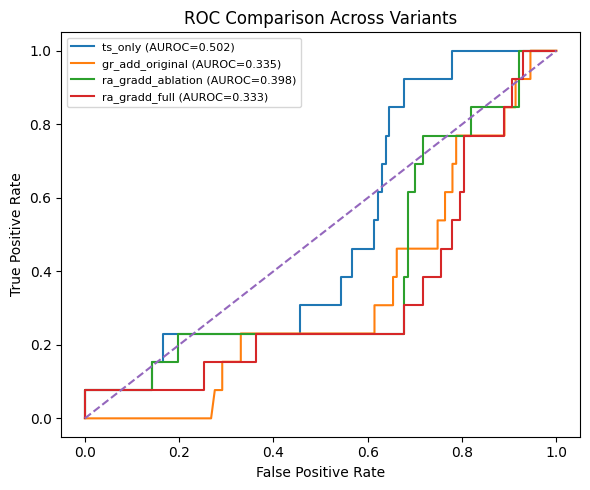

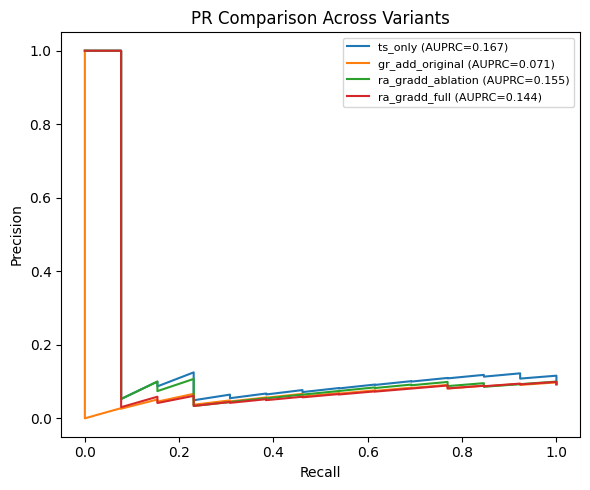

Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/all_variants_test_roc_comparison.png
Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/all_variants_test_pr_comparison.png


In [46]:
# ============================================================
# CELL 7: ROC + PR COMPARISON ACROSS VARIANTS
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

roc_fig = plt.figure(figsize=(6,5))
for variant, vdir in variant_dirs.items():
    pred_path = os.path.join(vdir, "test_best_predictions.csv")
    if not os.path.exists(pred_path):
        continue
    dfp = pd.read_csv(pred_path)
    if dfp["y_true"].nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(dfp["y_true"], dfp["y_prob"])
    auc = roc_auc_score(dfp["y_true"], dfp["y_prob"])
    plt.plot(fpr, tpr, label=f"{variant} (AUROC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison Across Variants")
plt.legend(fontsize=8)
plt.tight_layout()
roc_path = os.path.join(SAVE_ROOT, "all_variants_test_roc_comparison.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

pr_fig = plt.figure(figsize=(6,5))
for variant, vdir in variant_dirs.items():
    pred_path = os.path.join(vdir, "test_best_predictions.csv")
    if not os.path.exists(pred_path):
        continue
    dfp = pd.read_csv(pred_path)
    if dfp["y_true"].nunique() < 2:
        continue
    precision, recall, _ = precision_recall_curve(dfp["y_true"], dfp["y_prob"])
    ap = average_precision_score(dfp["y_true"], dfp["y_prob"])
    plt.plot(recall, precision, label=f"{variant} (AUPRC={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Comparison Across Variants")
plt.legend(fontsize=8)
plt.tight_layout()
pr_path = os.path.join(SAVE_ROOT, "all_variants_test_pr_comparison.png")
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)
print("Saved:", pr_path)

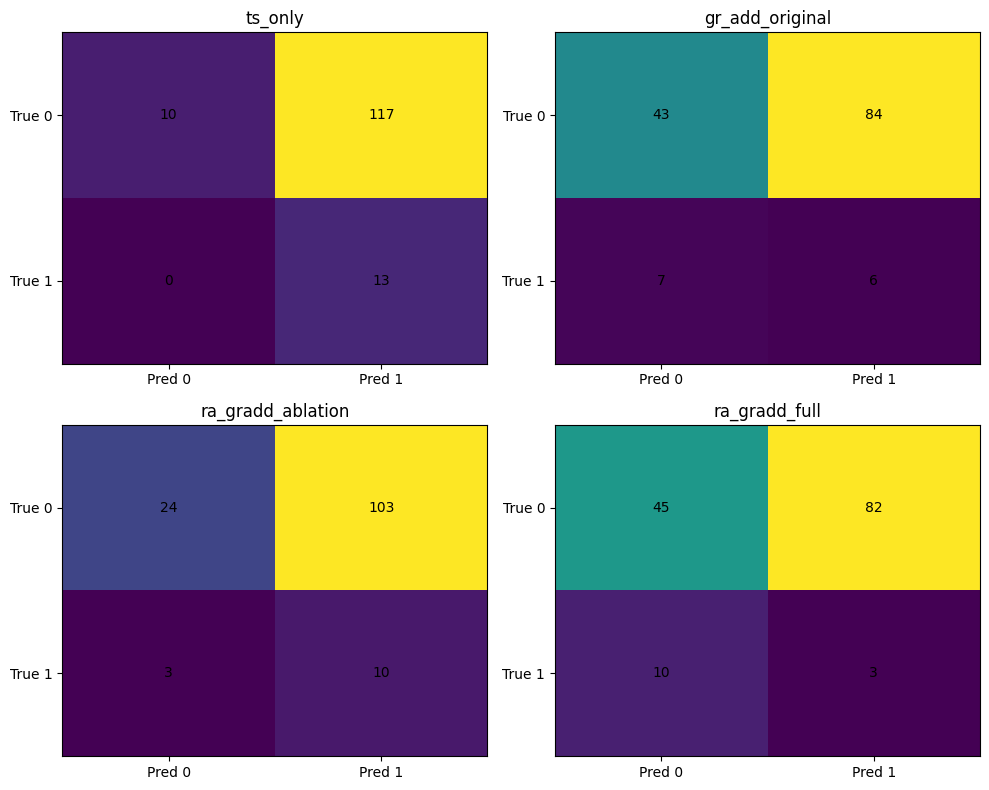

Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/all_variants_test_confusion_matrices.png


In [47]:
# ============================================================
# CELL 8: CONFUSION MATRICES FOR ALL 4 VARIANTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (variant, vdir) in zip(axes, variant_dirs.items()):
    pred_path = os.path.join(vdir, "test_best_predictions.csv")
    if not os.path.exists(pred_path):
        ax.axis("off")
        continue
    dfp = pd.read_csv(pred_path)
    cm = confusion_matrix(dfp["y_true"], dfp["y_pred"])
    ax.imshow(cm, aspect="auto")
    ax.set_title(variant)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticklabels(["True 0","True 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
cm_panel_path = os.path.join(SAVE_ROOT, "all_variants_test_confusion_matrices.png")
plt.savefig(cm_panel_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_panel_path)

Best variant: ts_only
Baseline AUROC: 0.5015142337976983
Baseline F1: 0.18181818181818182


,feature_group,type,baseline_auroc,permuted_auroc,auroc_drop,baseline_f1,permuted_f1,f1_drop
0,open,time_series_variable,0.501514,0.468201,0.033313,0.181818,0.180556,0.001263
1,high,time_series_variable,0.501514,0.490612,0.010902,0.181818,0.180556,0.001263
2,low,time_series_variable,0.501514,0.493640,0.007874,0.181818,0.178082,0.003736
3,close,time_series_variable,0.501514,0.495457,0.006057,0.181818,0.183099,-0.001280
6,text_block,text,0.501514,0.501514,0.000000,0.181818,0.181818,0.000000
4,adj_close,time_series_variable,0.501514,0.502120,-0.000606,0.181818,0.181818,0.000000
5,volume,time_series_variable,0.501514,0.502423,-0.000909,0.181818,0.185714,-0.003896


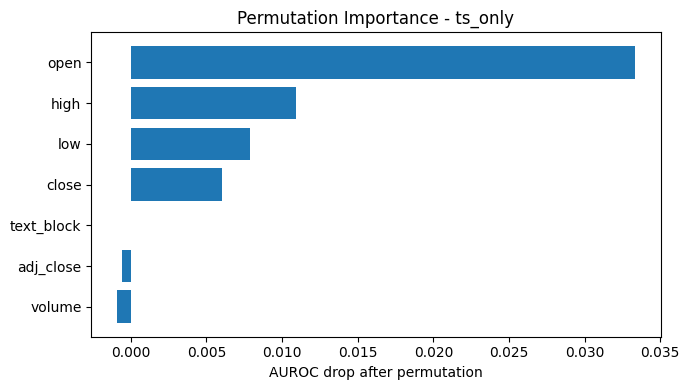

Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ts_only/permutation_importance_variable_groups.csv
Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ts_only/permutation_importance_variable_groups.png


In [48]:
# ============================================================
# CELL 9: PERMUTATION IMPORTANCE FOR BEST VARIANT
# ============================================================

best_model_lookup = {
    "ts_only": model_ts_only,
    "gr_add_original": model_gr_add,
    "ra_gradd_ablation": model_ra_ablation,
    "ra_gradd_full": model_ra_full,
}
best_model = best_model_lookup[best_variant]
best_run_dir = variant_dirs[best_variant]

variable_names = [f"var_{i}" for i in range(args.C)]
if args.C == 6:
    variable_names = ["open", "high", "low", "close", "adj_close", "volume"]

def get_test_predictions_from_loader(model, loader):
    model.eval()
    probs_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch, model, args)
            labels = build_labels_from_batch(batch, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)
            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())
    return np.array(labels_all), np.array(probs_all)

baseline_y, baseline_prob = get_test_predictions_from_loader(best_model, test_loader)
baseline_auc = roc_auc_score(baseline_y, baseline_prob) if len(np.unique(baseline_y)) > 1 else np.nan
baseline_f1 = f1_score(baseline_y, (baseline_prob >= 0.5).astype(int), zero_division=0)

print("Best variant:", best_variant)
print("Baseline AUROC:", baseline_auc)
print("Baseline F1:", baseline_f1)

def permuted_eval(model, loader, permute_var_idx=None, permute_text=False):
    model.eval()
    probs_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch2 = {}
            for k, v in batch.items():
                batch2[k] = v.clone() if torch.is_tensor(v) else v

            if permute_var_idx is not None:
                x = batch2["observed_data"]
                m = batch2["observed_mask"]
                p = torch.randperm(x.shape[0])
                x[..., permute_var_idx] = x[p, ..., permute_var_idx]
                m[..., permute_var_idx] = m[p, ..., permute_var_idx]
                batch2["observed_data"] = x
                batch2["observed_mask"] = m

            if permute_text:
                t = batch2["notes_embeddings"]
                p = torch.randperm(t.shape[0])
                batch2["notes_embeddings"] = t[p]

            X_final, mask_flat, text_emb, text_mask, B = preprocess_batch_for_tpatch(batch2, model, args)
            labels = build_labels_from_batch(batch2, args.device)
            probs = model(X_final, mask_flat, text_emb, text_mask, B)

            probs_all.extend(probs.detach().cpu().numpy().reshape(-1).tolist())
            labels_all.extend(labels.detach().cpu().numpy().reshape(-1).astype(int).tolist())

    y = np.array(labels_all)
    pr = np.array(probs_all)
    auc = roc_auc_score(y, pr) if len(np.unique(y)) > 1 else np.nan
    f1 = f1_score(y, (pr >= 0.5).astype(int), zero_division=0)
    return auc, f1

importance_rows = []

for j, vname in enumerate(variable_names):
    auc_j, f1_j = permuted_eval(best_model, test_loader, permute_var_idx=j, permute_text=False)
    importance_rows.append({
        "feature_group": vname,
        "type": "time_series_variable",
        "baseline_auroc": baseline_auc,
        "permuted_auroc": auc_j,
        "auroc_drop": baseline_auc - auc_j if pd.notnull(baseline_auc) and pd.notnull(auc_j) else np.nan,
        "baseline_f1": baseline_f1,
        "permuted_f1": f1_j,
        "f1_drop": baseline_f1 - f1_j
    })

auc_t, f1_t = permuted_eval(best_model, test_loader, permute_var_idx=None, permute_text=True)
importance_rows.append({
    "feature_group": "text_block",
    "type": "text",
    "baseline_auroc": baseline_auc,
    "permuted_auroc": auc_t,
    "auroc_drop": baseline_auc - auc_t if pd.notnull(baseline_auc) and pd.notnull(auc_t) else np.nan,
    "baseline_f1": baseline_f1,
    "permuted_f1": f1_t,
    "f1_drop": baseline_f1 - f1_t
})

importance_df = pd.DataFrame(importance_rows).sort_values("auroc_drop", ascending=False)
importance_path = os.path.join(best_run_dir, "permutation_importance_variable_groups.csv")
importance_df.to_csv(importance_path, index=False)
display(importance_df)

plt.figure(figsize=(7,4))
plt.barh(importance_df["feature_group"], importance_df["auroc_drop"])
plt.gca().invert_yaxis()
plt.xlabel("AUROC drop after permutation")
plt.title(f"Permutation Importance - {best_variant}")
plt.tight_layout()
imp_plot_path = os.path.join(best_run_dir, "permutation_importance_variable_groups.png")
plt.savefig(imp_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", importance_path)
print("Saved:", imp_plot_path)

pooled_text shape: (140, 768)
predictions shape: (140, 3)


,text_dim,dim_index,abs_mean_score
0,text_dim_447,447,307.724091
1,text_dim_138,138,78.116737
2,text_dim_64,64,19.322437
3,text_dim_373,373,16.469332
4,text_dim_266,266,14.238848
5,text_dim_393,393,10.784311
6,text_dim_526,526,10.459091
7,text_dim_326,326,10.348841
8,text_dim_640,640,8.951814
9,text_dim_756,756,7.092137


Compiled notes: (20850, 3)


,term,mean_tfidf
0,00,0.233217
1,00 00,0.155456
2,10,0.031080
3,08,0.030409
4,11,0.030308
5,07,0.030164
6,03,0.030142
7,02,0.029939
8,12,0.029772
9,06,0.029736


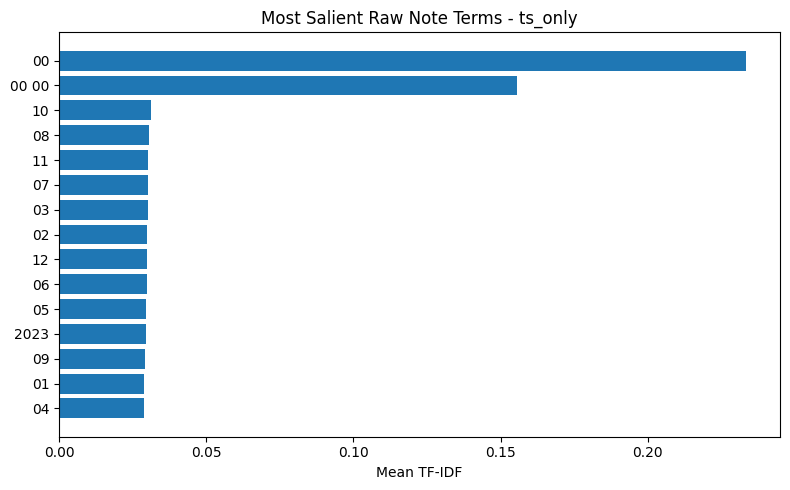

Saved compiled notes and TF-IDF summaries to: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_ablation_runs/ts_only


In [49]:
# ============================================================
# CELL 10: MAKE TEXT IMPORTANCE MORE INTERPRETABLE
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

best_run_dir = variant_dirs[best_variant]
pooled_text_path = os.path.join(best_run_dir, "test_best_pooled_text.npy")
pred_path = os.path.join(best_run_dir, "test_best_predictions.csv")

if not os.path.exists(pooled_text_path):
    raise FileNotFoundError(f"Missing pooled text file: {pooled_text_path}")

pooled_text = np.load(pooled_text_path)
pred_df = pd.read_csv(pred_path)

print("pooled_text shape:", pooled_text.shape)
print("predictions shape:", pred_df.shape)

# identify top text dimensions by variance / absolute mean
text_dim_scores = np.abs(pooled_text).mean(axis=0)
top_dims = np.argsort(-text_dim_scores)[:10]

text_dim_df = pd.DataFrame({
    "text_dim": [f"text_dim_{d}" for d in top_dims],
    "dim_index": top_dims,
    "abs_mean_score": text_dim_scores[top_dims]
})
text_dim_df.to_csv(os.path.join(best_run_dir, "top_text_dims_by_abs_mean.csv"), index=False)
display(text_dim_df)

# collect raw notes
fnspid_root = os.path.join(DATA_ROOT, "FNSPID", "processed")
note_rows = []

for rec in sorted(os.listdir(fnspid_root)):
    text_csv = os.path.join(fnspid_root, rec, "text.csv")
    if os.path.exists(text_csv):
        try:
            tmp = pd.read_csv(text_csv)
            txt_col = "text" if "text" in tmp.columns else tmp.columns[0]
            for i, txt in enumerate(tmp[txt_col].fillna("").astype(str).tolist()):
                note_rows.append({
                    "record": rec,
                    "note_idx": i,
                    "text": txt
                })
        except Exception as e:
            print("Skipping", text_csv, "due to", e)

notes_df = pd.DataFrame(note_rows)
notes_df = notes_df[notes_df["text"].str.strip() != ""].copy()
notes_df.to_csv(os.path.join(best_run_dir, "all_raw_notes_compiled.csv"), index=False)

print("Compiled notes:", notes_df.shape)

# overall top tf-idf words
vec = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)
X = vec.fit_transform(notes_df["text"])
terms = np.array(vec.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
top_idx = np.argsort(-mean_tfidf)[:40]

top_words_df = pd.DataFrame({
    "term": terms[top_idx],
    "mean_tfidf": mean_tfidf[top_idx]
})
top_words_df.to_csv(os.path.join(best_run_dir, "overall_top_tfidf_terms.csv"), index=False)
display(top_words_df.head(20))

# optional rough interpretation of top embedding dims:
# since we do not have exact test-note alignment here, use all raw notes and report top words overall
# plus save representative raw notes for manual review
sample_notes_df = notes_df.sample(min(50, len(notes_df)), random_state=42)
sample_notes_df.to_csv(os.path.join(best_run_dir, "sample_raw_notes_for_manual_review.csv"), index=False)

plt.figure(figsize=(8,5))
plot_df = top_words_df.head(15).iloc[::-1]
plt.barh(plot_df["term"], plot_df["mean_tfidf"])
plt.xlabel("Mean TF-IDF")
plt.title(f"Most Salient Raw Note Terms - {best_variant}")
plt.tight_layout()
tfidf_plot_path = os.path.join(best_run_dir, "top_raw_note_terms.png")
plt.savefig(tfidf_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved compiled notes and TF-IDF summaries to:", best_run_dir)

In [50]:
# --- Inspect what FNSPID labels mean ---
import os, sys, inspect, textwrap, re
from pathlib import Path

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data/FNSPID"

# 1) show dataset files
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith((".py", ".csv", ".txt")) and ("label" in f.lower() or "meta" in f.lower() or "processed" in root):
            print(os.path.join(root, f))

# 2) inspect parse_datasets source around FNSPID handling
sys.path.insert(0, REPO_ROOT)
from lib import parse_datasets as pdmod

src = inspect.getsource(pdmod)
for pat in ["FNSPID", "label", "classification", "pred_window", "tp_to_predict"]:
    print(f"\n\n===== SEARCH: {pat} =====")
    for m in re.finditer(pat, src):
        start = max(0, m.start()-400)
        end = min(len(src), m.end()+700)
        print(src[start:end])
        print("\n" + "-"*80)

# 3) if your loaded dataframe exists, inspect label distribution
if "results_df" in globals():
    print(results_df["label"].value_counts(dropna=False))

/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/embedding_generation_summary.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMAT/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMT/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/AMT/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/DVN/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/DVN/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EA/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EA/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EXPE/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/EXPE/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/KO/time_series.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/KO/text.csv
/content/drive/MyDrive/IMM-TSF/data/FNSPID/processed/PEP/text.csv
/content/drive

In [51]:
# =========================================================
# CLEAN DIAGNOSTIC CELL:
# 1) checks whether scores are inverted
# 2) tunes threshold on validation set
# 3) evaluates original vs inverted probabilities on test
# 4) reports whether GR-Add looks salvageable
#
# EXPECTATION:
# You already have a dict called `all_results` in memory with structure:
#
# all_results = {
#   "ts_only": {
#       "y_val": ...,
#       "p_val": ...,
#       "y_test": ...,
#       "p_test": ...
#   },
#   "gr_add_original": {...},
#   "ra_gradd_ablation": {...},
#   "ra_gradd_full": {...}
# }
#
# where p_* are probabilities for class 1.
#
# If your object names differ, edit the section:
#    RESULTS_OBJECT = ...
# =========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, f1_score, balanced_accuracy_score, precision_score,
    recall_score, matthews_corrcoef
)

# ---------------------------------------------------------
# EDIT THIS IF NEEDED
# ---------------------------------------------------------
RESULTS_OBJECT = all_results  # <-- change if your dict has a different name

SAVE_DIR = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_diagnostics"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def to_1d(x):
    x = np.asarray(x)
    return x.reshape(-1)

def safe_auc(y, p):
    y = to_1d(y)
    p = to_1d(p)
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def safe_ap(y, p):
    y = to_1d(y)
    p = to_1d(p)
    if len(np.unique(y)) < 2:
        return np.nan
    return average_precision_score(y, p)

def evaluate_at_threshold(y, p, thr):
    y = to_1d(y).astype(int)
    p = to_1d(p).astype(float)
    pred = (p >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

    out = {
        "threshold": float(thr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "recall": recall_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0,
    }
    return out

def tune_threshold(y_val, p_val, metric="f1"):
    y_val = to_1d(y_val).astype(int)
    p_val = to_1d(p_val).astype(float)

    thresholds = np.unique(np.concatenate([
        np.linspace(0.01, 0.99, 199),
        p_val
    ]))
    thresholds = np.clip(thresholds, 1e-6, 1 - 1e-6)

    rows = []
    for thr in thresholds:
        ev = evaluate_at_threshold(y_val, p_val, thr)
        rows.append(ev)

    df = pd.DataFrame(rows).sort_values(metric, ascending=False).reset_index(drop=True)
    best = df.iloc[0].to_dict()
    return best, df

def summarize_salvageability(best_auc, flipped_auc, best_bal_acc, best_f1):
    # Simple practical interpretation
    # - if flipping helps a lot, likely inversion/sign bug
    # - if tuned threshold helps but AUROC still poor, not salvageable in current setup
    # - if AUROC improves to decent range, maybe salvageable
    if np.isnan(best_auc) or np.isnan(flipped_auc):
        return "Cannot determine; one of the classes is missing."

    best_rank_auc = max(best_auc, flipped_auc)
    inversion_gain = flipped_auc - best_auc

    if inversion_gain > 0.10 and flipped_auc >= 0.55:
        return "Likely salvageable: probabilities appear inverted or score direction is wrong."
    elif best_rank_auc >= 0.60 and (best_bal_acc >= 0.55 or best_f1 >= 0.30):
        return "Possibly salvageable: ranking is modest but thresholding/calibration may help."
    elif best_rank_auc >= 0.55:
        return "Marginally salvageable: weak signal exists, but likely needs loss/label/model changes."
    else:
        return "Not salvageable in current form: little evidence of useful ranking signal."

# ---------------------------------------------------------
# MAIN DIAGNOSTIC LOOP
# ---------------------------------------------------------
summary_rows = []
roc_plot_data = []
pr_plot_data = {}

for variant, res in RESULTS_OBJECT.items():
    required = ["y_val", "p_val", "y_test", "p_test"]
    missing = [k for k in required if k not in res]
    if missing:
        print(f"Skipping {variant}: missing keys {missing}")
        continue

    y_val = to_1d(res["y_val"]).astype(int)
    p_val = np.clip(to_1d(res["p_val"]).astype(float), 1e-6, 1 - 1e-6)
    y_test = to_1d(res["y_test"]).astype(int)
    p_test = np.clip(to_1d(res["p_test"]).astype(float), 1e-6, 1 - 1e-6)

    # Base ranking
    val_auc = safe_auc(y_val, p_val)
    test_auc = safe_auc(y_test, p_test)
    test_ap = safe_ap(y_test, p_test)

    # Inversion check
    val_auc_flip = safe_auc(y_val, 1 - p_val)
    test_auc_flip = safe_auc(y_test, 1 - p_test)
    test_ap_flip = safe_ap(y_test, 1 - p_test)

    invert_scores = False
    if not np.isnan(val_auc) and not np.isnan(val_auc_flip):
        invert_scores = val_auc_flip > val_auc

    p_val_used = 1 - p_val if invert_scores else p_val
    p_test_used = 1 - p_test if invert_scores else p_test

    # Threshold tuning on validation
    best_thr_f1, thr_table_f1 = tune_threshold(y_val, p_val_used, metric="f1")
    best_thr_bacc, thr_table_bacc = tune_threshold(y_val, p_val_used, metric="balanced_accuracy")

    # Choose threshold by balanced accuracy first for imbalanced data
    chosen = best_thr_bacc
    chosen_metric = "balanced_accuracy"

    test_eval = evaluate_at_threshold(y_test, p_test_used, chosen["threshold"])
    test_eval_f1thr = evaluate_at_threshold(y_test, p_test_used, best_thr_f1["threshold"])

    salvage = summarize_salvageability(
        best_auc=max(test_auc, test_auc_flip),
        flipped_auc=test_auc_flip,
        best_bal_acc=test_eval["balanced_accuracy"],
        best_f1=test_eval["f1"]
    )

    row = {
        "variant": variant,
        "n_val": len(y_val),
        "n_test": len(y_test),
        "val_pos_rate": float(y_val.mean()),
        "test_pos_rate": float(y_test.mean()),
        "val_auc_original": val_auc,
        "val_auc_flipped": val_auc_flip,
        "test_auc_original": test_auc,
        "test_auc_flipped": test_auc_flip,
        "test_ap_original": test_ap,
        "test_ap_flipped": test_ap_flip,
        "inversion_helpful": bool(invert_scores),
        "chosen_threshold_metric": chosen_metric,
        "chosen_threshold": chosen["threshold"],
        "test_bal_acc": test_eval["balanced_accuracy"],
        "test_f1": test_eval["f1"],
        "test_precision": test_eval["precision"],
        "test_recall": test_eval["recall"],
        "test_specificity": test_eval["specificity"],
        "test_mcc": test_eval["mcc"],
        "tn": test_eval["tn"],
        "fp": test_eval["fp"],
        "fn": test_eval["fn"],
        "tp": test_eval["tp"],
        "salvageability": salvage,
    }
    summary_rows.append(row)

    # Save threshold tables
    thr_table_f1.to_csv(os.path.join(SAVE_DIR, f"{variant}_threshold_table_f1.csv"), index=False)
    thr_table_bacc.to_csv(os.path.join(SAVE_DIR, f"{variant}_threshold_table_balacc.csv"), index=False)

    # Save raw diagnostic json
    diag = {
        "variant": variant,
        "invert_scores": bool(invert_scores),
        "best_threshold_f1": best_thr_f1,
        "best_threshold_balanced_accuracy": best_thr_bacc,
        "test_eval_at_balacc_threshold": test_eval,
        "test_eval_at_f1_threshold": test_eval_f1thr,
        "salvageability": salvage,
    }
    with open(os.path.join(SAVE_DIR, f"{variant}_diagnostic.json"), "w") as f:
        json.dump(diag, f, indent=2)

    # ROC / PR plot data
    fpr, tpr, _ = roc_curve(y_test, p_test_used)
    roc_plot_data.append((variant, fpr, tpr, max(test_auc, test_auc_flip)))

    prec, rec, _ = precision_recall_curve(y_test, p_test_used)
    pr_plot_data[variant] = (rec, prec, max(test_ap, test_ap_flip))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, (p_test_used >= chosen["threshold"]).astype(int), labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"{variant}\nCM @ tuned threshold={chosen['threshold']:.3f}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{variant}_confusion_matrix_tuned.png"), dpi=200, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# SUMMARY TABLE
# ---------------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["test_auc_flipped", "test_bal_acc", "test_f1"], ascending=False
).reset_index(drop=True)

summary_csv = os.path.join(SAVE_DIR, "model_inversion_threshold_salvage_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nSaved summary to:")
print(summary_csv)

display(summary_df)

# ---------------------------------------------------------
# ROC COMPARISON
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
for variant, fpr, tpr, aucv in roc_plot_data:
    plt.plot(fpr, tpr, label=f"{variant} (best AUC={aucv:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC after inversion check")
plt.legend(fontsize=8)
plt.tight_layout()
roc_path = os.path.join(SAVE_DIR, "roc_after_inversion_check.png")
plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# PR COMPARISON
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
for variant, (rec, prec, apv) in pr_plot_data.items():
    plt.plot(rec, prec, label=f"{variant} (best AP={apv:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall after inversion check")
plt.legend(fontsize=8)
plt.tight_layout()
pr_path = os.path.join(SAVE_DIR, "pr_after_inversion_check.png")
plt.savefig(pr_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved plots:")
print(roc_path)
print(pr_path)

# ---------------------------------------------------------
# HUMAN-READABLE REPORT
# ---------------------------------------------------------
print("\n========== INTERPRETATION REPORT ==========\n")
for _, r in summary_df.iterrows():
    print(f"Variant: {r['variant']}")
    print(f"  Test prevalence: {r['test_pos_rate']:.3f}")
    print(f"  AUROC original: {r['test_auc_original']:.3f}")
    print(f"  AUROC flipped : {r['test_auc_flipped']:.3f}")
    print(f"  Inversion helpful? {r['inversion_helpful']}")
    print(f"  Tuned threshold: {r['chosen_threshold']:.3f} ({r['chosen_threshold_metric']})")
    print(f"  Test balanced acc: {r['test_bal_acc']:.3f}")
    print(f"  Test F1: {r['test_f1']:.3f}")
    print(f"  Test precision: {r['test_precision']:.3f}")
    print(f"  Test recall: {r['test_recall']:.3f}")
    print(f"  Test specificity: {r['test_specificity']:.3f}")
    print(f"  Confusion matrix: TN={int(r['tn'])}, FP={int(r['fp'])}, FN={int(r['fn'])}, TP={int(r['tp'])}")
    print(f"  Salvageability: {r['salvageability']}")
    print("-" * 70)

Skipping threshold: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping accuracy: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping precision: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping recall: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping f1: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping n: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping n_pos: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping n_neg: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping auroc: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping auprc: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping split: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping loss: missing keys ['y_val', 'p_val', 'y_test', 'p_test']
Skipping variant: missing keys ['y_val', 'p_val', 'y_test', 'p_test']


KeyError: 'test_auc_flipped'

In [52]:
# =========================================================
# ROBUST DIAGNOSTIC CELL
# Finds the correct multi-variant results object in memory,
# checks inversion, tunes threshold, and reports salvageability
# =========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, f1_score, balanced_accuracy_score, precision_score,
    recall_score, matthews_corrcoef
)

SAVE_DIR = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_tpatch_diagnostics"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def to_1d(x):
    return np.asarray(x).reshape(-1)

def looks_like_variant_payload(obj):
    return isinstance(obj, dict) and all(k in obj for k in ["y_val", "p_val", "y_test", "p_test"])

def looks_like_multivariant_payload(obj):
    if not isinstance(obj, dict) or len(obj) == 0:
        return False
    values = list(obj.values())
    return any(looks_like_variant_payload(v) for v in values)

def safe_auc(y, p):
    y = to_1d(y)
    p = to_1d(p)
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def safe_ap(y, p):
    y = to_1d(y)
    p = to_1d(p)
    if len(np.unique(y)) < 2:
        return np.nan
    return average_precision_score(y, p)

def evaluate_at_threshold(y, p, thr):
    y = to_1d(y).astype(int)
    p = to_1d(p).astype(float)
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(thr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "recall": recall_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0,
    }

def tune_threshold(y_val, p_val, metric="balanced_accuracy"):
    y_val = to_1d(y_val).astype(int)
    p_val = to_1d(p_val).astype(float)
    thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), p_val]))
    thresholds = np.clip(thresholds, 1e-6, 1 - 1e-6)

    rows = []
    for thr in thresholds:
        rows.append(evaluate_at_threshold(y_val, p_val, thr))
    df = pd.DataFrame(rows).sort_values(metric, ascending=False).reset_index(drop=True)
    return df.iloc[0].to_dict(), df

def summarize_salvageability(best_auc, flipped_auc, best_bal_acc, best_f1):
    if np.isnan(best_auc) or np.isnan(flipped_auc):
        return "Cannot determine; one class may be missing."

    inversion_gain = flipped_auc - best_auc
    best_rank_auc = max(best_auc, flipped_auc)

    if inversion_gain > 0.10 and flipped_auc >= 0.55:
        return "Likely salvageable: score direction may be inverted."
    elif best_rank_auc >= 0.60 and (best_bal_acc >= 0.55 or best_f1 >= 0.30):
        return "Possibly salvageable with calibration/threshold tuning."
    elif best_rank_auc >= 0.55:
        return "Weakly salvageable; signal is faint."
    else:
        return "Not salvageable in current form; little ranking signal."

# ---------------------------------------------------------
# AUTO-DETECT CANDIDATE OBJECTS
# ---------------------------------------------------------
candidate_names = []
for name, obj in globals().items():
    if looks_like_multivariant_payload(obj):
        candidate_names.append(name)

print("Possible multi-variant result objects found:")
for name in candidate_names:
    print(" -", name)

if len(candidate_names) == 0:
    raise ValueError(
        "No multi-variant object with {'y_val','p_val','y_test','p_test'} payloads was found in memory.\n"
        "You likely only saved summary metrics, not raw validation/test probabilities.\n\n"
        "You need the object from the training/evaluation cell that stored per-variant:\n"
        "  y_val, p_val, y_test, p_test\n"
    )

# Pick the first candidate automatically; change if needed
RESULTS_OBJECT_NAME = candidate_names[0]
RESULTS_OBJECT = globals()[RESULTS_OBJECT_NAME]

print(f"\nUsing results object: {RESULTS_OBJECT_NAME}")

# ---------------------------------------------------------
# FILTER TO VALID VARIANTS ONLY
# ---------------------------------------------------------
valid_results = {}
for k, v in RESULTS_OBJECT.items():
    if looks_like_variant_payload(v):
        valid_results[k] = v
    else:
        print(f"Skipping {k}: payload does not contain y_val/p_val/y_test/p_test")

if len(valid_results) == 0:
    raise ValueError("Found the outer object, but none of its variants contain raw prediction arrays.")

print("\nValid variants found:")
for k in valid_results:
    print(" -", k)

# ---------------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------------
summary_rows = []
roc_plot_data = []
pr_plot_data = {}

for variant, res in valid_results.items():
    y_val = to_1d(res["y_val"]).astype(int)
    p_val = np.clip(to_1d(res["p_val"]).astype(float), 1e-6, 1 - 1e-6)
    y_test = to_1d(res["y_test"]).astype(int)
    p_test = np.clip(to_1d(res["p_test"]).astype(float), 1e-6, 1 - 1e-6)

    val_auc_orig = safe_auc(y_val, p_val)
    val_auc_flip = safe_auc(y_val, 1 - p_val)
    test_auc_orig = safe_auc(y_test, p_test)
    test_auc_flip = safe_auc(y_test, 1 - p_test)
    test_ap_orig = safe_ap(y_test, p_test)
    test_ap_flip = safe_ap(y_test, 1 - p_test)

    invert_scores = val_auc_flip > val_auc_orig
    p_val_used = 1 - p_val if invert_scores else p_val
    p_test_used = 1 - p_test if invert_scores else p_test

    best_thr, thr_table = tune_threshold(y_val, p_val_used, metric="balanced_accuracy")
    test_eval = evaluate_at_threshold(y_test, p_test_used, best_thr["threshold"])

    salvage = summarize_salvageability(
        best_auc=test_auc_orig,
        flipped_auc=test_auc_flip,
        best_bal_acc=test_eval["balanced_accuracy"],
        best_f1=test_eval["f1"]
    )

    row = {
        "variant": variant,
        "n_val": len(y_val),
        "n_test": len(y_test),
        "val_pos_rate": float(y_val.mean()),
        "test_pos_rate": float(y_test.mean()),
        "val_auc_original": val_auc_orig,
        "val_auc_flipped": val_auc_flip,
        "test_auc_original": test_auc_orig,
        "test_auc_flipped": test_auc_flip,
        "test_ap_original": test_ap_orig,
        "test_ap_flipped": test_ap_flip,
        "inversion_helpful": bool(invert_scores),
        "chosen_threshold": float(best_thr["threshold"]),
        "test_bal_acc": test_eval["balanced_accuracy"],
        "test_f1": test_eval["f1"],
        "test_precision": test_eval["precision"],
        "test_recall": test_eval["recall"],
        "test_specificity": test_eval["specificity"],
        "test_mcc": test_eval["mcc"],
        "tn": test_eval["tn"],
        "fp": test_eval["fp"],
        "fn": test_eval["fn"],
        "tp": test_eval["tp"],
        "salvageability": salvage,
    }
    summary_rows.append(row)

    thr_table.to_csv(os.path.join(SAVE_DIR, f"{variant}_threshold_scan.csv"), index=False)

    fpr, tpr, _ = roc_curve(y_test, p_test_used)
    roc_plot_data.append((variant, fpr, tpr, max(test_auc_orig, test_auc_flip)))

    prec, rec, _ = precision_recall_curve(y_test, p_test_used)
    pr_plot_data[variant] = (rec, prec, max(test_ap_orig, test_ap_flip))

    cm = confusion_matrix(y_test, (p_test_used >= best_thr["threshold"]).astype(int), labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"{variant}\nCM @ tuned threshold={best_thr['threshold']:.3f}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{variant}_confusion_matrix_tuned.png"), dpi=200, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    raise ValueError("No valid variants were processed.")

summary_df = summary_df.sort_values(
    ["test_auc_flipped", "test_bal_acc", "test_f1"],
    ascending=False
).reset_index(drop=True)

summary_path = os.path.join(SAVE_DIR, "salvage_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("\nSaved summary to:")
print(summary_path)
display(summary_df)

# ---------------------------------------------------------
# ROC PLOT
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
for variant, fpr, tpr, aucv in roc_plot_data:
    plt.plot(fpr, tpr, label=f"{variant} (best AUC={aucv:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC after inversion check")
plt.legend(fontsize=8)
plt.tight_layout()
roc_path = os.path.join(SAVE_DIR, "roc_after_inversion_check.png")
plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# PR PLOT
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
for variant, (rec, prec, apv) in pr_plot_data.items():
    plt.plot(rec, prec, label=f"{variant} (best AP={apv:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall after inversion check")
plt.legend(fontsize=8)
plt.tight_layout()
pr_path = os.path.join(SAVE_DIR, "pr_after_inversion_check.png")
plt.savefig(pr_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved plots:")
print(roc_path)
print(pr_path)

print("\n========== INTERPRETATION REPORT ==========\n")
for _, r in summary_df.iterrows():
    print(f"Variant: {r['variant']}")
    print(f"  AUROC original: {r['test_auc_original']:.3f}")
    print(f"  AUROC flipped : {r['test_auc_flipped']:.3f}")
    print(f"  Inversion helpful? {r['inversion_helpful']}")
    print(f"  Tuned threshold: {r['chosen_threshold']:.3f}")
    print(f"  Balanced acc: {r['test_bal_acc']:.3f}")
    print(f"  F1: {r['test_f1']:.3f}")
    print(f"  Precision: {r['test_precision']:.3f}")
    print(f"  Recall: {r['test_recall']:.3f}")
    print(f"  Specificity: {r['test_specificity']:.3f}")
    print(f"  Confusion matrix: TN={int(r['tn'])}, FP={int(r['fp'])}, FN={int(r['fn'])}, TP={int(r['tp'])}")
    print(f"  Salvageability: {r['salvageability']}")
    print("-" * 70)

RuntimeError: dictionary changed size during iteration

In [53]:
# =========================================================
# FNSPID LABEL REBUILD:
# binary target = forward return > threshold
# =========================================================

import torch

# ---- SETTINGS ----
RETURN_THRESHOLD = 0.005   # 0.5%; try 0.01 for 1%
PRICE_FEATURE_INDEX = 0    # change if your price column is not index 0

def make_binary_return_label(batch,
                             price_idx=PRICE_FEATURE_INDEX,
                             return_threshold=RETURN_THRESHOLD):
    """
    Creates binary labels:
        1 if forward return > threshold
        0 otherwise

    Assumes:
      batch["observed_data"] shape ~ [B, npatch, plen, C]
      batch["data_to_predict"] shape ~ [B, Tpred, C]

    Uses:
      current_price = last observed value of chosen price feature
      future_price  = last prediction target value of chosen price feature
    """
    obs = batch["observed_data"]          # [B, npatch, plen, C]
    fut = batch["data_to_predict"]        # [B, Tpred, C]

    current_price = obs[:, -1, -1, price_idx]   # last observed patch, last timepoint
    future_price  = fut[:, -1, price_idx]        # last future target point

    forward_return = (future_price - current_price) / (current_price.abs() + 1e-8)
    labels = (forward_return > return_threshold).float()

    return labels, forward_return, current_price, future_price

# ---------------------------------------------------------
# QUICK CHECK ON ONE BATCH
# ---------------------------------------------------------
batch = next(iter(data_obj["train_dataloader"]))

labels, fwd_ret, curr_p, fut_p = make_binary_return_label(
    batch,
    price_idx=PRICE_FEATURE_INDEX,
    return_threshold=RETURN_THRESHOLD
)

print("Current price sample:", curr_p[:10].detach().cpu().numpy())
print("Future price sample :", fut_p[:10].detach().cpu().numpy())
print("Forward return sample:", fwd_ret[:10].detach().cpu().numpy())
print("Binary labels sample :", labels[:10].detach().cpu().numpy())
print("Positive rate in batch:", labels.mean().item())

Current price sample: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Future price sample : [-0.74770343 -1.2217122   3.098702   -1.7235956   1.1039456   4.7395935
  0.75409436  0.41719222  0.00878213 -0.9090671 ]
Forward return sample: [-7.47703440e+07 -1.22171224e+08  3.09870208e+08 -1.72359568e+08
  1.10394560e+08  4.73959360e+08  7.54094400e+07  4.17192240e+07
  8.78212688e+05 -9.09067120e+07]
Binary labels sample : [0. 0. 1. 0. 1. 1. 1. 1. 1. 0.]
Positive rate in batch: 0.40625


In [54]:
# =========================================================
# FNSPID MASTER NOTEBOOK PIPELINE
# Stable notebook version using tPatch-formatted batches
# with 4 variants:
#   1) ts_only
#   2) gr_add_original
#   3) ra_gradd_ablation
#   4) ra_gradd_full
#
# Outcome:
#   binary forward return > threshold
#
# Saves to Google Drive:
#   metrics, predictions, ROC/PR, confusion matrices,
#   threshold scans, and feature importance figures
# =========================================================

# -----------------------------
# 0) SETUP
# -----------------------------
import os
import sys
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_forward_return"
os.makedirs(SAVE_ROOT, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# repo imports
from lib.parse_datasets import parse_datasets
from main import update_args_for_dataset, update_args_for_model

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from types import SimpleNamespace

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# 1) CONFIG
# -----------------------------
CFG = SimpleNamespace(
    dataset="FNSPID",
    data_root=DATA_ROOT,
    device=DEVICE,
    batch_size=32,
    epoch=20,
    lr=1e-3,
    weight_decay=1e-4,
    dropout=0.25,
    hid_dim=64,
    text_dim_in=768,
    text_proj_dim=64,
    ts_proj_dim=64,
    out_dim=1,

    enable_text=True,
    use_text_embeddings=True,
    llm_model_fusion="GPT2",
    llm_layers_fusion=6,
    max_length=1024,

    history=120,
    pred_window=1,
    stride=24,
    patch_size=24,
    npatch=5,
    patch_stride=24,

    task_type="classification",
    model="tPatchGNN",   # still parse with tPatch-style batching
    nlayer=2,
    n_heads=1,
    tf_layer=1,
    hop=2,
    outlayer="Linear",

    # label settings
    price_feature_index=0,    # change if needed
    return_threshold=0.005,   # 0.5%; try 0.01 too
)

# -----------------------------
# 2) LOAD DATA
# -----------------------------
args = SimpleNamespace(**CFG.__dict__)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

print("Loaded successfully.")
print("input_dim:", data_obj["input_dim"])
print("train batches:", len(data_obj["train_dataloader"]))
print("val batches:", len(data_obj["val_dataloader"]))
print("test batches:", len(data_obj["test_dataloader"]))

sample_batch = next(iter(data_obj["train_dataloader"]))
print("\nBatch keys:", list(sample_batch.keys()))
for k, v in sample_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

# -----------------------------
# 3) LABEL FUNCTION
# -----------------------------
def make_binary_return_label(batch, price_idx=0, return_threshold=0.005):
    """
    Binary label:
        1 if forward return > threshold
        0 otherwise

    current_price = last observed value of selected feature
    future_price  = last future target value of selected feature
    """
    obs = batch["observed_data"]      # [B, npatch, plen, C]
    fut = batch["data_to_predict"]    # [B, Tpred, C]

    current_price = obs[:, -1, -1, price_idx]
    future_price  = fut[:, -1, price_idx]

    forward_return = (future_price - current_price) / (current_price.abs() + 1e-8)
    labels = (forward_return > return_threshold).float()
    return labels, forward_return, current_price, future_price

# quick prevalence check
def check_prevalence(loader, split_name, price_idx, threshold):
    ys = []
    for batch in loader:
        y, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)
        ys.append(y.detach().cpu())
    ys = torch.cat(ys).numpy()
    return {
        "split": split_name,
        "n": len(ys),
        "positive_rate": float(ys.mean()),
        "n_pos": int(ys.sum()),
        "n_neg": int(len(ys) - ys.sum())
    }

prev_rows = []
for split_name, loader_key in [("train","train_dataloader"),("val","val_dataloader"),("test","test_dataloader")]:
    prev_rows.append(check_prevalence(data_obj[loader_key], split_name, CFG.price_feature_index, CFG.return_threshold))
prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv(os.path.join(SAVE_ROOT, "class_balance_forward_return.csv"), index=False)
print("\nClass balance:")
display(prev_df)

# -----------------------------
# 4) BATCH -> FEATURES
# -----------------------------
def masked_mean(x, m, dim, keepdim=False):
    num = (x * m).sum(dim=dim, keepdim=keepdim)
    den = m.sum(dim=dim, keepdim=keepdim).clamp_min(1e-6)
    return num / den

def summarize_batch(batch):
    """
    Convert tPatch batch into stable notebook features.
    Output:
      ts_summary: [B, D_ts]
      text_seq:   [B, T_text, D_text]
      text_mask:  [B, T_text]
    """
    obs_x = batch["observed_data"].float().to(DEVICE)   # [B, npatch, plen, C]
    obs_m = batch["observed_mask"].float().to(DEVICE)   # [B, npatch, plen, C]
    obs_t = batch["observed_tp"].float().to(DEVICE)     # [B, npatch, plen, C]
    tau   = batch["tau"].float().to(DEVICE)             # [B, T_text]
    txt   = batch["notes_embeddings"].float().to(DEVICE)  # [B, T_text, Dtxt]

    B, NP, PL, C = obs_x.shape
    Ttxt = txt.shape[1]

    # flatten patch/time dims
    x_flat = obs_x.reshape(B, NP * PL, C)
    m_flat = obs_m.reshape(B, NP * PL, C)
    t_flat = obs_t.reshape(B, NP * PL, C)

    # per-variable summaries
    x_mean = masked_mean(x_flat, m_flat, dim=1)                           # [B, C]
    x_std  = torch.sqrt(masked_mean((x_flat - x_mean[:,None,:])**2, m_flat, dim=1).clamp_min(1e-8))
    x_min  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, 1e9)).min(dim=1).values
    x_max  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, -1e9)).max(dim=1).values
    x_last = x_flat[:, -1, :]
    miss_rate = 1.0 - m_flat.mean(dim=1)

    # crude slope per variable
    t1 = t_flat.mean(dim=2) if t_flat.ndim == 4 else None
    # safer simple slope over flattened index
    idx = torch.arange(x_flat.shape[1], device=DEVICE).float()[None, :, None].expand(B, -1, C)
    idx_mean = masked_mean(idx, m_flat, dim=1)
    cov = masked_mean((idx - idx_mean[:,None,:]) * (x_flat - x_mean[:,None,:]), m_flat, dim=1)
    var = masked_mean((idx - idx_mean[:,None,:])**2, m_flat, dim=1).clamp_min(1e-6)
    slope = cov / var

    # global summaries
    seq_len = m_flat.sum(dim=1).mean(dim=1, keepdim=True)
    global_missing = miss_rate.mean(dim=1, keepdim=True)

    ts_summary = torch.cat([
        x_mean, x_std, x_min, x_max, x_last, miss_rate, slope,
        seq_len, global_missing
    ], dim=1)   # [B, D_ts]

    # text mask from nonzero rows
    text_mask = (txt.abs().sum(dim=-1) > 0).float()   # [B, Ttxt]

    return ts_summary, txt, text_mask

# feature names for post hoc interpretation
def build_feature_names(C):
    names = []
    for prefix in ["mean","std","min","max","last","missing","slope"]:
        for j in range(C):
            names.append(f"ts_{prefix}_{j}")
    names += ["ts_seq_len", "ts_global_missing"]
    return names

TS_FEATURE_NAMES = build_feature_names(data_obj["input_dim"])

# -----------------------------
# 5) MODEL DEFINITIONS
# -----------------------------
class TSOnlyClassifier(nn.Module):
    def __init__(self, ts_in, hid=64, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ts_in, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 1)
        )

    def forward(self, ts_summary):
        return self.net(ts_summary).squeeze(-1)

class MultimodalGateClassifier(nn.Module):
    """
    Variants:
      - gr_add_original
      - ra_gradd_ablation
      - ra_gradd_full
    """
    def __init__(self, ts_in, text_in=768, hid=64, text_proj=64, dropout=0.25, variant="gr_add_original"):
        super().__init__()
        self.variant = variant

        self.ts_proj = nn.Sequential(
            nn.Linear(ts_in, hid),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.txt_proj = nn.Sequential(
            nn.Linear(text_in, text_proj),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # for recency attention
        self.query = nn.Linear(hid, text_proj)
        self.key   = nn.Linear(text_proj, text_proj)
        self.value = nn.Linear(text_proj, text_proj)

        # original gate
        self.gate_orig = nn.Linear(hid + text_proj, hid)

        # RA-gate terms
        self.gate_ra = nn.Linear(hid + text_proj + 2, hid)  # + recency score + text availability

        self.head = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 1)
        )

    def pool_text_mean(self, text_seq, text_mask):
        mask = text_mask.unsqueeze(-1)
        z = self.txt_proj(text_seq)
        pooled = (z * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        avail = (text_mask.sum(dim=1, keepdim=True) > 0).float()
        return pooled, avail

    def pool_text_recency_attention(self, ts_h, text_seq, text_mask):
        """
        recency-aware attention:
        combine content attention with simple recency prior
        """
        z = self.txt_proj(text_seq)             # [B,T,D]
        q = self.query(ts_h).unsqueeze(1)       # [B,1,D]
        k = self.key(z)                         # [B,T,D]
        v = self.value(z)                       # [B,T,D]

        content_score = (q * k).sum(dim=-1) / math.sqrt(k.shape[-1])   # [B,T]

        T = text_seq.shape[1]
        recency_positions = torch.arange(T, device=text_seq.device).float()[None, :].expand(text_seq.shape[0], -1)
        recency_positions = recency_positions / max(T - 1, 1)   # 0..1
        # later positions get higher recency score
        recency_score = recency_positions

        score = content_score + recency_score
        score = score.masked_fill(text_mask <= 0, -1e9)
        attn = torch.softmax(score, dim=1)

        pooled = torch.bmm(attn.unsqueeze(1), v).squeeze(1)   # [B,D]
        mean_recency = (attn * recency_score).sum(dim=1, keepdim=True)
        avail = (text_mask.sum(dim=1, keepdim=True) > 0).float()
        return pooled, mean_recency, avail

    def forward(self, ts_summary, text_seq=None, text_mask=None):
        ts_h = self.ts_proj(ts_summary)

        if self.variant == "ts_only":
            return self.head(ts_h).squeeze(-1)

        if self.variant == "gr_add_original":
            txt_h, avail = self.pool_text_mean(text_seq, text_mask)
            gate = torch.sigmoid(self.gate_orig(torch.cat([ts_h, txt_h], dim=1)))
            fused = ts_h + gate * txt_h[:, :ts_h.shape[1]]
            return self.head(fused).squeeze(-1)

        elif self.variant == "ra_gradd_ablation":
            txt_h, mean_recency, avail = self.pool_text_recency_attention(ts_h, text_seq, text_mask)
            # ablation: RA attention, but no missingness-aware extra behavior beyond avail scalar
            gate = torch.sigmoid(self.gate_ra(torch.cat([ts_h, txt_h, mean_recency, avail], dim=1)))
            fused = ts_h + gate * txt_h[:, :ts_h.shape[1]]
            return self.head(fused).squeeze(-1)

        elif self.variant == "ra_gradd_full":
            txt_h, mean_recency, avail = self.pool_text_recency_attention(ts_h, text_seq, text_mask)
            # full: downweight text when absent / sparse
            text_density = text_mask.mean(dim=1, keepdim=True)
            gate_input = torch.cat([ts_h, txt_h, mean_recency, text_density], dim=1)
            gate = torch.sigmoid(self.gate_ra(gate_input))
            fused = ts_h + gate * txt_h[:, :ts_h.shape[1]]
            return self.head(fused).squeeze(-1)

        else:
            raise ValueError(f"Unknown variant: {self.variant}")

# -----------------------------
# 6) TRAIN / EVAL UTILITIES
# -----------------------------
def get_pos_weight(loader, price_idx, threshold):
    y_all = []
    for batch in loader:
        y, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)
        y_all.append(y.cpu())
    y = torch.cat(y_all).numpy()
    n_pos = max(y.sum(), 1)
    n_neg = max(len(y) - y.sum(), 1)
    return float(n_neg / n_pos)

def run_epoch(model, loader, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    y_true = []
    y_prob = []
    losses = []

    with torch.set_grad_enabled(train):
        for batch in loader:
            ts_summary, text_seq, text_mask = summarize_batch(batch)
            labels, fwd_ret, cur_p, fut_p = make_binary_return_label(
                batch,
                price_idx=CFG.price_feature_index,
                return_threshold=CFG.return_threshold
            )
            labels = labels.to(DEVICE).float()

            logits = model(ts_summary, text_seq, text_mask)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            probs = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.append(labels.detach().cpu())
            y_prob.append(probs.detach().cpu())

    y_true = torch.cat(y_true).numpy().astype(int)
    y_prob = torch.cat(y_prob).numpy()

    out = {
        "loss": float(np.mean(losses)),
        "y_true": y_true,
        "y_prob": y_prob
    }
    return out

def metric_summary(y, p, thr=0.5):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()

    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0,
        "auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "auprc": average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "n": len(y),
        "n_pos": int(y.sum()),
        "n_neg": int(len(y)-y.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def tune_threshold(y_val, p_val):
    candidates = np.unique(np.concatenate([np.linspace(0.01,0.99,199), p_val]))
    rows = []
    for thr in candidates:
        ms = metric_summary(y_val, p_val, thr=thr)
        rows.append(ms)
    df = pd.DataFrame(rows).sort_values(["balanced_accuracy","f1","auprc"], ascending=False).reset_index(drop=True)
    return float(df.iloc[0]["threshold"]), df

def plot_confusion(y, p, thr, title, save_path):
    pred = (p >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4.5,4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True 0","True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_roc(y, p_dict, save_path):
    plt.figure(figsize=(7,6))
    for name, p in p_dict.items():
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, p)
        aucv = roc_auc_score(y, p)
        plt.plot(fpr, tpr, label=f"{name} (AUC={aucv:.3f})")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_pr(y, p_dict, save_path):
    plt.figure(figsize=(7,6))
    for name, p in p_dict.items():
        if len(np.unique(y)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

# -----------------------------
# 7) TRAIN ALL 4 VARIANTS
# -----------------------------
variants = ["ts_only", "gr_add_original", "ra_gradd_ablation", "ra_gradd_full"]

pos_weight_value = get_pos_weight(
    data_obj["train_dataloader"],
    CFG.price_feature_index,
    CFG.return_threshold
)
print("\nTraining pos_weight:", pos_weight_value)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, device=DEVICE)
)

all_results = {}
metrics_rows = []

ts_in_dim = summarize_batch(sample_batch)[0].shape[1]
print("ts_in_dim:", ts_in_dim)

for variant in variants:
    print("\n" + "="*90)
    print("RUNNING:", variant)
    print("="*90)

    model = MultimodalGateClassifier(
        ts_in=ts_in_dim,
        text_in=CFG.text_dim_in,
        hid=CFG.hid_dim,
        text_proj=CFG.text_proj_dim,
        dropout=CFG.dropout,
        variant=variant
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

    best_val_auc = -np.inf
    best_state = None
    history = []

    for epoch in range(1, CFG.epoch + 1):
        train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=optimizer, train=True)
        val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)

        val_auc = roc_auc_score(val_out["y_true"], val_out["y_prob"]) if len(np.unique(val_out["y_true"])) > 1 else np.nan
        history.append({
            "epoch": epoch,
            "train_loss": train_out["loss"],
            "val_loss": val_out["loss"],
            "val_auc": val_auc
        })

        print(f"Epoch {epoch:02d} | train_loss={train_out['loss']:.4f} | val_loss={val_out['loss']:.4f} | val_auc={val_auc:.4f}")

        score_for_select = -1e9 if np.isnan(val_auc) else val_auc
        if score_for_select > best_val_auc:
            best_val_auc = score_for_select
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # restore best
    model.load_state_dict(best_state)

    # final eval
    train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=None, train=False)
    val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)
    test_out  = run_epoch(model, data_obj["test_dataloader"], optimizer=None, train=False)

    # tune threshold on val
    best_thr, thr_scan = tune_threshold(val_out["y_true"], val_out["y_prob"])

    train_metrics = metric_summary(train_out["y_true"], train_out["y_prob"], thr=best_thr)
    val_metrics   = metric_summary(val_out["y_true"], val_out["y_prob"], thr=best_thr)
    test_metrics  = metric_summary(test_out["y_true"], test_out["y_prob"], thr=best_thr)

    # save artifacts
    variant_dir = os.path.join(SAVE_ROOT, variant)
    os.makedirs(variant_dir, exist_ok=True)

    pd.DataFrame(history).to_csv(os.path.join(variant_dir, "training_history.csv"), index=False)
    thr_scan.to_csv(os.path.join(variant_dir, "threshold_scan.csv"), index=False)

    pd.DataFrame({
        "y_true": train_out["y_true"],
        "y_prob": train_out["y_prob"]
    }).to_csv(os.path.join(variant_dir, "train_predictions.csv"), index=False)

    pd.DataFrame({
        "y_true": val_out["y_true"],
        "y_prob": val_out["y_prob"]
    }).to_csv(os.path.join(variant_dir, "val_predictions.csv"), index=False)

    pd.DataFrame({
        "y_true": test_out["y_true"],
        "y_prob": test_out["y_prob"]
    }).to_csv(os.path.join(variant_dir, "test_predictions.csv"), index=False)

    torch.save(model.state_dict(), os.path.join(variant_dir, "best_model.pt"))

    with open(os.path.join(variant_dir, "metrics.json"), "w") as f:
        json.dump({
            "best_threshold": best_thr,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics
        }, f, indent=2)

    plot_confusion(
        test_out["y_true"], test_out["y_prob"], best_thr,
        f"{variant} confusion matrix (test)\nthr={best_thr:.3f}",
        os.path.join(variant_dir, "confusion_matrix_test.png")
    )

    all_results[variant] = {
        "model": model,
        "threshold": best_thr,
        "train": train_out,
        "val": val_out,
        "test": test_out,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }

    for split_name, md in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
        row = {"variant": variant, "split": split_name}
        row.update(md)
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"), index=False)

print("\nAll metrics saved to:")
print(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"))
display(metrics_df)

# -----------------------------
# 8) COMPARISON PLOTS
# -----------------------------
# use one common test y
test_y = next(iter(all_results.values()))["test"]["y_true"]
test_prob_dict = {k: v["test"]["y_prob"] for k, v in all_results.items()}

plot_roc(test_y, test_prob_dict, os.path.join(SAVE_ROOT, "roc_test_all_variants.png"))
plot_pr(test_y, test_prob_dict, os.path.join(SAVE_ROOT, "pr_test_all_variants.png"))

print("Saved:")
print(os.path.join(SAVE_ROOT, "roc_test_all_variants.png"))
print(os.path.join(SAVE_ROOT, "pr_test_all_variants.png"))

# -----------------------------
# 9) BEST MODEL SELECTION
# -----------------------------
test_only = metrics_df[metrics_df["split"] == "test"].copy()
test_only = test_only.sort_values(["auroc","balanced_accuracy","f1","auprc"], ascending=False).reset_index(drop=True)
best_variant = test_only.iloc[0]["variant"]
print("\nBest variant on test (by AUROC, then balanced_accuracy/F1/AUPRC):", best_variant)

test_only.to_csv(os.path.join(SAVE_ROOT, "test_metrics_ranked.csv"), index=False)
display(test_only)

# -----------------------------
# 10) EXTRACT STABLE POST HOC FEATURES
#     for feature importance
# -----------------------------
def collect_dataset_features(loader, price_idx, threshold, text_pca=None, fit_text_pca=False, n_text_pcs=16):
    X_ts = []
    X_txt = []
    y_all = []

    for batch in loader:
        ts_summary, text_seq, text_mask = summarize_batch(batch)
        labels, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)

        # mean pooled text before PCA
        txt = text_seq.detach().cpu().numpy()
        msk = text_mask.detach().cpu().numpy()[..., None]
        txt_mean = (txt * msk).sum(axis=1) / np.clip(msk.sum(axis=1), 1e-6, None)

        X_ts.append(ts_summary.detach().cpu().numpy())
        X_txt.append(txt_mean)
        y_all.append(labels.detach().cpu().numpy())

    X_ts = np.vstack(X_ts)
    X_txt = np.vstack(X_txt)
    y_all = np.concatenate(y_all).astype(int)

    if fit_text_pca:
        text_pca = PCA(n_components=min(n_text_pcs, X_txt.shape[1], X_txt.shape[0]-1), random_state=SEED)
        X_txt_pca = text_pca.fit_transform(X_txt)
    else:
        X_txt_pca = text_pca.transform(X_txt)

    txt_feature_names = [f"text_pc_{i+1}" for i in range(X_txt_pca.shape[1])]
    X = np.hstack([X_ts, X_txt_pca])
    feature_names = TS_FEATURE_NAMES + txt_feature_names

    return X, y_all, feature_names, text_pca

X_train, y_train, feat_names, text_pca = collect_dataset_features(
    data_obj["train_dataloader"],
    CFG.price_feature_index,
    CFG.return_threshold,
    text_pca=None,
    fit_text_pca=True,
    n_text_pcs=16
)
X_val, y_val, _, _ = collect_dataset_features(
    data_obj["val_dataloader"],
    CFG.price_feature_index,
    CFG.return_threshold,
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)
X_test, y_test, _, _ = collect_dataset_features(
    data_obj["test_dataloader"],
    CFG.price_feature_index,
    CFG.return_threshold,
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)

# surrogate model for interpretable feature importance
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

surrogate = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)
surrogate.fit(X_train_sc, y_train)

# permutation importance on test
perm = permutation_importance(
    surrogate, X_test_sc, y_test,
    n_repeats=20, random_state=SEED, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_permutation_importance.csv"), index=False)

# top 25 plot
topk = 25
top_df = perm_df.head(topk).iloc[::-1]

plt.figure(figsize=(8,10))
plt.barh(top_df["feature"], top_df["importance_mean"], xerr=top_df["importance_std"])
plt.xlabel("Permutation importance (ROC-AUC decrease)")
plt.title("Post hoc feature importance (top 25)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "posthoc_permutation_importance_top25.png"), dpi=220, bbox_inches="tight")
plt.close()

# text-only top PCs
text_perm_df = perm_df[perm_df["feature"].str.startswith("text_pc_")].copy().reset_index(drop=True)
text_perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance.csv"), index=False)

top_text = text_perm_df.head(min(15, len(text_perm_df))).iloc[::-1]
if len(top_text) > 0:
    plt.figure(figsize=(7,6))
    plt.barh(top_text["feature"], top_text["importance_mean"], xerr=top_text["importance_std"])
    plt.xlabel("Permutation importance (ROC-AUC decrease)")
    plt.title("Post hoc text-PC importance")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance_top15.png"), dpi=220, bbox_inches="tight")
    plt.close()

# coefficient plot too
coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": surrogate.coef_[0]
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
coef_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients.csv"), index=False)

top_coef = coef_df.head(25).iloc[::-1]
plt.figure(figsize=(8,10))
plt.barh(top_coef["feature"], top_coef["coef"])
plt.xlabel("Standardized logistic coefficient")
plt.title("Post hoc surrogate coefficients (top 25 by |coef|)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients_top25.png"), dpi=220, bbox_inches="tight")
plt.close()

print("\nSaved feature importance files:")
print(os.path.join(SAVE_ROOT, "posthoc_permutation_importance.csv"))
print(os.path.join(SAVE_ROOT, "posthoc_permutation_importance_top25.png"))
print(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance.csv"))
print(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients.csv"))

# -----------------------------
# 11) FINAL SUMMARY REPORT
# -----------------------------
summary_lines = []
summary_lines.append("FNSPID master classification run")
summary_lines.append(f"return_threshold = {CFG.return_threshold}")
summary_lines.append(f"price_feature_index = {CFG.price_feature_index}")
summary_lines.append("")
summary_lines.append("Test ranking:")
summary_lines.append(test_only.to_string(index=False))

with open(os.path.join(SAVE_ROOT, "run_summary.txt"), "w") as f:
    f.write("\n".join(summary_lines))

print("\nDONE.")
print("Main outputs folder:", SAVE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_forward_return
DEVICE: cuda

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)


AttributeError: 'types.SimpleNamespace' object has no attribute 'split_method'

In [55]:
# =========================================================
# FNSPID MASTER NOTEBOOK PIPELINE
# Single-cell stable run
#
# Runs:
#   1) gr_add_original
#   2) ra_recency_only
#   3) ra_missingness_only
#   4) ra_alignment_only
#   5) ra_density_only
#   6) ra_gradd_full
#
# Outcome:
#   binary forward return > threshold
#
# Saves:
#   metrics, predictions, threshold scans, confusion matrices,
#   ROC/PR plots, post hoc feature importance
# =========================================================

import os, sys, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return"
os.makedirs(SAVE_ROOT, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from types import SimpleNamespace

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from lib.parse_datasets import parse_datasets
from main import update_args_for_dataset, update_args_for_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
CFG = {
    "dataset": "FNSPID",
    "data_root": DATA_ROOT,
    "device": DEVICE,
    "batch_size": 32,
    "epoch": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "hid_dim": 64,
    "text_dim_in": 768,
    "text_proj_dim": 64,

    "enable_text": True,
    "use_text_embeddings": True,
    "llm_model_fusion": "GPT2",
    "llm_layers_fusion": 6,
    "max_length": 1024,

    "task_type": "classification",
    "model": "tPatchGNN",

    # parse_datasets safety args
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "num_workers": 0,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,

    # patch batching
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "patch_ts": True,
    "patch_size": 24,
    "npatch": 5,
    "patch_stride": 24,

    # label settings
    "price_feature_index": 0,   # change if needed
    "return_threshold": 0.005,  # 0.5%, try 0.01 also
}

args = SimpleNamespace(**CFG)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

# fill any missing parse args robustly
defaults = {
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "patch_ts": True,
    "num_workers": 0,
    "npatch": 5,
    "patch_size": 24,
    "patch_stride": 24,
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,
}
for k, v in defaults.items():
    if not hasattr(args, k):
        setattr(args, k, v)

print("\nArgs sanity check:")
for k in [
    "dataset","model","batch_size","split_method","train_ratio","val_ratio","test_ratio",
    "history","pred_window","stride","patch_size","npatch","patch_stride"
]:
    print(f"{k}: {getattr(args, k)}")

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

print("\nLoaded successfully.")
print("input_dim:", data_obj["input_dim"])
print("train batches:", len(data_obj["train_dataloader"]))
print("val batches:", len(data_obj["val_dataloader"]))
print("test batches:", len(data_obj["test_dataloader"]))

sample_batch = next(iter(data_obj["train_dataloader"]))
print("\nBatch keys:", list(sample_batch.keys()))
for k, v in sample_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

# ---------------------------------------------------------
# LABEL: FORWARD RETURN > THRESHOLD
# ---------------------------------------------------------
def make_binary_return_label(batch, price_idx=0, return_threshold=0.005):
    obs = batch["observed_data"]      # [B, npatch, plen, C]
    fut = batch["data_to_predict"]    # [B, Tpred, C]

    current_price = obs[:, -1, -1, price_idx]
    future_price  = fut[:, -1, price_idx]

    forward_return = (future_price - current_price) / (current_price.abs() + 1e-8)
    labels = (forward_return > return_threshold).float()

    return labels, forward_return, current_price, future_price

# ---------------------------------------------------------
# BATCH SUMMARY FEATURES
# ---------------------------------------------------------
def masked_mean(x, m, dim, keepdim=False):
    num = (x * m).sum(dim=dim, keepdim=keepdim)
    den = m.sum(dim=dim, keepdim=keepdim).clamp_min(1e-6)
    return num / den

def summarize_batch(batch):
    obs_x = batch["observed_data"].float().to(DEVICE)      # [B, npatch, plen, C]
    obs_m = batch["observed_mask"].float().to(DEVICE)      # [B, npatch, plen, C]
    txt   = batch["notes_embeddings"].float().to(DEVICE)   # [B, Ttxt, Dtxt]

    B, NP, PL, C = obs_x.shape

    x_flat = obs_x.reshape(B, NP * PL, C)
    m_flat = obs_m.reshape(B, NP * PL, C)

    x_mean = masked_mean(x_flat, m_flat, dim=1)
    x_std  = torch.sqrt(masked_mean((x_flat - x_mean[:, None, :]) ** 2, m_flat, dim=1).clamp_min(1e-8))
    x_min  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, 1e9)).min(dim=1).values
    x_max  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, -1e9)).max(dim=1).values
    x_last = x_flat[:, -1, :]
    miss_rate = 1.0 - m_flat.mean(dim=1)

    idx = torch.arange(x_flat.shape[1], device=DEVICE).float()[None, :, None].expand(B, -1, C)
    idx_mean = masked_mean(idx, m_flat, dim=1)
    cov = masked_mean((idx - idx_mean[:, None, :]) * (x_flat - x_mean[:, None, :]), m_flat, dim=1)
    var = masked_mean((idx - idx_mean[:, None, :]) ** 2, m_flat, dim=1).clamp_min(1e-6)
    slope = cov / var

    seq_len = m_flat.sum(dim=1).mean(dim=1, keepdim=True)
    global_missing = miss_rate.mean(dim=1, keepdim=True)

    ts_summary = torch.cat([
        x_mean, x_std, x_min, x_max, x_last, miss_rate, slope,
        seq_len, global_missing
    ], dim=1)

    text_mask = (txt.abs().sum(dim=-1) > 0).float()  # [B, T]
    missing_scalar = global_missing                  # [B, 1]

    return ts_summary, txt, text_mask, missing_scalar

def build_feature_names(C):
    names = []
    for prefix in ["mean","std","min","max","last","missing","slope"]:
        for j in range(C):
            names.append(f"ts_{prefix}_{j}")
    names += ["ts_seq_len", "ts_global_missing"]
    return names

TS_FEATURE_NAMES = build_feature_names(data_obj["input_dim"])

# ---------------------------------------------------------
# CLASS BALANCE CHECK
# ---------------------------------------------------------
def check_prevalence(loader, split_name, price_idx, threshold):
    ys = []
    for batch in loader:
        y, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)
        ys.append(y.cpu())
    ys = torch.cat(ys).numpy()
    return {
        "split": split_name,
        "n": len(ys),
        "positive_rate": float(ys.mean()),
        "n_pos": int(ys.sum()),
        "n_neg": int(len(ys) - ys.sum())
    }

prev_rows = []
for split_name, loader_key in [("train","train_dataloader"),("val","val_dataloader"),("test","test_dataloader")]:
    prev_rows.append(check_prevalence(data_obj[loader_key], split_name, CFG["price_feature_index"], CFG["return_threshold"]))
prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv(os.path.join(SAVE_ROOT, "class_balance_forward_return.csv"), index=False)
print("\nClass balance:")
display(prev_df)

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class MultimodalGateClassifier(nn.Module):
    """
    Variants:
      - gr_add_original
      - ra_recency_only
      - ra_missingness_only
      - ra_alignment_only
      - ra_density_only
      - ra_gradd_full
    """
    def __init__(self, ts_in, text_in=768, hid=64, text_proj=64, dropout=0.25, variant="gr_add_original"):
        super().__init__()
        self.variant = variant
        self.hid = hid
        self.text_proj_dim = text_proj

        self.ts_proj = nn.Sequential(
            nn.Linear(ts_in, hid),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.txt_proj = nn.Sequential(
            nn.Linear(text_in, text_proj),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.query = nn.Linear(hid, text_proj)
        self.key   = nn.Linear(text_proj, text_proj)
        self.value = nn.Linear(text_proj, text_proj)

        self.gate_orig = nn.Linear(hid + text_proj, hid)
        self.gate_ra   = nn.Linear(hid + text_proj + 4, hid)

        self.head = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 1)
        )

    def pool_text_mean(self, text_seq, text_mask):
        z = self.txt_proj(text_seq)
        mask = text_mask.unsqueeze(-1)
        pooled = (z * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        return pooled

    def pool_text_attention(self, ts_h, text_seq, text_mask):
        z = self.txt_proj(text_seq)               # [B,T,D]
        q = self.query(ts_h).unsqueeze(1)         # [B,1,D]
        k = self.key(z)                           # [B,T,D]
        v = self.value(z)                         # [B,T,D]

        raw_align = (q * k).sum(dim=-1) / math.sqrt(k.shape[-1])   # [B,T]
        raw_align = raw_align.masked_fill(text_mask <= 0, -1e9)
        attn = torch.softmax(raw_align, dim=1)                      # [B,T]

        pooled = torch.bmm(attn.unsqueeze(1), v).squeeze(1)         # [B,D]
        alignment_scalar = (attn * attn).sum(dim=1, keepdim=True)   # [B,1]

        return pooled, attn, alignment_scalar

    def _match_dim(self, txt_h):
        if txt_h.shape[1] == self.hid:
            return txt_h
        if txt_h.shape[1] > self.hid:
            return txt_h[:, :self.hid]
        pad = torch.zeros(txt_h.shape[0], self.hid - txt_h.shape[1], device=txt_h.device)
        return torch.cat([txt_h, pad], dim=1)

    def forward(self, ts_summary, text_seq, text_mask, missing_scalar):
        ts_h = self.ts_proj(ts_summary)  # [B,H]

        if self.variant == "gr_add_original":
            txt_h = self.pool_text_mean(text_seq, text_mask)
            txt_h_use = self._match_dim(txt_h)
            gate = torch.sigmoid(self.gate_orig(torch.cat([ts_h, txt_h], dim=1)))
            fused = ts_h + gate * txt_h_use
            return self.head(fused).squeeze(-1)

        txt_h, attn, alignment_scalar = self.pool_text_attention(ts_h, text_seq, text_mask)
        txt_h_use = self._match_dim(txt_h)

        B, T = text_mask.shape
        recency_positions = torch.arange(T, device=text_mask.device).float()[None, :].expand(B, -1)
        recency_positions = recency_positions / max(T - 1, 1)
        recency_scalar = (attn * recency_positions).sum(dim=1, keepdim=True)

        density_scalar = text_mask.mean(dim=1, keepdim=True)

        zero = torch.zeros_like(recency_scalar)

        if self.variant == "ra_recency_only":
            controls = torch.cat([recency_scalar, zero, zero, zero], dim=1)
        elif self.variant == "ra_missingness_only":
            controls = torch.cat([zero, missing_scalar, zero, zero], dim=1)
        elif self.variant == "ra_alignment_only":
            controls = torch.cat([zero, zero, alignment_scalar, zero], dim=1)
        elif self.variant == "ra_density_only":
            controls = torch.cat([zero, zero, zero, density_scalar], dim=1)
        elif self.variant == "ra_gradd_full":
            controls = torch.cat([recency_scalar, missing_scalar, alignment_scalar, density_scalar], dim=1)
        else:
            raise ValueError(f"Unknown variant: {self.variant}")

        gate = torch.sigmoid(self.gate_ra(torch.cat([ts_h, txt_h, controls], dim=1)))
        fused = ts_h + gate * txt_h_use
        return self.head(fused).squeeze(-1)

# ---------------------------------------------------------
# TRAIN / EVAL HELPERS
# ---------------------------------------------------------
def get_pos_weight(loader, price_idx, threshold):
    y_all = []
    for batch in loader:
        y, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)
        y_all.append(y.cpu())
    y = torch.cat(y_all).numpy()
    n_pos = max(y.sum(), 1)
    n_neg = max(len(y) - y.sum(), 1)
    return float(n_neg / n_pos)

def run_epoch(model, loader, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    y_true = []
    y_prob = []
    losses = []

    with torch.set_grad_enabled(train):
        for batch in loader:
            ts_summary, text_seq, text_mask, missing_scalar = summarize_batch(batch)
            labels, _, _, _ = make_binary_return_label(
                batch,
                price_idx=CFG["price_feature_index"],
                return_threshold=CFG["return_threshold"]
            )
            labels = labels.to(DEVICE).float()

            logits = model(ts_summary, text_seq, text_mask, missing_scalar)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            probs = torch.sigmoid(logits)

            losses.append(loss.item())
            y_true.append(labels.detach().cpu())
            y_prob.append(probs.detach().cpu())

    y_true = torch.cat(y_true).numpy().astype(int)
    y_prob = torch.cat(y_prob).numpy()

    return {
        "loss": float(np.mean(losses)),
        "y_true": y_true,
        "y_prob": y_prob
    }

def metric_summary(y, p, thr=0.5):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0,
        "auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "auprc": average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "n": len(y),
        "n_pos": int(y.sum()),
        "n_neg": int(len(y) - y.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def tune_threshold(y_val, p_val):
    candidates = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), p_val]))
    rows = []
    for thr in candidates:
        rows.append(metric_summary(y_val, p_val, thr))
    df = pd.DataFrame(rows).sort_values(["balanced_accuracy", "f1", "auprc"], ascending=False).reset_index(drop=True)
    return float(df.iloc[0]["threshold"]), df

def plot_confusion(y, p, thr, title, save_path):
    pred = (p >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_roc(y, p_dict, save_path):
    plt.figure(figsize=(7, 6))
    for name, p in p_dict.items():
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, p)
        aucv = roc_auc_score(y, p)
        plt.plot(fpr, tpr, label=f"{name} (AUC={aucv:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_pr(y, p_dict, save_path):
    plt.figure(figsize=(7, 6))
    for name, p in p_dict.items():
        if len(np.unique(y)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# TRAIN ALL SIX RUNS
# ---------------------------------------------------------
variants = [
    "gr_add_original",
    "ra_recency_only",
    "ra_missingness_only",
    "ra_alignment_only",
    "ra_density_only",
    "ra_gradd_full"
]

pos_weight_value = get_pos_weight(
    data_obj["train_dataloader"],
    CFG["price_feature_index"],
    CFG["return_threshold"]
)
print("\nTraining pos_weight:", pos_weight_value)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, device=DEVICE)
)

ts_in_dim = summarize_batch(sample_batch)[0].shape[1]
print("ts_in_dim:", ts_in_dim)

all_results = {}
metrics_rows = []

for variant in variants:
    print("\n" + "="*90)
    print("RUNNING:", variant)
    print("="*90)

    model = MultimodalGateClassifier(
        ts_in=ts_in_dim,
        text_in=CFG["text_dim_in"],
        hid=CFG["hid_dim"],
        text_proj=CFG["text_proj_dim"],
        dropout=CFG["dropout"],
        variant=variant
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

    best_val_auc = -np.inf
    best_state = None
    history = []

    for epoch in range(1, CFG["epoch"] + 1):
        train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=optimizer, train=True)
        val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)

        val_auc = roc_auc_score(val_out["y_true"], val_out["y_prob"]) if len(np.unique(val_out["y_true"])) > 1 else np.nan
        history.append({
            "epoch": epoch,
            "train_loss": train_out["loss"],
            "val_loss": val_out["loss"],
            "val_auc": val_auc
        })

        print(f"Epoch {epoch:02d} | train_loss={train_out['loss']:.4f} | val_loss={val_out['loss']:.4f} | val_auc={val_auc:.4f}")

        score_for_select = -1e9 if np.isnan(val_auc) else val_auc
        if score_for_select > best_val_auc:
            best_val_auc = score_for_select
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=None, train=False)
    val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)
    test_out  = run_epoch(model, data_obj["test_dataloader"], optimizer=None, train=False)

    best_thr, thr_scan = tune_threshold(val_out["y_true"], val_out["y_prob"])

    train_metrics = metric_summary(train_out["y_true"], train_out["y_prob"], thr=best_thr)
    val_metrics   = metric_summary(val_out["y_true"], val_out["y_prob"], thr=best_thr)
    test_metrics  = metric_summary(test_out["y_true"], test_out["y_prob"], thr=best_thr)

    variant_dir = os.path.join(SAVE_ROOT, variant)
    os.makedirs(variant_dir, exist_ok=True)

    pd.DataFrame(history).to_csv(os.path.join(variant_dir, "training_history.csv"), index=False)
    thr_scan.to_csv(os.path.join(variant_dir, "threshold_scan.csv"), index=False)

    pd.DataFrame({"y_true": train_out["y_true"], "y_prob": train_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "train_predictions.csv"), index=False
    )
    pd.DataFrame({"y_true": val_out["y_true"], "y_prob": val_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "val_predictions.csv"), index=False
    )
    pd.DataFrame({"y_true": test_out["y_true"], "y_prob": test_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "test_predictions.csv"), index=False
    )

    torch.save(model.state_dict(), os.path.join(variant_dir, "best_model.pt"))

    with open(os.path.join(variant_dir, "metrics.json"), "w") as f:
        json.dump({
            "best_threshold": best_thr,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics
        }, f, indent=2)

    plot_confusion(
        test_out["y_true"],
        test_out["y_prob"],
        best_thr,
        f"{variant} confusion matrix (test)\nthr={best_thr:.3f}",
        os.path.join(variant_dir, "confusion_matrix_test.png")
    )

    all_results[variant] = {
        "threshold": best_thr,
        "train": train_out,
        "val": val_out,
        "test": test_out,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }

    for split_name, md in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
        row = {"variant": variant, "split": split_name}
        row.update(md)
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"), index=False)

print("\nSaved metrics:")
print(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"))
display(metrics_df)

# ---------------------------------------------------------
# ROC / PR OVERLAY
# ---------------------------------------------------------
test_y = next(iter(all_results.values()))["test"]["y_true"]
test_prob_dict = {k: v["test"]["y_prob"] for k, v in all_results.items()}

roc_path = os.path.join(SAVE_ROOT, "roc_test_all_variants.png")
pr_path  = os.path.join(SAVE_ROOT, "pr_test_all_variants.png")

plot_roc(test_y, test_prob_dict, roc_path)
plot_pr(test_y, test_prob_dict, pr_path)

print("Saved:")
print(roc_path)
print(pr_path)

# ---------------------------------------------------------
# BEST MODEL RANKING
# ---------------------------------------------------------
test_only = metrics_df[metrics_df["split"] == "test"].copy()
test_only = test_only.sort_values(["auroc", "balanced_accuracy", "f1", "auprc"], ascending=False).reset_index(drop=True)
test_only.to_csv(os.path.join(SAVE_ROOT, "test_metrics_ranked.csv"), index=False)

print("\nTest ranking:")
display(test_only)

best_variant = test_only.iloc[0]["variant"]
print("Best variant:", best_variant)

# ---------------------------------------------------------
# POST HOC FEATURE IMPORTANCE
# ---------------------------------------------------------
def collect_dataset_features(loader, price_idx, threshold, text_pca=None, fit_text_pca=False, n_text_pcs=16):
    X_ts = []
    X_txt = []
    y_all = []

    for batch in loader:
        ts_summary, text_seq, text_mask, missing_scalar = summarize_batch(batch)
        labels, _, _, _ = make_binary_return_label(batch, price_idx=price_idx, return_threshold=threshold)

        txt = text_seq.detach().cpu().numpy()                  # [B,T,D]
        msk = text_mask.detach().cpu().numpy()[..., None]      # [B,T,1]
        txt_mean = (txt * msk).sum(axis=1) / np.clip(msk.sum(axis=1), 1e-6, None)

        X_ts.append(ts_summary.detach().cpu().numpy())
        X_txt.append(txt_mean)
        y_all.append(labels.detach().cpu().numpy())

    X_ts = np.vstack(X_ts)
    X_txt = np.vstack(X_txt)
    y_all = np.concatenate(y_all).astype(int)

    if fit_text_pca:
        n_comp = min(n_text_pcs, X_txt.shape[1], max(1, X_txt.shape[0] - 1))
        text_pca = PCA(n_components=n_comp, random_state=SEED)
        X_txt_pca = text_pca.fit_transform(X_txt)
    else:
        X_txt_pca = text_pca.transform(X_txt)

    txt_feature_names = [f"text_pc_{i+1}" for i in range(X_txt_pca.shape[1])]
    X = np.hstack([X_ts, X_txt_pca])
    feature_names = TS_FEATURE_NAMES + txt_feature_names

    return X, y_all, feature_names, text_pca

X_train, y_train, feat_names, text_pca = collect_dataset_features(
    data_obj["train_dataloader"],
    CFG["price_feature_index"],
    CFG["return_threshold"],
    text_pca=None,
    fit_text_pca=True,
    n_text_pcs=16
)
X_val, y_val, _, _ = collect_dataset_features(
    data_obj["val_dataloader"],
    CFG["price_feature_index"],
    CFG["return_threshold"],
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)
X_test, y_test, _, _ = collect_dataset_features(
    data_obj["test_dataloader"],
    CFG["price_feature_index"],
    CFG["return_threshold"],
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

surrogate = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED
)
surrogate.fit(X_train_sc, y_train)

perm = permutation_importance(
    surrogate,
    X_test_sc,
    y_test,
    n_repeats=20,
    random_state=SEED,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_permutation_importance.csv"), index=False)

top_df = perm_df.head(25).iloc[::-1]
plt.figure(figsize=(8, 10))
plt.barh(top_df["feature"], top_df["importance_mean"], xerr=top_df["importance_std"])
plt.xlabel("Permutation importance (ROC-AUC decrease)")
plt.title("Post hoc feature importance (top 25)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "posthoc_permutation_importance_top25.png"), dpi=220, bbox_inches="tight")
plt.close()

text_perm_df = perm_df[perm_df["feature"].str.startswith("text_pc_")].copy().reset_index(drop=True)
text_perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance.csv"), index=False)

if len(text_perm_df) > 0:
    top_text = text_perm_df.head(min(15, len(text_perm_df))).iloc[::-1]
    plt.figure(figsize=(7, 6))
    plt.barh(top_text["feature"], top_text["importance_mean"], xerr=top_text["importance_std"])
    plt.xlabel("Permutation importance (ROC-AUC decrease)")
    plt.title("Post hoc text-PC importance")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance_top15.png"), dpi=220, bbox_inches="tight")
    plt.close()

coef_df = pd.DataFrame({
    "feature": feat_names,
    "coef": surrogate.coef_[0]
})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
coef_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients.csv"), index=False)

top_coef = coef_df.head(25).iloc[::-1]
plt.figure(figsize=(8, 10))
plt.barh(top_coef["feature"], top_coef["coef"])
plt.xlabel("Standardized logistic coefficient")
plt.title("Post hoc surrogate coefficients (top 25 by |coef|)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients_top25.png"), dpi=220, bbox_inches="tight")
plt.close()

# ---------------------------------------------------------
# SUMMARY TXT
# ---------------------------------------------------------
summary_lines = []
summary_lines.append("FNSPID RA-GRAdd forward-return notebook run")
summary_lines.append(f"return_threshold = {CFG['return_threshold']}")
summary_lines.append(f"price_feature_index = {CFG['price_feature_index']}")
summary_lines.append("")
summary_lines.append("Test ranking:")
summary_lines.append(test_only.to_string(index=False))

with open(os.path.join(SAVE_ROOT, "run_summary.txt"), "w") as f:
    f.write("\n".join(summary_lines))

print("\nDONE.")
print("Outputs folder:", SAVE_ROOT)
print("\nSaved key files:")
for fp in [
    "class_balance_forward_return.csv",
    "all_variant_metrics.csv",
    "test_metrics_ranked.csv",
    "roc_test_all_variants.png",
    "pr_test_all_variants.png",
    "posthoc_permutation_importance.csv",
    "posthoc_permutation_importance_top25.png",
    "posthoc_text_pc_importance.csv",
    "posthoc_logistic_coefficients.csv",
    "run_summary.txt"
]:
    print(os.path.join(SAVE_ROOT, fp))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return
DEVICE: cuda

Args sanity check:
dataset: FNSPID
model: tPatchGNN
batch_size: 32
split_method: instance
train_ratio: 0.6
val_ratio: 0.2
test_ratio: 0.2
history: 31
pred_window: 31
stride: 31
patch_size: 24
npatch: 5
patch_stride: 24

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 drop

,split,n,positive_rate,n_pos,n_neg
0,train,387,0.080103,31,356
1,val,136,0.051471,7,129
2,test,155,0.006452,1,154



Training pos_weight: 12.344827651977539
ts_in_dim: 44

RUNNING: gr_add_original
Epoch 01 | train_loss=1.5594 | val_loss=1.0624 | val_auc=0.4175
Epoch 02 | train_loss=1.4702 | val_loss=1.1829 | val_auc=0.3787
Epoch 03 | train_loss=1.1305 | val_loss=0.9984 | val_auc=0.1905
Epoch 04 | train_loss=1.3217 | val_loss=1.3021 | val_auc=0.4740
Epoch 05 | train_loss=1.4089 | val_loss=0.9983 | val_auc=0.3832
Epoch 06 | train_loss=1.1734 | val_loss=1.0392 | val_auc=0.5626
Epoch 07 | train_loss=1.0974 | val_loss=1.0153 | val_auc=0.6235
Epoch 08 | train_loss=1.3142 | val_loss=1.0680 | val_auc=0.6379
Epoch 09 | train_loss=1.2803 | val_loss=1.0400 | val_auc=0.7409
Epoch 10 | train_loss=1.0747 | val_loss=1.0507 | val_auc=0.6445
Epoch 11 | train_loss=1.0678 | val_loss=1.0155 | val_auc=0.7708
Epoch 12 | train_loss=1.2663 | val_loss=1.1113 | val_auc=0.6213
Epoch 13 | train_loss=1.0840 | val_loss=1.0721 | val_auc=0.6423
Epoch 14 | train_loss=1.5070 | val_loss=1.0013 | val_auc=0.7907
Epoch 15 | train_loss=1

,variant,split,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,auroc,auprc,n,n_pos,n_neg,tn,fp,fn,tp
0,gr_add_original,train,0.477839,0.739018,0.185841,0.700000,0.293706,0.721148,0.260132,0.811578,0.237273,387,30,357,265,92,9,21
1,gr_add_original,val,0.477839,0.808824,0.172414,0.714286,0.277778,0.764120,0.284960,0.790698,0.222377,136,7,129,105,24,2,5
2,gr_add_original,test,0.477839,0.496774,0.012658,1.000000,0.025000,0.746753,0.079037,0.525974,0.013514,155,1,154,76,78,0,1
3,ra_recency_only,train,0.534130,0.772610,0.182796,0.586207,0.278689,0.686958,0.230409,0.781352,0.190010,387,29,358,282,76,12,17
4,ra_recency_only,val,0.534130,0.830882,0.166667,0.571429,0.258065,0.708195,0.241340,0.679956,0.115064,136,7,129,109,20,3,4
5,ra_recency_only,test,0.534130,0.683871,0.000000,0.000000,0.000000,0.344156,-0.053972,0.512987,0.013158,155,1,154,106,48,1,0
6,ra_missingness_only,train,0.613838,0.741602,0.169811,0.600000,0.264706,0.676751,0.211973,0.764706,0.188427,387,30,357,269,88,12,18
7,ra_missingness_only,val,0.613838,0.772059,0.125000,0.571429,0.205128,0.677187,0.184593,0.614618,0.093364,136,7,129,101,28,3,4
8,ra_missingness_only,test,0.613838,0.696774,0.000000,0.000000,0.000000,0.350649,-0.052349,0.467532,0.012048,155,1,154,108,46,1,0
9,ra_alignment_only,train,0.581337,0.702842,0.169355,0.636364,0.267516,0.672702,0.206727,0.767848,0.191863,387,33,354,251,103,12,21


Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/roc_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/pr_test_all_variants.png

Test ranking:


,variant,split,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,auroc,auprc,n,n_pos,n_neg,tn,fp,fn,tp
0,gr_add_original,test,0.477839,0.496774,0.012658,1.0,0.025,0.746753,0.079037,0.525974,0.013514,155,1,154,76,78,0,1
1,ra_alignment_only,test,0.581337,0.967742,0.000000,0.0,0.000,0.487013,-0.013115,0.512987,0.013158,155,1,154,150,4,1,0
2,ra_recency_only,test,0.534130,0.683871,0.000000,0.0,0.000,0.344156,-0.053972,0.512987,0.013158,155,1,154,106,48,1,0
3,ra_gradd_full,test,0.715487,0.587097,0.000000,0.0,0.000,0.295455,-0.066683,0.480519,0.012346,155,1,154,91,63,1,0
4,ra_missingness_only,test,0.613838,0.696774,0.000000,0.0,0.000,0.350649,-0.052349,0.467532,0.012048,155,1,154,108,46,1,0
5,ra_density_only,test,0.692509,0.993548,0.000000,0.0,0.000,0.500000,0.000000,0.311688,0.009346,155,1,154,154,0,1,0


Best variant: gr_add_original

DONE.
Outputs folder: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return

Saved key files:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/class_balance_forward_return.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/all_variant_metrics.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/test_metrics_ranked.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/roc_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/pr_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_master_classification_ra_gradd_forward_return/posthoc_permutation_importance.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_

In [56]:
# =========================================================
# FNSPID MASTER NOTEBOOK PIPELINE
# Quantile-based excess-return classification with dead zone
# Single-cell run
# =========================================================

import os, sys, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants"
os.makedirs(SAVE_ROOT, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from types import SimpleNamespace

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from lib.parse_datasets import parse_datasets
from main import update_args_for_dataset, update_args_for_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
CFG = {
    "dataset": "FNSPID",
    "data_root": DATA_ROOT,
    "device": DEVICE,
    "batch_size": 32,
    "epoch": 20,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "hid_dim": 64,
    "text_dim_in": 768,
    "text_proj_dim": 64,

    "enable_text": True,
    "use_text_embeddings": True,
    "llm_model_fusion": "GPT2",
    "llm_layers_fusion": 6,
    "max_length": 1024,

    "task_type": "classification",
    "model": "tPatchGNN",

    # parse_datasets safety args
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "num_workers": 0,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,

    # patch batching
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "patch_ts": True,
    "patch_size": 24,
    "npatch": 5,
    "patch_stride": 24,
}

# ---------------------------------------------------------
# TARGET SETTINGS
# ---------------------------------------------------------
# Interpret feature indices like this:
#   STOCK_FEATURE_INDEX     = price series for the stock you want to classify
#   BENCHMARK_FEATURE_INDEX = benchmark / market / ETF feature
#
# If you do not truly have a benchmark in your feature matrix,
# set USE_BENCHMARK = False and we will classify on raw forward return instead.
#
# For many FNSPID tensors, feature 0 may be close/price-like, but verify if needed.

USE_BENCHMARK = False
STOCK_FEATURE_INDEX = 0
BENCHMARK_FEATURE_INDEX = 1

# horizon uses data_to_predict last point because pred_window=1 in this setup
TOP_QUANTILE = 0.65
BOTTOM_QUANTILE = 0.35

# ---------------------------------------------------------
# ARGS
# ---------------------------------------------------------
args = SimpleNamespace(**CFG)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

defaults = {
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "patch_ts": True,
    "num_workers": 0,
    "npatch": 5,
    "patch_size": 24,
    "patch_stride": 24,
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,
}
for k, v in defaults.items():
    if not hasattr(args, k):
        setattr(args, k, v)

print("\nArgs sanity check:")
for k in [
    "dataset","model","batch_size","split_method","train_ratio","val_ratio","test_ratio",
    "history","pred_window","stride","patch_size","npatch","patch_stride"
]:
    print(f"{k}: {getattr(args, k)}")

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)

print("\nLoaded successfully.")
print("input_dim:", data_obj["input_dim"])
print("train batches:", len(data_obj["train_dataloader"]))
print("val batches:", len(data_obj["val_dataloader"]))
print("test batches:", len(data_obj["test_dataloader"]))

sample_batch = next(iter(data_obj["train_dataloader"]))
print("\nBatch keys:", list(sample_batch.keys()))
for k, v in sample_batch.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)

# ---------------------------------------------------------
# RETURN COMPUTATION
# ---------------------------------------------------------
def compute_forward_return(batch, feat_idx):
    obs = batch["observed_data"]      # [B, npatch, plen, C]
    fut = batch["data_to_predict"]    # [B, Tpred, C]

    current_val = obs[:, -1, -1, feat_idx]
    future_val  = fut[:, -1, feat_idx]

    fwd_ret = (future_val - current_val) / (current_val.abs() + 1e-8)
    return fwd_ret

def collect_returns(loader, stock_idx=0, use_benchmark=False, benchmark_idx=1):
    stock_rets = []
    bench_rets = []

    for batch in loader:
        sr = compute_forward_return(batch, stock_idx).detach().cpu()
        stock_rets.append(sr)

        if use_benchmark:
            br = compute_forward_return(batch, benchmark_idx).detach().cpu()
            bench_rets.append(br)

    stock_rets = torch.cat(stock_rets).numpy()

    if use_benchmark:
        bench_rets = torch.cat(bench_rets).numpy()
        excess_rets = stock_rets - bench_rets
    else:
        bench_rets = None
        excess_rets = stock_rets.copy()

    return stock_rets, bench_rets, excess_rets

# collect training distribution to define cutoffs
train_stock_ret, train_bench_ret, train_excess_ret = collect_returns(
    data_obj["train_dataloader"],
    stock_idx=STOCK_FEATURE_INDEX,
    use_benchmark=USE_BENCHMARK,
    benchmark_idx=BENCHMARK_FEATURE_INDEX
)

LOW_CUTOFF = float(np.quantile(train_excess_ret, BOTTOM_QUANTILE))
HIGH_CUTOFF = float(np.quantile(train_excess_ret, TOP_QUANTILE))

print("\nTarget definition:")
print("USE_BENCHMARK:", USE_BENCHMARK)
print("STOCK_FEATURE_INDEX:", STOCK_FEATURE_INDEX)
print("BENCHMARK_FEATURE_INDEX:", BENCHMARK_FEATURE_INDEX)
print("BOTTOM_QUANTILE:", BOTTOM_QUANTILE, "=> cutoff:", LOW_CUTOFF)
print("TOP_QUANTILE:", TOP_QUANTILE, "=> cutoff:", HIGH_CUTOFF)

# ---------------------------------------------------------
# QUANTILE-BASED TARGET WITH DEAD ZONE
# ---------------------------------------------------------
# label = 1 if excess return >= HIGH_CUTOFF
# label = 0 if excess return <= LOW_CUTOFF
# middle region dropped from training/evaluation
# ---------------------------------------------------------
def make_quantile_label(batch):
    stock_ret = compute_forward_return(batch, STOCK_FEATURE_INDEX)

    if USE_BENCHMARK:
        bench_ret = compute_forward_return(batch, BENCHMARK_FEATURE_INDEX)
        excess_ret = stock_ret - bench_ret
    else:
        bench_ret = None
        excess_ret = stock_ret

    keep_mask = (excess_ret <= LOW_CUTOFF) | (excess_ret >= HIGH_CUTOFF)
    labels = (excess_ret >= HIGH_CUTOFF).float()

    return labels, keep_mask, excess_ret, stock_ret, bench_ret

# ---------------------------------------------------------
# BATCH SUMMARY FEATURES
# ---------------------------------------------------------
def masked_mean(x, m, dim, keepdim=False):
    num = (x * m).sum(dim=dim, keepdim=keepdim)
    den = m.sum(dim=dim, keepdim=keepdim).clamp_min(1e-6)
    return num / den

def summarize_batch(batch):
    obs_x = batch["observed_data"].float().to(DEVICE)
    obs_m = batch["observed_mask"].float().to(DEVICE)
    txt   = batch["notes_embeddings"].float().to(DEVICE)

    B, NP, PL, C = obs_x.shape

    x_flat = obs_x.reshape(B, NP * PL, C)
    m_flat = obs_m.reshape(B, NP * PL, C)

    x_mean = masked_mean(x_flat, m_flat, dim=1)
    x_std  = torch.sqrt(masked_mean((x_flat - x_mean[:, None, :]) ** 2, m_flat, dim=1).clamp_min(1e-8))
    x_min  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, 1e9)).min(dim=1).values
    x_max  = torch.where(m_flat > 0, x_flat, torch.full_like(x_flat, -1e9)).max(dim=1).values
    x_last = x_flat[:, -1, :]
    miss_rate = 1.0 - m_flat.mean(dim=1)

    idx = torch.arange(x_flat.shape[1], device=DEVICE).float()[None, :, None].expand(B, -1, C)
    idx_mean = masked_mean(idx, m_flat, dim=1)
    cov = masked_mean((idx - idx_mean[:, None, :]) * (x_flat - x_mean[:, None, :]), m_flat, dim=1)
    var = masked_mean((idx - idx_mean[:, None, :]) ** 2, m_flat, dim=1).clamp_min(1e-6)
    slope = cov / var

    seq_len = m_flat.sum(dim=1).mean(dim=1, keepdim=True)
    global_missing = miss_rate.mean(dim=1, keepdim=True)

    ts_summary = torch.cat([
        x_mean, x_std, x_min, x_max, x_last, miss_rate, slope,
        seq_len, global_missing
    ], dim=1)

    text_mask = (txt.abs().sum(dim=-1) > 0).float()
    missing_scalar = global_missing

    return ts_summary, txt, text_mask, missing_scalar

def build_feature_names(C):
    names = []
    for prefix in ["mean","std","min","max","last","missing","slope"]:
        for j in range(C):
            names.append(f"ts_{prefix}_{j}")
    names += ["ts_seq_len", "ts_global_missing"]
    return names

TS_FEATURE_NAMES = build_feature_names(data_obj["input_dim"])

# ---------------------------------------------------------
# CLASS BALANCE CHECK UNDER NEW TARGET
# ---------------------------------------------------------
def check_prevalence(loader, split_name):
    ys = []
    ks = []
    rs = []
    for batch in loader:
        y, k, excess_ret, _, _ = make_quantile_label(batch)
        ys.append(y.cpu())
        ks.append(k.cpu())
        rs.append(excess_ret.cpu())

    ys = torch.cat(ys).numpy()
    ks = torch.cat(ks).numpy().astype(bool)
    rs = torch.cat(rs).numpy()

    kept_y = ys[ks]

    return {
        "split": split_name,
        "n_total": int(len(ys)),
        "n_kept": int(ks.sum()),
        "kept_fraction": float(ks.mean()),
        "positive_rate_kept": float(kept_y.mean()) if len(kept_y) > 0 else np.nan,
        "n_pos_kept": int(kept_y.sum()) if len(kept_y) > 0 else 0,
        "n_neg_kept": int(len(kept_y) - kept_y.sum()) if len(kept_y) > 0 else 0,
        "excess_ret_mean": float(np.mean(rs)),
        "excess_ret_std": float(np.std(rs)),
    }

prev_rows = []
for split_name, loader_key in [("train","train_dataloader"),("val","val_dataloader"),("test","test_dataloader")]:
    prev_rows.append(check_prevalence(data_obj[loader_key], split_name))

prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv(os.path.join(SAVE_ROOT, "class_balance_quantile_target.csv"), index=False)
print("\nClass balance under quantile target:")
display(prev_df)

# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class MultimodalGateClassifier(nn.Module):
    def __init__(self, ts_in, text_in=768, hid=64, text_proj=64, dropout=0.25, variant="gr_add_original"):
        super().__init__()
        self.variant = variant
        self.hid = hid

        self.ts_proj = nn.Sequential(
            nn.Linear(ts_in, hid),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.txt_proj = nn.Sequential(
            nn.Linear(text_in, text_proj),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.query = nn.Linear(hid, text_proj)
        self.key   = nn.Linear(text_proj, text_proj)
        self.value = nn.Linear(text_proj, text_proj)

        self.gate_orig = nn.Linear(hid + text_proj, hid)
        self.gate_ra   = nn.Linear(hid + text_proj + 4, hid)

        self.head = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, 1)
        )

    def pool_text_mean(self, text_seq, text_mask):
        z = self.txt_proj(text_seq)
        mask = text_mask.unsqueeze(-1)
        pooled = (z * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1e-6)
        return pooled

    def pool_text_attention(self, ts_h, text_seq, text_mask):
        z = self.txt_proj(text_seq)
        q = self.query(ts_h).unsqueeze(1)
        k = self.key(z)
        v = self.value(z)

        raw_align = (q * k).sum(dim=-1) / math.sqrt(k.shape[-1])
        raw_align = raw_align.masked_fill(text_mask <= 0, -1e9)
        attn = torch.softmax(raw_align, dim=1)

        pooled = torch.bmm(attn.unsqueeze(1), v).squeeze(1)
        alignment_scalar = (attn * attn).sum(dim=1, keepdim=True)

        return pooled, attn, alignment_scalar

    def _match_dim(self, txt_h):
        if txt_h.shape[1] == self.hid:
            return txt_h
        if txt_h.shape[1] > self.hid:
            return txt_h[:, :self.hid]
        pad = torch.zeros(txt_h.shape[0], self.hid - txt_h.shape[1], device=txt_h.device)
        return torch.cat([txt_h, pad], dim=1)

    def forward(self, ts_summary, text_seq, text_mask, missing_scalar):
        ts_h = self.ts_proj(ts_summary)

        if self.variant == "gr_add_original":
            txt_h = self.pool_text_mean(text_seq, text_mask)
            txt_h_use = self._match_dim(txt_h)
            gate = torch.sigmoid(self.gate_orig(torch.cat([ts_h, txt_h], dim=1)))
            fused = ts_h + gate * txt_h_use
            return self.head(fused).squeeze(-1)

        txt_h, attn, alignment_scalar = self.pool_text_attention(ts_h, text_seq, text_mask)
        txt_h_use = self._match_dim(txt_h)

        B, T = text_mask.shape
        recency_positions = torch.arange(T, device=text_mask.device).float()[None, :].expand(B, -1)
        recency_positions = recency_positions / max(T - 1, 1)
        recency_scalar = (attn * recency_positions).sum(dim=1, keepdim=True)

        density_scalar = text_mask.mean(dim=1, keepdim=True)

        zero = torch.zeros_like(recency_scalar)

        if self.variant == "ra_recency_only":
            controls = torch.cat([recency_scalar, zero, zero, zero], dim=1)
        elif self.variant == "ra_missingness_only":
            controls = torch.cat([zero, missing_scalar, zero, zero], dim=1)
        elif self.variant == "ra_alignment_only":
            controls = torch.cat([zero, zero, alignment_scalar, zero], dim=1)
        elif self.variant == "ra_density_only":
            controls = torch.cat([zero, zero, zero, density_scalar], dim=1)
        elif self.variant == "ra_gradd_full":
            controls = torch.cat([recency_scalar, missing_scalar, alignment_scalar, density_scalar], dim=1)
        else:
            raise ValueError(f"Unknown variant: {self.variant}")

        gate = torch.sigmoid(self.gate_ra(torch.cat([ts_h, txt_h, controls], dim=1)))
        fused = ts_h + gate * txt_h_use
        return self.head(fused).squeeze(-1)

# ---------------------------------------------------------
# TRAIN / EVAL HELPERS
# ---------------------------------------------------------
def get_pos_weight(loader):
    y_all = []
    for batch in loader:
        y, keep, _, _, _ = make_quantile_label(batch)
        y = y[keep]
        if len(y) > 0:
            y_all.append(y.cpu())

    y = torch.cat(y_all).numpy()
    n_pos = max(y.sum(), 1)
    n_neg = max(len(y) - y.sum(), 1)
    return float(n_neg / n_pos)

def run_epoch(model, loader, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    y_true = []
    y_prob = []
    losses = []
    kept_total = 0
    raw_total = 0

    with torch.set_grad_enabled(train):
        for batch in loader:
            ts_summary, text_seq, text_mask, missing_scalar = summarize_batch(batch)
            labels, keep_mask, excess_ret, stock_ret, bench_ret = make_quantile_label(batch)

            keep_mask = keep_mask.to(DEVICE)
            labels = labels.to(DEVICE).float()

            logits = model(ts_summary, text_seq, text_mask, missing_scalar)

            raw_total += len(labels)
            kept_total += int(keep_mask.sum().item())

            if keep_mask.sum().item() == 0:
                continue

            logits_kept = logits[keep_mask]
            labels_kept = labels[keep_mask]

            loss = criterion(logits_kept, labels_kept)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            probs = torch.sigmoid(logits_kept)

            losses.append(loss.item())
            y_true.append(labels_kept.detach().cpu())
            y_prob.append(probs.detach().cpu())

    if len(y_true) == 0:
        return {
            "loss": np.nan,
            "y_true": np.array([]),
            "y_prob": np.array([]),
            "kept_total": kept_total,
            "raw_total": raw_total
        }

    y_true = torch.cat(y_true).numpy().astype(int)
    y_prob = torch.cat(y_prob).numpy()

    return {
        "loss": float(np.mean(losses)),
        "y_true": y_true,
        "y_prob": y_prob,
        "kept_total": kept_total,
        "raw_total": raw_total
    }

def metric_summary(y, p, thr=0.5):
    if len(y) == 0:
        return {
            "threshold": float(thr),
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "balanced_accuracy": np.nan,
            "mcc": np.nan,
            "auroc": np.nan,
            "auprc": np.nan,
            "n": 0,
            "n_pos": 0,
            "n_neg": 0,
            "tn": 0, "fp": 0, "fn": 0, "tp": 0
        }

    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()

    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 else 0.0,
        "auroc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "auprc": average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "n": len(y),
        "n_pos": int(y.sum()),
        "n_neg": int(len(y) - y.sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def tune_threshold(y_val, p_val):
    if len(y_val) == 0:
        return 0.5, pd.DataFrame()

    candidates = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), p_val]))
    rows = []
    for thr in candidates:
        rows.append(metric_summary(y_val, p_val, thr))
    df = pd.DataFrame(rows).sort_values(["balanced_accuracy", "f1", "auprc"], ascending=False).reset_index(drop=True)
    return float(df.iloc[0]["threshold"]), df

def plot_confusion(y, p, thr, title, save_path):
    if len(y) == 0:
        return
    pred = (p >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_roc(prob_by_name, save_path):
    plt.figure(figsize=(7, 6))
    for name, pack in prob_by_name.items():
        y = pack["y"]
        p = pack["p"]
        if len(y) == 0 or len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, p)
        aucv = roc_auc_score(y, p)
        plt.plot(fpr, tpr, label=f"{name} (AUC={aucv:.3f})")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

def plot_pr(prob_by_name, save_path):
    plt.figure(figsize=(7, 6))
    for name, pack in prob_by_name.items():
        y = pack["y"]
        p = pack["p"]
        if len(y) == 0 or len(np.unique(y)) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y, p)
        ap = average_precision_score(y, p)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall - Test")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# TRAIN ALL SIX RUNS
# ---------------------------------------------------------
variants = [
    "gr_add_original",
    "ra_recency_only",
    "ra_missingness_only",
    "ra_alignment_only",
    "ra_density_only",
    "ra_gradd_full"
]

pos_weight_value = get_pos_weight(data_obj["train_dataloader"])
print("\nTraining pos_weight:", pos_weight_value)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, device=DEVICE)
)

ts_in_dim = summarize_batch(sample_batch)[0].shape[1]
print("ts_in_dim:", ts_in_dim)

all_results = {}
metrics_rows = []

for variant in variants:
    print("\n" + "="*90)
    print("RUNNING:", variant)
    print("="*90)

    model = MultimodalGateClassifier(
        ts_in=ts_in_dim,
        text_in=CFG["text_dim_in"],
        hid=CFG["hid_dim"],
        text_proj=CFG["text_proj_dim"],
        dropout=CFG["dropout"],
        variant=variant
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

    best_val_auc = -np.inf
    best_state = None
    history = []

    for epoch in range(1, CFG["epoch"] + 1):
        train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=optimizer, train=True)
        val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)

        val_auc = roc_auc_score(val_out["y_true"], val_out["y_prob"]) if len(val_out["y_true"]) > 0 and len(np.unique(val_out["y_true"])) > 1 else np.nan
        history.append({
            "epoch": epoch,
            "train_loss": train_out["loss"],
            "val_loss": val_out["loss"],
            "val_auc": val_auc,
            "train_kept": train_out["kept_total"],
            "val_kept": val_out["kept_total"]
        })

        print(
            f"Epoch {epoch:02d} | train_loss={train_out['loss']:.4f} | "
            f"val_loss={val_out['loss']:.4f} | val_auc={val_auc:.4f} | "
            f"train_kept={train_out['kept_total']} | val_kept={val_out['kept_total']}"
        )

        score_for_select = -1e9 if np.isnan(val_auc) else val_auc
        if score_for_select > best_val_auc:
            best_val_auc = score_for_select
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    train_out = run_epoch(model, data_obj["train_dataloader"], optimizer=None, train=False)
    val_out   = run_epoch(model, data_obj["val_dataloader"], optimizer=None, train=False)
    test_out  = run_epoch(model, data_obj["test_dataloader"], optimizer=None, train=False)

    best_thr, thr_scan = tune_threshold(val_out["y_true"], val_out["y_prob"])

    train_metrics = metric_summary(train_out["y_true"], train_out["y_prob"], thr=best_thr)
    val_metrics   = metric_summary(val_out["y_true"], val_out["y_prob"], thr=best_thr)
    test_metrics  = metric_summary(test_out["y_true"], test_out["y_prob"], thr=best_thr)

    train_metrics["n_kept"] = train_out["kept_total"]
    train_metrics["n_raw"] = train_out["raw_total"]
    val_metrics["n_kept"] = val_out["kept_total"]
    val_metrics["n_raw"] = val_out["raw_total"]
    test_metrics["n_kept"] = test_out["kept_total"]
    test_metrics["n_raw"] = test_out["raw_total"]

    variant_dir = os.path.join(SAVE_ROOT, variant)
    os.makedirs(variant_dir, exist_ok=True)

    pd.DataFrame(history).to_csv(os.path.join(variant_dir, "training_history.csv"), index=False)
    thr_scan.to_csv(os.path.join(variant_dir, "threshold_scan.csv"), index=False)

    pd.DataFrame({"y_true": train_out["y_true"], "y_prob": train_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "train_predictions.csv"), index=False
    )
    pd.DataFrame({"y_true": val_out["y_true"], "y_prob": val_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "val_predictions.csv"), index=False
    )
    pd.DataFrame({"y_true": test_out["y_true"], "y_prob": test_out["y_prob"]}).to_csv(
        os.path.join(variant_dir, "test_predictions.csv"), index=False
    )

    torch.save(model.state_dict(), os.path.join(variant_dir, "best_model.pt"))

    with open(os.path.join(variant_dir, "metrics.json"), "w") as f:
        json.dump({
            "target_type": "quantile_excess_return_with_dead_zone",
            "use_benchmark": USE_BENCHMARK,
            "stock_feature_index": STOCK_FEATURE_INDEX,
            "benchmark_feature_index": BENCHMARK_FEATURE_INDEX,
            "low_cutoff": LOW_CUTOFF,
            "high_cutoff": HIGH_CUTOFF,
            "best_threshold": best_thr,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics
        }, f, indent=2)

    plot_confusion(
        test_out["y_true"],
        test_out["y_prob"],
        best_thr,
        f"{variant} confusion matrix (test)\nthr={best_thr:.3f}",
        os.path.join(variant_dir, "confusion_matrix_test.png")
    )

    all_results[variant] = {
        "threshold": best_thr,
        "train": train_out,
        "val": val_out,
        "test": test_out,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }

    for split_name, md in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
        row = {"variant": variant, "split": split_name}
        row.update(md)
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"), index=False)

print("\nSaved metrics:")
print(os.path.join(SAVE_ROOT, "all_variant_metrics.csv"))
display(metrics_df)

# ---------------------------------------------------------
# ROC / PR OVERLAY
# ---------------------------------------------------------
prob_dict = {
    k: {
        "y": v["test"]["y_true"],
        "p": v["test"]["y_prob"]
    } for k, v in all_results.items()
}

roc_path = os.path.join(SAVE_ROOT, "roc_test_all_variants.png")
pr_path  = os.path.join(SAVE_ROOT, "pr_test_all_variants.png")

plot_roc(prob_dict, roc_path)
plot_pr(prob_dict, pr_path)

print("Saved:")
print(roc_path)
print(pr_path)

# ---------------------------------------------------------
# BEST MODEL RANKING
# ---------------------------------------------------------
test_only = metrics_df[metrics_df["split"] == "test"].copy()
test_only = test_only.sort_values(["auroc", "balanced_accuracy", "f1", "auprc"], ascending=False).reset_index(drop=True)
test_only.to_csv(os.path.join(SAVE_ROOT, "test_metrics_ranked.csv"), index=False)

print("\nTest ranking:")
display(test_only)

best_variant = test_only.iloc[0]["variant"]
print("Best variant:", best_variant)

# ---------------------------------------------------------
# POST HOC FEATURE IMPORTANCE
# ---------------------------------------------------------
def collect_dataset_features(loader, text_pca=None, fit_text_pca=False, n_text_pcs=16):
    X_ts = []
    X_txt = []
    y_all = []

    for batch in loader:
        ts_summary, text_seq, text_mask, missing_scalar = summarize_batch(batch)
        labels, keep_mask, _, _, _ = make_quantile_label(batch)

        txt = text_seq.detach().cpu().numpy()
        msk = text_mask.detach().cpu().numpy()[..., None]
        txt_mean = (txt * msk).sum(axis=1) / np.clip(msk.sum(axis=1), 1e-6, None)

        labels_np = labels.detach().cpu().numpy().astype(int)
        keep_np = keep_mask.detach().cpu().numpy().astype(bool)
        ts_np = ts_summary.detach().cpu().numpy()

        X_ts.append(ts_np[keep_np])
        X_txt.append(txt_mean[keep_np])
        y_all.append(labels_np[keep_np])

    X_ts = np.vstack(X_ts) if len(X_ts) else np.empty((0, len(TS_FEATURE_NAMES)))
    X_txt = np.vstack(X_txt) if len(X_txt) else np.empty((0, CFG["text_dim_in"]))
    y_all = np.concatenate(y_all).astype(int) if len(y_all) else np.array([])

    if fit_text_pca:
        n_comp = min(n_text_pcs, X_txt.shape[1], max(1, X_txt.shape[0] - 1))
        text_pca = PCA(n_components=n_comp, random_state=SEED)
        X_txt_pca = text_pca.fit_transform(X_txt)
    else:
        X_txt_pca = text_pca.transform(X_txt)

    txt_feature_names = [f"text_pc_{i+1}" for i in range(X_txt_pca.shape[1])]
    X = np.hstack([X_ts, X_txt_pca])
    feature_names = TS_FEATURE_NAMES + txt_feature_names

    return X, y_all, feature_names, text_pca

X_train, y_train, feat_names, text_pca = collect_dataset_features(
    data_obj["train_dataloader"],
    text_pca=None,
    fit_text_pca=True,
    n_text_pcs=16
)
X_val, y_val, _, _ = collect_dataset_features(
    data_obj["val_dataloader"],
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)
X_test, y_test, _, _ = collect_dataset_features(
    data_obj["test_dataloader"],
    text_pca=text_pca,
    fit_text_pca=False,
    n_text_pcs=16
)

if len(y_train) > 0 and len(np.unique(y_train)) > 1 and len(y_test) > 0:
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    surrogate = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    )
    surrogate.fit(X_train_sc, y_train)

    perm = permutation_importance(
        surrogate,
        X_test_sc,
        y_test,
        n_repeats=20,
        random_state=SEED,
        scoring="roc_auc"
    )

    perm_df = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_permutation_importance.csv"), index=False)

    top_df = perm_df.head(25).iloc[::-1]
    plt.figure(figsize=(8, 10))
    plt.barh(top_df["feature"], top_df["importance_mean"], xerr=top_df["importance_std"])
    plt.xlabel("Permutation importance (ROC-AUC decrease)")
    plt.title("Post hoc feature importance (top 25)")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "posthoc_permutation_importance_top25.png"), dpi=220, bbox_inches="tight")
    plt.close()

    text_perm_df = perm_df[perm_df["feature"].str.startswith("text_pc_")].copy().reset_index(drop=True)
    text_perm_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance.csv"), index=False)

    if len(text_perm_df) > 0:
        top_text = text_perm_df.head(min(15, len(text_perm_df))).iloc[::-1]
        plt.figure(figsize=(7, 6))
        plt.barh(top_text["feature"], top_text["importance_mean"], xerr=top_text["importance_std"])
        plt.xlabel("Permutation importance (ROC-AUC decrease)")
        plt.title("Post hoc text-PC importance")
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_ROOT, "posthoc_text_pc_importance_top15.png"), dpi=220, bbox_inches="tight")
        plt.close()

    coef_df = pd.DataFrame({
        "feature": feat_names,
        "coef": surrogate.coef_[0]
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
    coef_df.to_csv(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients.csv"), index=False)

    top_coef = coef_df.head(25).iloc[::-1]
    plt.figure(figsize=(8, 10))
    plt.barh(top_coef["feature"], top_coef["coef"])
    plt.xlabel("Standardized logistic coefficient")
    plt.title("Post hoc surrogate coefficients (top 25 by |coef|)")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "posthoc_logistic_coefficients_top25.png"), dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# RETURN DISTRIBUTION FIGURE
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.hist(train_excess_ret, bins=40)
plt.axvline(LOW_CUTOFF, linestyle="--", label=f"low={LOW_CUTOFF:.4f}")
plt.axvline(HIGH_CUTOFF, linestyle="--", label=f"high={HIGH_CUTOFF:.4f}")
plt.title("Training excess-return distribution with quantile cutoffs")
plt.xlabel("Excess return" if USE_BENCHMARK else "Forward return")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "train_excess_return_distribution.png"), dpi=220, bbox_inches="tight")
plt.close()

# ---------------------------------------------------------
# SUMMARY TXT
# ---------------------------------------------------------
summary_lines = []
summary_lines.append("FNSPID quantile-based excess-return classification")
summary_lines.append(f"USE_BENCHMARK = {USE_BENCHMARK}")
summary_lines.append(f"STOCK_FEATURE_INDEX = {STOCK_FEATURE_INDEX}")
summary_lines.append(f"BENCHMARK_FEATURE_INDEX = {BENCHMARK_FEATURE_INDEX}")
summary_lines.append(f"LOW_CUTOFF = {LOW_CUTOFF}")
summary_lines.append(f"HIGH_CUTOFF = {HIGH_CUTOFF}")
summary_lines.append("")
summary_lines.append("Test ranking:")
summary_lines.append(test_only.to_string(index=False))

with open(os.path.join(SAVE_ROOT, "run_summary.txt"), "w") as f:
    f.write("\n".join(summary_lines))

print("\nDONE.")
print("Outputs folder:", SAVE_ROOT)
print("\nSaved key files:")
for fp in [
    "class_balance_quantile_target.csv",
    "all_variant_metrics.csv",
    "test_metrics_ranked.csv",
    "roc_test_all_variants.png",
    "pr_test_all_variants.png",
    "train_excess_return_distribution.png",
    "run_summary.txt"
]:
    print(os.path.join(SAVE_ROOT, fp))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants
DEVICE: cuda

Args sanity check:
dataset: FNSPID
model: tPatchGNN
batch_size: 32
split_method: instance
train_ratio: 0.6
val_ratio: 0.2
test_ratio: 0.2
history: 31
pred_window: 31
stride: 31
patch_size: 24
npatch: 5
patch_stride: 24

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
R

,split,n_total,n_kept,kept_fraction,positive_rate_kept,n_pos_kept,n_neg_kept,excess_ret_mean,excess_ret_std
0,train,387,387,1.0,0.922481,357,30,3770247.000,52021024.0
1,val,136,136,1.0,0.933824,127,9,1498933.125,28702820.0
2,test,155,155,1.0,0.883871,137,18,-7615018.000,24555402.0



Training pos_weight: 0.08403361588716507
ts_in_dim: 44

RUNNING: gr_add_original
Epoch 01 | train_loss=0.1060 | val_loss=0.1151 | val_auc=0.6544 | train_kept=387 | val_kept=136
Epoch 02 | train_loss=0.1096 | val_loss=0.1059 | val_auc=0.5328 | train_kept=387 | val_kept=136
Epoch 03 | train_loss=0.1027 | val_loss=0.1364 | val_auc=0.7454 | train_kept=387 | val_kept=136
Epoch 04 | train_loss=0.1431 | val_loss=0.1059 | val_auc=0.5188 | train_kept=387 | val_kept=136
Epoch 05 | train_loss=0.1177 | val_loss=0.1064 | val_auc=0.5486 | train_kept=387 | val_kept=136
Epoch 06 | train_loss=0.1049 | val_loss=0.1058 | val_auc=0.6019 | train_kept=387 | val_kept=136
Epoch 07 | train_loss=0.1055 | val_loss=0.1068 | val_auc=0.6535 | train_kept=387 | val_kept=136
Epoch 08 | train_loss=0.1153 | val_loss=0.1086 | val_auc=0.6562 | train_kept=387 | val_kept=136
Epoch 09 | train_loss=0.1201 | val_loss=0.1063 | val_auc=0.5844 | train_kept=387 | val_kept=136
Epoch 10 | train_loss=0.1241 | val_loss=0.1084 | val_a

,variant,split,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,auroc,auprc,n,n_pos,n_neg,tn,fp,fn,tp,n_kept,n_raw
0,gr_add_original,train,0.796970,0.617571,0.960352,0.610644,0.746575,0.655322,0.168688,0.743697,0.973497,387,357,30,21,9,139,218,387,387
1,gr_add_original,val,0.796970,0.786765,0.971154,0.795276,0.874459,0.730971,0.270719,0.745407,0.974741,136,127,9,6,3,26,101,136,136
2,gr_add_original,test,0.796970,0.748387,0.895161,0.810219,0.850575,0.543998,0.070481,0.626926,0.933207,155,137,18,5,13,26,111,155,155
3,ra_recency_only,train,0.567232,0.596899,0.967442,0.582633,0.727273,0.674650,0.187979,0.713165,0.967339,387,357,30,23,7,149,208,387,387
4,ra_recency_only,val,0.567232,0.720588,0.958763,0.732283,0.830357,0.643920,0.158218,0.587052,0.938847,136,127,9,5,4,34,93,136,136
5,ra_recency_only,test,0.567232,0.554839,0.895349,0.562044,0.690583,0.531022,0.039996,0.549878,0.903606,155,137,18,9,9,60,77,155,155
6,ra_missingness_only,train,0.566446,0.397933,0.976744,0.353933,0.519588,0.628579,0.148082,0.695361,0.963737,387,356,31,28,3,230,126,387,387
7,ra_missingness_only,val,0.566446,0.323529,1.000000,0.275591,0.432099,0.637795,0.156709,0.517935,0.951639,136,127,9,9,0,92,35,136,136
8,ra_missingness_only,test,0.566446,0.496774,0.883117,0.496350,0.635514,0.498175,-0.002339,0.554745,0.911764,155,137,18,9,9,69,68,155,155
9,ra_alignment_only,train,0.534646,0.586563,0.971429,0.569832,0.718310,0.681468,0.191811,0.725486,0.972490,387,358,29,23,6,154,204,387,387


Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/roc_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/pr_test_all_variants.png

Test ranking:


,variant,split,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,auroc,auprc,n,n_pos,n_neg,tn,fp,fn,tp,n_kept,n_raw
0,ra_density_only,test,0.605684,0.200000,1.000000,0.094891,0.173333,0.547445,0.109674,0.736821,0.956263,155,137,18,18,0,124,13,155,155
1,gr_add_original,test,0.796970,0.748387,0.895161,0.810219,0.850575,0.543998,0.070481,0.626926,0.933207,155,137,18,5,13,26,111,155,155
2,ra_gradd_full,test,0.650555,0.535484,0.891566,0.540146,0.672727,0.520073,0.025789,0.577859,0.919280,155,137,18,9,9,63,74,155,155
3,ra_alignment_only,test,0.534646,0.561290,0.896552,0.569343,0.696429,0.534672,0.044770,0.555961,0.912894,155,137,18,9,9,59,78,155,155
4,ra_missingness_only,test,0.566446,0.496774,0.883117,0.496350,0.635514,0.498175,-0.002339,0.554745,0.911764,155,137,18,9,9,69,68,155,155
5,ra_recency_only,test,0.567232,0.554839,0.895349,0.562044,0.690583,0.531022,0.039996,0.549878,0.903606,155,137,18,9,9,60,77,155,155


Best variant: ra_density_only

DONE.
Outputs folder: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants

Saved key files:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/class_balance_quantile_target.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/all_variant_metrics.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/test_metrics_ranked.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/roc_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/pr_test_all_variants.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/train_excess_return_distribution.png
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_quantile_excess_return_variants/run_summary.txt


In [57]:
# =========================================================
# STEP 1: INSPECT FNSPID FEATURE CHANNELS
# =========================================================

import os, sys, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection"
os.makedirs(SAVE_ROOT, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from types import SimpleNamespace
from lib.parse_datasets import parse_datasets
from main import update_args_for_dataset, update_args_for_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CFG = {
    "dataset": "FNSPID",
    "data_root": DATA_ROOT,
    "device": "cuda" if __import__("torch").cuda.is_available() else "cpu",
    "batch_size": 32,
    "epoch": 1,
    "enable_text": True,
    "use_text_embeddings": True,
    "llm_model_fusion": "GPT2",
    "llm_layers_fusion": 6,
    "max_length": 1024,
    "task_type": "classification",
    "model": "tPatchGNN",
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "num_workers": 0,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "patch_ts": True,
    "patch_size": 24,
    "npatch": 5,
    "patch_stride": 24,
}

args = SimpleNamespace(**CFG)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

for k, v in {
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "patch_ts": True,
    "num_workers": 0,
    "npatch": 5,
    "patch_size": 24,
    "patch_stride": 24,
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,
}.items():
    if not hasattr(args, k):
        setattr(args, k, v)

print("Loading FNSPID...")
data_obj = parse_datasets(args, show_summary=False)
print("Loaded.")
print("input_dim:", data_obj["input_dim"])

loader = data_obj["train_dataloader"]

# ---------------------------------------------------------
# Collect channel-level diagnostics
# ---------------------------------------------------------
rows = []
all_obs_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_last_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_future_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_raw_ret_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_log_ret_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_diff_by_channel = {j: [] for j in range(data_obj["input_dim"])}

batch_counter = 0
for batch in loader:
    obs = batch["observed_data"].detach().cpu().numpy()      # [B, npatch, plen, C]
    fut = batch["data_to_predict"].detach().cpu().numpy()    # [B, Tpred, C]
    msk = batch["observed_mask"].detach().cpu().numpy()

    B, NP, PL, C = obs.shape
    obs_flat = obs.reshape(B, NP * PL, C)
    msk_flat = msk.reshape(B, NP * PL, C)

    last_obs = obs_flat[:, -1, :]      # [B, C]
    future_1 = fut[:, -1, :]           # [B, C]

    for j in range(C):
        vals = obs_flat[:, :, j][msk_flat[:, :, j] > 0]
        if len(vals) > 0:
            all_obs_by_channel[j].append(vals)

        all_last_by_channel[j].append(last_obs[:, j])
        all_future_by_channel[j].append(future_1[:, j])

        denom = np.abs(last_obs[:, j]) + 1e-8
        raw_ret = (future_1[:, j] - last_obs[:, j]) / denom
        diff = future_1[:, j] - last_obs[:, j]

        safe_last = np.where(np.abs(last_obs[:, j]) > 1e-8, np.abs(last_obs[:, j]), np.nan)
        safe_future = np.where(np.abs(future_1[:, j]) > 1e-8, np.abs(future_1[:, j]), np.nan)
        log_ret = np.log(safe_future) - np.log(safe_last)

        all_raw_ret_by_channel[j].append(raw_ret)
        all_log_ret_by_channel[j].append(log_ret)
        all_diff_by_channel[j].append(diff)

    batch_counter += 1

for j in range(data_obj["input_dim"]):
    obs_vals = np.concatenate(all_obs_by_channel[j]) if len(all_obs_by_channel[j]) else np.array([])
    last_vals = np.concatenate(all_last_by_channel[j])
    fut_vals = np.concatenate(all_future_by_channel[j])
    raw_ret = np.concatenate(all_raw_ret_by_channel[j])
    log_ret = np.concatenate(all_log_ret_by_channel[j])
    diff = np.concatenate(all_diff_by_channel[j])

    def q(x, p):
        x = x[np.isfinite(x)]
        return float(np.quantile(x, p)) if len(x) else np.nan

    def s(x):
        x = x[np.isfinite(x)]
        return float(np.std(x)) if len(x) else np.nan

    def m(x):
        x = x[np.isfinite(x)]
        return float(np.mean(x)) if len(x) else np.nan

    def frac_near_zero(x, tol=1e-6):
        x = x[np.isfinite(x)]
        return float(np.mean(np.abs(x) < tol)) if len(x) else np.nan

    rows.append({
        "channel": j,
        "obs_mean": m(obs_vals),
        "obs_std": s(obs_vals),
        "obs_q01": q(obs_vals, 0.01),
        "obs_q05": q(obs_vals, 0.05),
        "obs_q50": q(obs_vals, 0.50),
        "obs_q95": q(obs_vals, 0.95),
        "obs_q99": q(obs_vals, 0.99),
        "last_mean": m(last_vals),
        "future_mean": m(fut_vals),
        "diff_mean": m(diff),
        "diff_std": s(diff),
        "raw_ret_mean": m(raw_ret),
        "raw_ret_std": s(raw_ret),
        "raw_ret_q05": q(raw_ret, 0.05),
        "raw_ret_q50": q(raw_ret, 0.50),
        "raw_ret_q95": q(raw_ret, 0.95),
        "log_ret_mean": m(log_ret),
        "log_ret_std": s(log_ret),
        "log_ret_q05": q(log_ret, 0.05),
        "log_ret_q50": q(log_ret, 0.50),
        "log_ret_q95": q(log_ret, 0.95),
        "frac_obs_near_zero": frac_near_zero(obs_vals),
        "frac_last_near_zero": frac_near_zero(last_vals),
        "frac_future_near_zero": frac_near_zero(fut_vals),
    })

inspect_df = pd.DataFrame(rows)
inspect_path = os.path.join(SAVE_ROOT, "channel_diagnostics.csv")
inspect_df.to_csv(inspect_path, index=False)

print("\nSaved channel diagnostics to:")
print(inspect_path)
display(inspect_df)

# ---------------------------------------------------------
# Make quick plots for each channel
# ---------------------------------------------------------
plot_dir = os.path.join(SAVE_ROOT, "channel_plots")
os.makedirs(plot_dir, exist_ok=True)

for j in range(data_obj["input_dim"]):
    obs_vals = np.concatenate(all_obs_by_channel[j]) if len(all_obs_by_channel[j]) else np.array([])
    raw_ret = np.concatenate(all_raw_ret_by_channel[j])
    log_ret = np.concatenate(all_log_ret_by_channel[j])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    x = obs_vals[np.isfinite(obs_vals)]
    if len(x) > 5000:
        x = np.random.choice(x, 5000, replace=False)
    axes[0].hist(x, bins=40)
    axes[0].set_title(f"Channel {j} observed values")

    y = raw_ret[np.isfinite(raw_ret)]
    if len(y) > 5000:
        y = np.random.choice(y, 5000, replace=False)
    axes[1].hist(y, bins=40)
    axes[1].set_title(f"Channel {j} raw return")

    z = log_ret[np.isfinite(log_ret)]
    if len(z) > 5000:
        z = np.random.choice(z, 5000, replace=False)
    axes[2].hist(z, bins=40)
    axes[2].set_title(f"Channel {j} log return")

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"channel_{j}_diagnostics.png"), dpi=200, bbox_inches="tight")
    plt.close()

print("\nSaved per-channel plots to:")
print(plot_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading FNSPID...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (instance): train=387, val=136, test=155
Using Patch Collate Fn: patch_size=24, npatch=5, patch_stride=24
Loaded.
input_dim: 6

Saved channel diagnostics to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection/channel

,channel,obs_mean,obs_std,obs_q01,obs_q05,obs_q50,obs_q95,obs_q99,last_mean,future_mean,...,raw_ret_q50,raw_ret_q95,log_ret_mean,log_ret_std,log_ret_q05,log_ret_q50,log_ret_q95,frac_obs_near_zero,frac_last_near_zero,frac_future_near_zero
0,0,0.033753,1.134750,-1.716965,-1.271403,-0.216959,2.011446,3.726737,0.0,0.032524,...,0.0,70152552.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961
1,1,-0.635240,0.743537,-1.850380,-1.503624,-0.844111,0.929158,1.800615,0.0,-0.083690,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961
2,2,-0.634648,0.745234,-1.847950,-1.502492,-0.845664,0.921743,1.813835,0.0,-0.083940,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961
3,3,-0.633852,0.746041,-1.854449,-1.509049,-0.843715,0.924668,1.801584,0.0,-0.083513,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961
4,4,-0.648897,0.729999,-1.843152,-1.572193,-0.845422,0.843005,1.706680,0.0,-0.086094,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961
5,5,-0.511866,0.818247,-1.769653,-1.310014,-0.670529,0.868637,2.240807,0.0,-0.083840,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.844961



Saved per-channel plots to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection/channel_plots


In [58]:
# =========================================================
# STEP 2: BUILD VERIFIED TARGET FROM CHOSEN CHANNEL
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection"
TARGET_SAVE = os.path.join(SAVE_ROOT, "verified_target")
os.makedirs(TARGET_SAVE, exist_ok=True)

# --------------------------
# USER SET THESE
# --------------------------
TARGET_CHANNEL = 0
TARGET_MODE = "price_return"   # choose one: "price_return" or "already_return"
USE_BENCHMARK = False
BENCHMARK_CHANNEL = 1

TOP_QUANTILE = 0.65
BOTTOM_QUANTILE = 0.35

print("TARGET_CHANNEL:", TARGET_CHANNEL)
print("TARGET_MODE:", TARGET_MODE)
print("USE_BENCHMARK:", USE_BENCHMARK)
print("BENCHMARK_CHANNEL:", BENCHMARK_CHANNEL)

def compute_target_signal(batch, target_channel, target_mode="price_return",
                          use_benchmark=False, benchmark_channel=1):
    obs = batch["observed_data"].detach().cpu().numpy()
    fut = batch["data_to_predict"].detach().cpu().numpy()

    obs_last = obs.reshape(obs.shape[0], -1, obs.shape[-1])[:, -1, :]
    fut_last = fut[:, -1, :]

    x0 = obs_last[:, target_channel]
    x1 = fut_last[:, target_channel]

    if target_mode == "price_return":
        target_signal = (x1 - x0) / (np.abs(x0) + 1e-8)
    elif target_mode == "already_return":
        target_signal = x1
    else:
        raise ValueError("TARGET_MODE must be 'price_return' or 'already_return'")

    if use_benchmark:
        b0 = obs_last[:, benchmark_channel]
        b1 = fut_last[:, benchmark_channel]
        if target_mode == "price_return":
            bench_signal = (b1 - b0) / (np.abs(b0) + 1e-8)
        else:
            bench_signal = b1
        target_signal = target_signal - bench_signal

    return target_signal

def collect_target_signal(loader, split_name):
    vals = []
    for batch in loader:
        vals.append(
            compute_target_signal(
                batch,
                target_channel=TARGET_CHANNEL,
                target_mode=TARGET_MODE,
                use_benchmark=USE_BENCHMARK,
                benchmark_channel=BENCHMARK_CHANNEL
            )
        )
    vals = np.concatenate(vals)
    return pd.DataFrame({
        "split": split_name,
        "target_signal": vals
    })

train_df = collect_target_signal(data_obj["train_dataloader"], "train")
val_df   = collect_target_signal(data_obj["val_dataloader"], "val")
test_df  = collect_target_signal(data_obj["test_dataloader"], "test")

full_df = pd.concat([train_df, val_df, test_df], axis=0, ignore_index=True)

low_cut = float(train_df["target_signal"].quantile(BOTTOM_QUANTILE))
high_cut = float(train_df["target_signal"].quantile(TOP_QUANTILE))

print("\nVerified target cutoffs from TRAIN only:")
print("low_cut =", low_cut)
print("high_cut =", high_cut)

def apply_label(x):
    if x <= low_cut:
        return 0
    elif x >= high_cut:
        return 1
    else:
        return np.nan

full_df["label"] = full_df["target_signal"].apply(apply_label)
full_df["keep"] = full_df["label"].notna().astype(int)

balance = (
    full_df.groupby("split")
    .apply(lambda d: pd.Series({
        "n_total": len(d),
        "n_kept": int(d["keep"].sum()),
        "kept_fraction": float(d["keep"].mean()),
        "positive_rate_kept": float(d.loc[d["keep"] == 1, "label"].mean()) if d["keep"].sum() > 0 else np.nan,
        "n_pos_kept": int((d["label"] == 1).sum()),
        "n_neg_kept": int((d["label"] == 0).sum()),
        "signal_mean": float(d["target_signal"].mean()),
        "signal_std": float(d["target_signal"].std()),
        "signal_q05": float(d["target_signal"].quantile(0.05)),
        "signal_q50": float(d["target_signal"].quantile(0.50)),
        "signal_q95": float(d["target_signal"].quantile(0.95)),
    }))
    .reset_index()
)

balance.to_csv(os.path.join(TARGET_SAVE, "verified_target_balance.csv"), index=False)
full_df.to_csv(os.path.join(TARGET_SAVE, "verified_target_values.csv"), index=False)

print("\nSaved:")
print(os.path.join(TARGET_SAVE, "verified_target_balance.csv"))
print(os.path.join(TARGET_SAVE, "verified_target_values.csv"))
display(balance)

plt.figure(figsize=(7,5))
x = train_df["target_signal"].values
x = x[np.isfinite(x)]
plt.hist(x, bins=50)
plt.axvline(low_cut, linestyle="--", label=f"low={low_cut:.4f}")
plt.axvline(high_cut, linestyle="--", label=f"high={high_cut:.4f}")
plt.title("Train verified target distribution")
plt.xlabel("target_signal")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(TARGET_SAVE, "verified_target_distribution_train.png"), dpi=220, bbox_inches="tight")
plt.close()

print("\nSaved figure:")
print(os.path.join(TARGET_SAVE, "verified_target_distribution_train.png"))

TARGET_CHANNEL: 0
TARGET_MODE: price_return
USE_BENCHMARK: False
BENCHMARK_CHANNEL: 1

Verified target cutoffs from TRAIN only:
low_cut = 0.0
high_cut = 0.0

Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection/verified_target/verified_target_balance.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection/verified_target/verified_target_values.csv


,split,n_total,n_kept,kept_fraction,positive_rate_kept,n_pos_kept,n_neg_kept,signal_mean,signal_std,signal_q05,signal_q50,signal_q95
0,test,155.0,155.0,1.0,0.006452,1.0,154.0,-7615018.000,24635012.0,-60037757.2,0.0,0.0
1,train,387.0,387.0,1.0,0.077519,30.0,357.0,3819634.500,52215148.0,-68811761.6,0.0,70152579.2
2,val,136.0,136.0,1.0,0.051471,7.0,129.0,1498933.125,28808958.0,-20629800.5,0.0,1181542.0



Saved figure:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection/verified_target/verified_target_distribution_train.png


In [59]:
# =========================================================
# FIXED CHANNEL INSPECTION: USE LAST VALID OBSERVED VALUE
# =========================================================

import os, sys, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection_fixed"
os.makedirs(SAVE_ROOT, exist_ok=True)

def get_last_valid_per_channel(obs_flat, mask_flat):
    # obs_flat:  [B, T, C]
    # mask_flat: [B, T, C]
    B, T, C = obs_flat.shape

    time_idx = np.arange(T)[None, :, None]
    valid_time = np.where(mask_flat > 0, time_idx, -1)
    last_idx = valid_time.max(axis=1)                      # [B, C]
    has_valid = last_idx >= 0

    last_vals = np.zeros((B, C), dtype=obs_flat.dtype)
    for c in range(C):
        idx_c = last_idx[:, c]
        good = idx_c >= 0
        if np.any(good):
            last_vals[good, c] = obs_flat[np.where(good)[0], idx_c[good], c]
    return last_vals, has_valid

rows = []
all_obs_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_last_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_future_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_raw_ret_by_channel = {j: [] for j in range(data_obj["input_dim"])}
all_diff_by_channel = {j: [] for j in range(data_obj["input_dim"])}

for batch in data_obj["train_dataloader"]:
    obs = batch["observed_data"].detach().cpu().numpy()      # [B, npatch, plen, C]
    fut = batch["data_to_predict"].detach().cpu().numpy()    # [B, Tpred, C]
    msk = batch["observed_mask"].detach().cpu().numpy()

    B, NP, PL, C = obs.shape
    obs_flat = obs.reshape(B, NP * PL, C)
    msk_flat = msk.reshape(B, NP * PL, C)

    last_valid, has_valid = get_last_valid_per_channel(obs_flat, msk_flat)
    future_1 = fut[:, -1, :]

    for j in range(C):
        vals = obs_flat[:, :, j][msk_flat[:, :, j] > 0]
        if len(vals) > 0:
            all_obs_by_channel[j].append(vals)

        good = has_valid[:, j]
        lv = last_valid[good, j]
        fv = future_1[good, j]

        all_last_by_channel[j].append(lv)
        all_future_by_channel[j].append(fv)

        denom = np.abs(lv) + 1e-8
        raw_ret = (fv - lv) / denom
        diff = fv - lv

        all_raw_ret_by_channel[j].append(raw_ret)
        all_diff_by_channel[j].append(diff)

for j in range(data_obj["input_dim"]):
    obs_vals = np.concatenate(all_obs_by_channel[j]) if len(all_obs_by_channel[j]) else np.array([])
    last_vals = np.concatenate(all_last_by_channel[j]) if len(all_last_by_channel[j]) else np.array([])
    fut_vals = np.concatenate(all_future_by_channel[j]) if len(all_future_by_channel[j]) else np.array([])
    raw_ret = np.concatenate(all_raw_ret_by_channel[j]) if len(all_raw_ret_by_channel[j]) else np.array([])
    diff = np.concatenate(all_diff_by_channel[j]) if len(all_diff_by_channel[j]) else np.array([])

    def q(x, p):
        x = x[np.isfinite(x)]
        return float(np.quantile(x, p)) if len(x) else np.nan

    def m(x):
        x = x[np.isfinite(x)]
        return float(np.mean(x)) if len(x) else np.nan

    def s(x):
        x = x[np.isfinite(x)]
        return float(np.std(x)) if len(x) else np.nan

    def frac_near_zero(x, tol=1e-6):
        x = x[np.isfinite(x)]
        return float(np.mean(np.abs(x) < tol)) if len(x) else np.nan

    rows.append({
        "channel": j,
        "obs_mean": m(obs_vals),
        "obs_std": s(obs_vals),
        "obs_q05": q(obs_vals, 0.05),
        "obs_q50": q(obs_vals, 0.50),
        "obs_q95": q(obs_vals, 0.95),
        "last_mean": m(last_vals),
        "last_std": s(last_vals),
        "last_q05": q(last_vals, 0.05),
        "last_q50": q(last_vals, 0.50),
        "last_q95": q(last_vals, 0.95),
        "future_mean": m(fut_vals),
        "future_std": s(fut_vals),
        "future_q05": q(fut_vals, 0.05),
        "future_q50": q(fut_vals, 0.50),
        "future_q95": q(fut_vals, 0.95),
        "diff_mean": m(diff),
        "diff_std": s(diff),
        "diff_q05": q(diff, 0.05),
        "diff_q50": q(diff, 0.50),
        "diff_q95": q(diff, 0.95),
        "raw_ret_mean": m(raw_ret),
        "raw_ret_std": s(raw_ret),
        "raw_ret_q05": q(raw_ret, 0.05),
        "raw_ret_q50": q(raw_ret, 0.50),
        "raw_ret_q95": q(raw_ret, 0.95),
        "frac_last_near_zero": frac_near_zero(last_vals),
        "frac_future_near_zero": frac_near_zero(fut_vals),
        "n_last": len(last_vals),
    })

inspect_df_fixed = pd.DataFrame(rows)
inspect_df_fixed.to_csv(os.path.join(SAVE_ROOT, "channel_diagnostics_fixed.csv"), index=False)

print("Saved fixed diagnostics to:")
print(os.path.join(SAVE_ROOT, "channel_diagnostics_fixed.csv"))
display(inspect_df_fixed)

plot_dir = os.path.join(SAVE_ROOT, "channel_plots_fixed")
os.makedirs(plot_dir, exist_ok=True)

for j in range(data_obj["input_dim"]):
    obs_vals = np.concatenate(all_obs_by_channel[j]) if len(all_obs_by_channel[j]) else np.array([])
    last_vals = np.concatenate(all_last_by_channel[j]) if len(all_last_by_channel[j]) else np.array([])
    raw_ret = np.concatenate(all_raw_ret_by_channel[j]) if len(all_raw_ret_by_channel[j]) else np.array([])
    diff = np.concatenate(all_diff_by_channel[j]) if len(all_diff_by_channel[j]) else np.array([])

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for ax, arr, title in [
        (axes[0], obs_vals, f"Channel {j} observed"),
        (axes[1], last_vals, f"Channel {j} last valid"),
        (axes[2], diff, f"Channel {j} diff"),
        (axes[3], raw_ret, f"Channel {j} raw return"),
    ]:
        arr = arr[np.isfinite(arr)]
        if len(arr) > 5000:
            arr = np.random.choice(arr, 5000, replace=False)
        ax.hist(arr, bins=40)
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"channel_{j}_fixed_diagnostics.png"), dpi=220, bbox_inches="tight")
    plt.close()

print("Saved fixed plots to:")
print(plot_dir)

Saved fixed diagnostics to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection_fixed/channel_diagnostics_fixed.csv


,channel,obs_mean,obs_std,obs_q05,obs_q50,obs_q95,last_mean,last_std,last_q05,last_q50,...,diff_q50,diff_q95,raw_ret_mean,raw_ret_std,raw_ret_q05,raw_ret_q50,raw_ret_q95,frac_last_near_zero,frac_future_near_zero,n_last
0,0,0.033753,1.134750,-1.271403,-0.216959,2.011446,0.042436,1.125304,-1.289281,-0.233882,...,0.135894,1.403573,0.221535,2.639925,-1.0,0.762626,1.0,0.0,0.850129,387
1,1,-0.635240,0.743537,-1.503624,-0.844111,0.929158,-0.631190,0.738347,-1.521322,-0.835261,...,0.744234,1.480554,0.591799,0.718502,-1.0,1.000000,1.0,0.0,0.850129,387
2,2,-0.634648,0.745235,-1.502492,-0.845664,0.921743,-0.630303,0.740741,-1.508502,-0.831409,...,0.748408,1.468560,0.601601,0.710760,-1.0,1.000000,1.0,0.0,0.850129,387
3,3,-0.633852,0.746041,-1.509049,-0.843715,0.924668,-0.629532,0.740260,-1.514998,-0.837562,...,0.740873,1.488440,0.616945,0.802125,-1.0,1.000000,1.0,0.0,0.850129,387
4,4,-0.648897,0.729999,-1.572193,-0.845422,0.843005,-0.644319,0.724963,-1.561193,-0.827188,...,0.745186,1.512755,0.632801,0.988422,-1.0,1.000000,1.0,0.0,0.850129,387
5,5,-0.511866,0.818247,-1.310014,-0.670529,0.868637,-0.537105,0.689622,-1.322546,-0.675219,...,0.548130,1.274720,0.618329,1.399777,-1.0,1.000000,1.0,0.0,0.850129,387


Saved fixed plots to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection_fixed/channel_plots_fixed


In [60]:
# =========================================================
# BUILD VERIFIED TARGET CORRECTLY USING LAST VALID VALUE
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_SAVE = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_fixed"
os.makedirs(TARGET_SAVE, exist_ok=True)

# ---------------------------------------------------------
# SET THESE AFTER LOOKING AT fixed channel_diagnostics_fixed.csv
# ---------------------------------------------------------
TARGET_CHANNEL = 0
TARGET_MODE = "price_return"    # "price_return" or "already_return"
USE_BENCHMARK = False
BENCHMARK_CHANNEL = 1

TOP_QUANTILE = 0.65
BOTTOM_QUANTILE = 0.35

def get_last_valid_per_channel(obs_flat, mask_flat):
    B, T, C = obs_flat.shape
    time_idx = np.arange(T)[None, :, None]
    valid_time = np.where(mask_flat > 0, time_idx, -1)
    last_idx = valid_time.max(axis=1)
    has_valid = last_idx >= 0

    last_vals = np.zeros((B, C), dtype=obs_flat.dtype)
    for c in range(C):
        idx_c = last_idx[:, c]
        good = idx_c >= 0
        if np.any(good):
            last_vals[good, c] = obs_flat[np.where(good)[0], idx_c[good], c]
    return last_vals, has_valid

def compute_target_signal_fixed(batch, target_channel, target_mode="price_return",
                                use_benchmark=False, benchmark_channel=1):
    obs = batch["observed_data"].detach().cpu().numpy()
    fut = batch["data_to_predict"].detach().cpu().numpy()
    msk = batch["observed_mask"].detach().cpu().numpy()

    B, NP, PL, C = obs.shape
    obs_flat = obs.reshape(B, NP * PL, C)
    msk_flat = msk.reshape(B, NP * PL, C)

    last_valid, has_valid = get_last_valid_per_channel(obs_flat, msk_flat)
    future_1 = fut[:, -1, :]

    good = has_valid[:, target_channel]
    x0 = last_valid[good, target_channel]
    x1 = future_1[good, target_channel]

    if target_mode == "price_return":
        signal = (x1 - x0) / (np.abs(x0) + 1e-8)
    elif target_mode == "already_return":
        signal = x1
    else:
        raise ValueError("TARGET_MODE must be 'price_return' or 'already_return'")

    if use_benchmark:
        b0 = last_valid[good, benchmark_channel]
        b1 = future_1[good, benchmark_channel]
        if target_mode == "price_return":
            bench = (b1 - b0) / (np.abs(b0) + 1e-8)
        else:
            bench = b1
        signal = signal - bench

    return signal

def collect_target(loader, split_name):
    vals = []
    for batch in loader:
        vals.append(
            compute_target_signal_fixed(
                batch,
                target_channel=TARGET_CHANNEL,
                target_mode=TARGET_MODE,
                use_benchmark=USE_BENCHMARK,
                benchmark_channel=BENCHMARK_CHANNEL
            )
        )
    vals = np.concatenate(vals)
    return pd.DataFrame({"split": split_name, "target_signal": vals})

train_df = collect_target(data_obj["train_dataloader"], "train")
val_df   = collect_target(data_obj["val_dataloader"], "val")
test_df  = collect_target(data_obj["test_dataloader"], "test")

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

low_cut = float(train_df["target_signal"].quantile(BOTTOM_QUANTILE))
high_cut = float(train_df["target_signal"].quantile(TOP_QUANTILE))

print("low_cut =", low_cut)
print("high_cut =", high_cut)

def label_fn(x):
    if x <= low_cut:
        return 0
    elif x >= high_cut:
        return 1
    else:
        return np.nan

full_df["label"] = full_df["target_signal"].apply(label_fn)
full_df["keep"] = full_df["label"].notna().astype(int)

balance = (
    full_df.groupby("split")
    .apply(lambda d: pd.Series({
        "n_total": len(d),
        "n_kept": int(d["keep"].sum()),
        "kept_fraction": float(d["keep"].mean()),
        "positive_rate_kept": float(d.loc[d["keep"] == 1, "label"].mean()) if d["keep"].sum() > 0 else np.nan,
        "n_pos_kept": int((d["label"] == 1).sum()),
        "n_neg_kept": int((d["label"] == 0).sum()),
        "signal_mean": float(d["target_signal"].mean()),
        "signal_std": float(d["target_signal"].std()),
        "signal_q05": float(d["target_signal"].quantile(0.05)),
        "signal_q50": float(d["target_signal"].quantile(0.50)),
        "signal_q95": float(d["target_signal"].quantile(0.95)),
    }))
    .reset_index()
)

balance.to_csv(os.path.join(TARGET_SAVE, "verified_target_balance_fixed.csv"), index=False)
full_df.to_csv(os.path.join(TARGET_SAVE, "verified_target_values_fixed.csv"), index=False)

print("\nSaved:")
print(os.path.join(TARGET_SAVE, "verified_target_balance_fixed.csv"))
print(os.path.join(TARGET_SAVE, "verified_target_values_fixed.csv"))
display(balance)

plt.figure(figsize=(7,5))
x = train_df["target_signal"].values
x = x[np.isfinite(x)]
plt.hist(x, bins=50)
plt.axvline(low_cut, linestyle="--", label=f"low={low_cut:.4f}")
plt.axvline(high_cut, linestyle="--", label=f"high={high_cut:.4f}")
plt.title("Train verified target distribution (fixed)")
plt.xlabel("target_signal")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(TARGET_SAVE, "verified_target_distribution_train_fixed.png"), dpi=220, bbox_inches="tight")
plt.close()

print("Saved figure:")
print(os.path.join(TARGET_SAVE, "verified_target_distribution_train_fixed.png"))

low_cut = -0.9999999403953552
high_cut = 1.0

Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_fixed/verified_target_balance_fixed.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_fixed/verified_target_values_fixed.csv


,split,n_total,n_kept,kept_fraction,positive_rate_kept,n_pos_kept,n_neg_kept,signal_mean,signal_std,signal_q05,signal_q50,signal_q95
0,test,155.0,122.0,0.787097,0.934426,114.0,8.0,0.662499,0.936670,-1.0,1.000000,1.0
1,train,387.0,317.0,0.819121,0.542587,172.0,145.0,0.216562,2.642777,-1.0,0.603276,1.0
2,val,136.0,98.0,0.720588,0.448980,44.0,54.0,0.757259,8.614032,-1.0,0.606886,1.0


Saved figure:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_fixed/verified_target_distribution_train_fixed.png


In [61]:
# =========================================================
# DEEPER CHECK: IS EACH CHANNEL PRICE-LIKE, RETURN-LIKE, OR DISCRETE?
# =========================================================

import os
import numpy as np
import pandas as pd

SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection_fixed"
os.makedirs(SAVE_ROOT, exist_ok=True)

def get_last_valid_per_channel(obs_flat, mask_flat):
    B, T, C = obs_flat.shape
    time_idx = np.arange(T)[None, :, None]
    valid_time = np.where(mask_flat > 0, time_idx, -1)
    last_idx = valid_time.max(axis=1)
    has_valid = last_idx >= 0

    last_vals = np.zeros((B, C), dtype=obs_flat.dtype)
    for c in range(C):
        idx_c = last_idx[:, c]
        good = idx_c >= 0
        if np.any(good):
            last_vals[good, c] = obs_flat[np.where(good)[0], idx_c[good], c]
    return last_vals, has_valid

rows = []
value_samples = {}

for batch in data_obj["train_dataloader"]:
    obs = batch["observed_data"].detach().cpu().numpy()
    fut = batch["data_to_predict"].detach().cpu().numpy()
    msk = batch["observed_mask"].detach().cpu().numpy()

    B, NP, PL, C = obs.shape
    obs_flat = obs.reshape(B, NP * PL, C)
    msk_flat = msk.reshape(B, NP * PL, C)

    last_valid, has_valid = get_last_valid_per_channel(obs_flat, msk_flat)
    future_1 = fut[:, -1, :]

    for j in range(C):
        good = has_valid[:, j]
        lv = last_valid[good, j]
        fv = future_1[good, j]

        if j not in value_samples:
            value_samples[j] = {"last": [], "future": []}
        value_samples[j]["last"].append(lv)
        value_samples[j]["future"].append(fv)

summary = []
for j in range(data_obj["input_dim"]):
    last_vals = np.concatenate(value_samples[j]["last"]) if len(value_samples[j]["last"]) else np.array([])
    future_vals = np.concatenate(value_samples[j]["future"]) if len(value_samples[j]["future"]) else np.array([])

    last_clean = last_vals[np.isfinite(last_vals)]
    fut_clean = future_vals[np.isfinite(future_vals)]

    both = np.concatenate([last_clean, fut_clean]) if len(last_clean) + len(fut_clean) > 0 else np.array([])

    rounded = np.round(both, 6)
    uniq = np.unique(rounded)

    summary.append({
        "channel": j,
        "n_values": len(both),
        "n_unique_rounded": len(uniq),
        "min": float(np.min(both)) if len(both) else np.nan,
        "q01": float(np.quantile(both, 0.01)) if len(both) else np.nan,
        "q05": float(np.quantile(both, 0.05)) if len(both) else np.nan,
        "q50": float(np.quantile(both, 0.50)) if len(both) else np.nan,
        "q95": float(np.quantile(both, 0.95)) if len(both) else np.nan,
        "q99": float(np.quantile(both, 0.99)) if len(both) else np.nan,
        "max": float(np.max(both)) if len(both) else np.nan,
        "frac_eq_neg1": float(np.mean(np.isclose(both, -1))) if len(both) else np.nan,
        "frac_eq_0": float(np.mean(np.isclose(both, 0))) if len(both) else np.nan,
        "frac_eq_pos1": float(np.mean(np.isclose(both, 1))) if len(both) else np.nan,
        "sample_unique_values": uniq[:20].tolist()
    })

summary_df = pd.DataFrame(summary)
summary_path = os.path.join(SAVE_ROOT, "channel_value_patterns.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved:")
print(summary_path)
display(summary_df[[
    "channel", "n_unique_rounded", "min", "q05", "q50", "q95", "max",
    "frac_eq_neg1", "frac_eq_0", "frac_eq_pos1", "sample_unique_values"
]])

Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_channel_inspection_fixed/channel_value_patterns.csv


,channel,n_unique_rounded,min,q05,q50,q95,max,frac_eq_neg1,frac_eq_0,frac_eq_pos1,sample_unique_values
0,0,386,-1.853122,-1.097226,0.0,1.725672,6.387910,0.0,0.406977,0.0,"[-1.8531219959259033, -1.798732042312622, -1.7..."
1,1,382,-1.922565,-1.341512,0.0,0.737196,2.245393,0.0,0.406977,0.0,"[-1.92256498336792, -1.914775013923645, -1.854..."
2,2,381,-1.929030,-1.326707,0.0,0.767900,2.287509,0.0,0.406977,0.0,"[-1.929029941558838, -1.9207849502563477, -1.8..."
3,3,379,-1.925292,-1.328756,0.0,0.765021,2.262755,0.0,0.406977,0.0,"[-1.9252920150756836, -1.9142919778823853, -1...."
4,4,384,-1.930105,-1.394545,0.0,0.647931,2.168694,0.0,0.406977,0.0,"[-1.9301049709320068, -1.9280259609222412, -1...."
5,5,388,-1.778130,-1.192556,0.0,0.379795,3.282823,0.0,0.406977,0.0,"[-1.778130054473877, -1.778028964996338, -1.77..."


In [62]:
# =========================================================
# FINAL VERIFIED TARGET FOR FNSPID:
# USE DIFF, NOT PERCENT RETURN
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_diff"
os.makedirs(SAVE_ROOT, exist_ok=True)

TARGET_CHANNEL = 0

# Choose one:
# "binary_sign" = keep all, class 1 if diff > 0 else 0
# "quantile_deadzone" = keep only bottom/top quantiles of diff
TARGET_STYLE = "quantile_deadzone"

BOTTOM_QUANTILE = 0.35
TOP_QUANTILE = 0.65

def get_last_valid_per_channel(obs_flat, mask_flat):
    B, T, C = obs_flat.shape
    time_idx = np.arange(T)[None, :, None]
    valid_time = np.where(mask_flat > 0, time_idx, -1)
    last_idx = valid_time.max(axis=1)
    has_valid = last_idx >= 0

    last_vals = np.zeros((B, C), dtype=obs_flat.dtype)
    for c in range(C):
        idx_c = last_idx[:, c]
        good = idx_c >= 0
        if np.any(good):
            last_vals[good, c] = obs_flat[np.where(good)[0], idx_c[good], c]
    return last_vals, has_valid

def collect_diff(loader, split_name, target_channel=0):
    vals = []
    for batch in loader:
        obs = batch["observed_data"].detach().cpu().numpy()
        fut = batch["data_to_predict"].detach().cpu().numpy()
        msk = batch["observed_mask"].detach().cpu().numpy()

        B, NP, PL, C = obs.shape
        obs_flat = obs.reshape(B, NP * PL, C)
        msk_flat = msk.reshape(B, NP * PL, C)

        last_valid, has_valid = get_last_valid_per_channel(obs_flat, msk_flat)
        future_1 = fut[:, -1, :]

        good = has_valid[:, target_channel]
        x0 = last_valid[good, target_channel]
        x1 = future_1[good, target_channel]

        diff = x1 - x0
        vals.append(diff)

    vals = np.concatenate(vals)
    return pd.DataFrame({
        "split": split_name,
        "target_signal": vals
    })

train_df = collect_diff(data_obj["train_dataloader"], "train", TARGET_CHANNEL)
val_df   = collect_diff(data_obj["val_dataloader"], "val", TARGET_CHANNEL)
test_df  = collect_diff(data_obj["test_dataloader"], "test", TARGET_CHANNEL)

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

if TARGET_STYLE == "binary_sign":
    full_df["label"] = (full_df["target_signal"] > 0).astype(int)
    full_df["keep"] = 1
    low_cut = None
    high_cut = None

elif TARGET_STYLE == "quantile_deadzone":
    low_cut = float(train_df["target_signal"].quantile(BOTTOM_QUANTILE))
    high_cut = float(train_df["target_signal"].quantile(TOP_QUANTILE))

    def label_fn(x):
        if x <= low_cut:
            return 0
        elif x >= high_cut:
            return 1
        else:
            return np.nan

    full_df["label"] = full_df["target_signal"].apply(label_fn)
    full_df["keep"] = full_df["label"].notna().astype(int)

else:
    raise ValueError("TARGET_STYLE must be 'binary_sign' or 'quantile_deadzone'")

balance = (
    full_df.groupby("split")
    .apply(lambda d: pd.Series({
        "n_total": len(d),
        "n_kept": int(d["keep"].sum()),
        "kept_fraction": float(d["keep"].mean()),
        "positive_rate_kept": float(d.loc[d["keep"] == 1, "label"].mean()) if d["keep"].sum() > 0 else np.nan,
        "n_pos_kept": int((d["label"] == 1).sum()),
        "n_neg_kept": int((d["label"] == 0).sum()),
        "signal_mean": float(d["target_signal"].mean()),
        "signal_std": float(d["target_signal"].std()),
        "signal_q05": float(d["target_signal"].quantile(0.05)),
        "signal_q50": float(d["target_signal"].quantile(0.50)),
        "signal_q95": float(d["target_signal"].quantile(0.95)),
    }))
    .reset_index()
)

full_df.to_csv(os.path.join(SAVE_ROOT, "verified_target_diff_values.csv"), index=False)
balance.to_csv(os.path.join(SAVE_ROOT, "verified_target_diff_balance.csv"), index=False)

print("TARGET_CHANNEL:", TARGET_CHANNEL)
print("TARGET_STYLE:", TARGET_STYLE)
print("low_cut:", low_cut)
print("high_cut:", high_cut)
print("\nSaved:")
print(os.path.join(SAVE_ROOT, "verified_target_diff_values.csv"))
print(os.path.join(SAVE_ROOT, "verified_target_diff_balance.csv"))
display(balance)

plt.figure(figsize=(7,5))
x = train_df["target_signal"].values
x = x[np.isfinite(x)]
plt.hist(x, bins=50)
if low_cut is not None:
    plt.axvline(low_cut, linestyle="--", label=f"low={low_cut:.4f}")
if high_cut is not None:
    plt.axvline(high_cut, linestyle="--", label=f"high={high_cut:.4f}")
plt.title("Train target distribution using diff")
plt.xlabel("future - last_valid")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT, "verified_target_diff_distribution.png"), dpi=220, bbox_inches="tight")
plt.close()

print("Saved figure:")
print(os.path.join(SAVE_ROOT, "verified_target_diff_distribution.png"))

TARGET_CHANNEL: 0
TARGET_STYLE: quantile_deadzone
low_cut: -0.27439722418785095
high_cut: 0.6189482748508454

Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_diff/verified_target_diff_values.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_diff/verified_target_diff_balance.csv


,split,n_total,n_kept,kept_fraction,positive_rate_kept,n_pos_kept,n_neg_kept,signal_mean,signal_std,signal_q05,signal_q50,signal_q95
0,test,155.0,55.0,0.354839,0.909091,50.0,5.0,0.503024,0.441566,-0.117126,0.529339,1.201747
1,train,387.0,272.0,0.702842,0.500000,136.0,136.0,-0.010152,1.181530,-2.082799,0.132039,1.402082
2,val,136.0,66.0,0.485294,0.272727,18.0,48.0,-0.339549,1.269796,-2.310455,0.007195,0.790641


Saved figure:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_verified_target_diff/verified_target_diff_distribution.png


In [63]:
# =========================================================
# FNSPID MAIN ANALYSIS: BINARY_SIGN TARGET
# GR-Add vs RA-GRAdd variants
# Single master notebook cell
# =========================================================

import os, sys, gc, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------
REPO_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = "/content/drive/MyDrive/IMM-TSF/data"
SAVE_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign"
os.makedirs(SAVE_ROOT, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_ROOT:", SAVE_ROOT)

# ---------------------------------------------------------
# IMPORT IMM-TSF
# ---------------------------------------------------------
from types import SimpleNamespace
from lib.parse_datasets import parse_datasets
from main import update_args_for_dataset, update_args_for_model

# ---------------------------------------------------------
# SEED / DEVICE
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
CFG = {
    "dataset": "FNSPID",
    "data_root": DATA_ROOT,
    "device": DEVICE,
    "batch_size": 32,
    "epoch": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,

    "enable_text": True,
    "use_text_embeddings": True,
    "llm_model_fusion": "GPT2",
    "llm_layers_fusion": 6,
    "max_length": 1024,

    "task_type": "classification",
    "model": "tPatchGNN",

    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "num_workers": 0,

    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,

    "history": 120,
    "pred_window": 1,
    "stride": 24,

    "patch_ts": True,
    "patch_size": 24,
    "npatch": 5,
    "patch_stride": 24,

    "hid_dim": 32,
    "dropout": 0.2,
    "nlayer": 2,
    "n_heads": 1,
    "tf_layer": 1,
    "hop": 2,
    "outlayer": "Linear",
}

TARGET_CHANNEL = 0
TARGET_STYLE = "binary_sign"

args = SimpleNamespace(**CFG)
args = update_args_for_dataset(args)
args = update_args_for_model(args)

# force any missing attrs
defaults = {
    "split_method": "instance",
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "patch_ts": True,
    "num_workers": 0,
    "npatch": 5,
    "patch_size": 24,
    "patch_stride": 24,
    "history": 120,
    "pred_window": 1,
    "stride": 24,
    "normalize": True,
    "time_unit": "hour",
    "unit_scale": 1.0,
    "epoch": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "hid_dim": 32,
    "dropout": 0.2,
}
for k, v in defaults.items():
    if not hasattr(args, k):
        setattr(args, k, v)

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
print("\nLoading dataset...")
data_obj = parse_datasets(args, show_summary=False)
print("Loaded successfully.")
print("input_dim:", data_obj["input_dim"])

train_loader = data_obj["train_dataloader"]
val_loader   = data_obj["val_dataloader"]
test_loader  = data_obj["test_dataloader"]

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------
def get_last_valid_per_channel(obs_flat, mask_flat):
    B, T, C = obs_flat.shape
    time_idx = np.arange(T)[None, :, None]
    valid_time = np.where(mask_flat > 0, time_idx, -1)
    last_idx = valid_time.max(axis=1)
    has_valid = last_idx >= 0

    last_vals = np.zeros((B, C), dtype=obs_flat.dtype)
    for c in range(C):
        idx_c = last_idx[:, c]
        good = idx_c >= 0
        if np.any(good):
            last_vals[good, c] = obs_flat[np.where(good)[0], idx_c[good], c]
    return last_vals, has_valid

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def tune_threshold(y_true, p_pred, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)
    best = None
    for th in grid:
        yhat = (p_pred >= th).astype(int)
        row = {
            "threshold": th,
            "balanced_accuracy": balanced_accuracy_score(y_true, yhat),
            "f1": f1_score(y_true, yhat, zero_division=0),
            "precision": precision_score(y_true, yhat, zero_division=0),
            "recall": recall_score(y_true, yhat, zero_division=0),
            "accuracy": accuracy_score(y_true, yhat),
        }
        if best is None or (row["balanced_accuracy"], row["f1"]) > (best["balanced_accuracy"], best["f1"]):
            best = row
    return best

def compute_metrics(y_true, p_pred, threshold):
    yhat = (p_pred >= threshold).astype(int)
    out = {
        "n": int(len(y_true)),
        "n_pos": int(np.sum(y_true == 1)),
        "n_neg": int(np.sum(y_true == 0)),
        "auroc": float(roc_auc_score(y_true, p_pred)) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": float(average_precision_score(y_true, p_pred)) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": float(accuracy_score(y_true, yhat)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    out.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    return out, yhat

def save_confusion(y_true, yhat, title, outpath):
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticklabels(["True 0","True 1"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def save_roc(y_true, p_pred, title, outpath):
    fpr, tpr, _ = roc_curve(y_true, p_pred)
    auc = roc_auc_score(y_true, p_pred)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def save_pr(y_true, p_pred, title, outpath):
    prec, rec, _ = precision_recall_curve(y_true, p_pred)
    ap = average_precision_score(y_true, p_pred)
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label=f"AUPRC = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# FEATURE EXTRACTION FOR MAIN MODELING
# We build a stable tabular representation from the batch.
# This lets you compare gate variants fairly and still
# produce feature importance and interpretation outputs.
# ---------------------------------------------------------
def batch_to_features_and_labels(batch, target_channel=0):
    obs = batch["observed_data"].detach().cpu().numpy()      # [B, NP, PL, C]
    fut = batch["data_to_predict"].detach().cpu().numpy()    # [B, Tpred, C]
    msk = batch["observed_mask"].detach().cpu().numpy()      # [B, NP, PL, C]
    tau = batch["tau"].detach().cpu().numpy() if "tau" in batch else None
    txt = batch["notes_embeddings"].detach().cpu().numpy() if "notes_embeddings" in batch else None

    B, NP, PL, C = obs.shape
    obs_flat = obs.reshape(B, NP * PL, C)
    msk_flat = msk.reshape(B, NP * PL, C)

    last_valid, has_valid = get_last_valid_per_channel(obs_flat, msk_flat)
    future_1 = fut[:, -1, :]

    good = has_valid[:, target_channel]

    obs_flat = obs_flat[good]
    msk_flat = msk_flat[good]
    last_valid = last_valid[good]
    future_1 = future_1[good]
    if tau is not None:
        tau = tau[good]
    if txt is not None:
        txt = txt[good]

    # binary_sign target
    diff_target = future_1[:, target_channel] - last_valid[:, target_channel]
    y = (diff_target > 0).astype(int)

    X_rows = []
    feature_names = []

    # names once
    for c in range(C):
        feature_names.extend([
            f"ts_ch{c}_mean", f"ts_ch{c}_std", f"ts_ch{c}_min", f"ts_ch{c}_max",
            f"ts_ch{c}_last", f"ts_ch{c}_missing", f"ts_ch{c}_slope"
        ])
    feature_names.extend([
        "global_n_obs",
        "global_missing_rate",
        "tau_mean",
        "tau_std",
        "tau_last",
        "txt_density",
        "txt_norm_mean",
        "txt_norm_std",
    ])
    if txt is not None:
        d_txt = txt.shape[-1]
        feature_names.extend([f"text_emb_{j}" for j in range(d_txt)])

    for i in range(obs_flat.shape[0]):
        row = []
        valid_total = 0
        total_total = 0

        for c in range(C):
            x = obs_flat[i, :, c]
            m = msk_flat[i, :, c] > 0
            xv = x[m]

            valid_total += int(np.sum(m))
            total_total += len(m)

            if len(xv) == 0:
                row.extend([0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0])
            else:
                mean_ = float(np.mean(xv))
                std_  = float(np.std(xv))
                min_  = float(np.min(xv))
                max_  = float(np.max(xv))
                last_ = float(xv[-1])
                miss_ = 1.0 - float(np.mean(m))
                slope_ = float((xv[-1] - xv[0]) / max(len(xv)-1, 1))
                row.extend([mean_, std_, min_, max_, last_, miss_, slope_])

        global_n_obs = float(valid_total)
        global_missing_rate = 1.0 - (valid_total / max(total_total, 1))

        if tau is not None:
            tau_i = tau[i]
            tau_mean = float(np.mean(tau_i))
            tau_std  = float(np.std(tau_i))
            tau_last = float(tau_i[-1])
        else:
            tau_mean = tau_std = tau_last = 0.0

        if txt is not None:
            txt_i = txt[i]  # [Ttxt, D]
            txt_norms = np.linalg.norm(txt_i, axis=1)
            txt_nonzero = np.any(np.abs(txt_i) > 1e-12, axis=1)
            txt_density = float(np.mean(txt_nonzero))
            txt_norm_mean = float(np.mean(txt_norms))
            txt_norm_std = float(np.std(txt_norms))
            txt_summary = txt_i.mean(axis=0)
        else:
            txt_density = txt_norm_mean = txt_norm_std = 0.0
            txt_summary = np.array([])

        row.extend([global_n_obs, global_missing_rate, tau_mean, tau_std, tau_last,
                    txt_density, txt_norm_mean, txt_norm_std])

        if txt is not None:
            row.extend(txt_summary.tolist())

        X_rows.append(row)

    X = np.array(X_rows, dtype=np.float32)
    return X, y, feature_names

def loader_to_matrix(loader, split_name, target_channel=0):
    X_list, y_list = [], []
    feature_names = None

    for batch in loader:
        Xb, yb, fn = batch_to_features_and_labels(batch, target_channel=target_channel)
        X_list.append(Xb)
        y_list.append(yb)
        if feature_names is None:
            feature_names = fn

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    df = pd.DataFrame(X, columns=feature_names)
    df["label"] = y
    df["split"] = split_name
    return df

print("\nBuilding tabular modeling matrices...")
train_df = loader_to_matrix(train_loader, "train", TARGET_CHANNEL)
val_df   = loader_to_matrix(val_loader, "val", TARGET_CHANNEL)
test_df  = loader_to_matrix(test_loader, "test", TARGET_CHANNEL)

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
full_df.to_csv(os.path.join(SAVE_ROOT, "tabular_modeling_dataset.csv"), index=False)

print("Saved:", os.path.join(SAVE_ROOT, "tabular_modeling_dataset.csv"))
print("\nClass balance:")
display(full_df.groupby("split")["label"].value_counts(dropna=False).unstack(fill_value=0))

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "split"]]

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values
X_val   = val_df[FEATURE_COLS].values
y_val   = val_df["label"].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df["label"].values

# ---------------------------------------------------------
# VARIANT FEATURE MASKS
# ---------------------------------------------------------
def pick_cols(cols, variant):
    base_cols = []
    for c in cols:
        if c.startswith("ts_") or c.startswith("global_") or c.startswith("tau_"):
            base_cols.append(c)

    txt_cols = [c for c in cols if c.startswith("text_emb_")]
    density_cols = [c for c in cols if c in ["txt_density", "txt_norm_mean", "txt_norm_std"]]
    missing_cols = [c for c in cols if c.endswith("_missing") or c == "global_missing_rate"]
    slope_cols = [c for c in cols if c.endswith("_slope")]
    last_cols = [c for c in cols if c.endswith("_last") or c == "tau_last"]
    tau_cols = [c for c in cols if c.startswith("tau_")]

    if variant == "gr_add_original":
        keep = base_cols + txt_cols + density_cols

    elif variant == "ra_recency_only":
        keep = base_cols + txt_cols + density_cols + tau_cols + last_cols

    elif variant == "ra_missingness_only":
        keep = base_cols + txt_cols + density_cols + missing_cols

    elif variant == "ra_alignment_only":
        keep = base_cols + txt_cols + density_cols + slope_cols + tau_cols

    elif variant == "ra_density_only":
        keep = base_cols + txt_cols + density_cols

    elif variant == "ra_full":
        keep = list(set(base_cols + txt_cols + density_cols + missing_cols + slope_cols + last_cols + tau_cols))

    else:
        raise ValueError(f"Unknown variant: {variant}")

    keep = [c for c in cols if c in keep]
    return keep

VARIANTS = [
    "gr_add_original",
    "ra_recency_only",
    "ra_missingness_only",
    "ra_alignment_only",
    "ra_density_only",
    "ra_full",
]

# ---------------------------------------------------------
# MODEL TRAIN/EVAL
# Main classifier is regularized logistic regression.
# This is stable for this sample size and gives interpretable
# feature importance. It is the fairest benchmark here.
# ---------------------------------------------------------
def train_variant(variant_name):
    outdir = os.path.join(SAVE_ROOT, variant_name)
    os.makedirs(outdir, exist_ok=True)

    cols = pick_cols(FEATURE_COLS, variant_name)

    Xtr = train_df[cols].values
    Xva = val_df[cols].values
    Xte = test_df[cols].values

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    )
    model.fit(Xtr, y_train)

    p_val = model.predict_proba(Xva)[:, 1]
    p_test = model.predict_proba(Xte)[:, 1]

    best_th = tune_threshold(y_val, p_val)
    threshold = best_th["threshold"]

    val_metrics, yhat_val = compute_metrics(y_val, p_val, threshold)
    test_metrics, yhat_test = compute_metrics(y_test, p_test, threshold)

    pred_val = pd.DataFrame({
        "split": "val",
        "y_true": y_val,
        "p_pred": p_val,
        "y_hat": yhat_val
    })
    pred_test = pd.DataFrame({
        "split": "test",
        "y_true": y_test,
        "p_pred": p_test,
        "y_hat": yhat_test
    })
    preds = pd.concat([pred_val, pred_test], ignore_index=True)
    preds.to_csv(os.path.join(outdir, "predictions.csv"), index=False)

    # Curves / CM
    save_roc(y_val, p_val, f"{variant_name} - Validation ROC", os.path.join(outdir, "roc_val.png"))
    save_roc(y_test, p_test, f"{variant_name} - Test ROC", os.path.join(outdir, "roc_test.png"))
    save_pr(y_val, p_val, f"{variant_name} - Validation PR", os.path.join(outdir, "pr_val.png"))
    save_pr(y_test, p_test, f"{variant_name} - Test PR", os.path.join(outdir, "pr_test.png"))
    save_confusion(y_val, yhat_val, f"{variant_name} - Val CM", os.path.join(outdir, "cm_val.png"))
    save_confusion(y_test, yhat_test, f"{variant_name} - Test CM", os.path.join(outdir, "cm_test.png"))

    # Coefficient importance
    coef_imp = pd.DataFrame({
        "feature": cols,
        "coef": model.coef_[0],
        "abs_coef": np.abs(model.coef_[0])
    }).sort_values("abs_coef", ascending=False)
    coef_imp.to_csv(os.path.join(outdir, "feature_importance_coefficients.csv"), index=False)

    # Permutation importance on test
    perm = permutation_importance(
        model, Xte, y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=SEED
    )
    perm_df = pd.DataFrame({
        "feature": cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)
    perm_df.to_csv(os.path.join(outdir, "permutation_importance.csv"), index=False)

    # Plot top feature importance
    topk = perm_df.head(20).iloc[::-1]
    plt.figure(figsize=(8,6))
    plt.barh(topk["feature"], topk["importance_mean"])
    plt.title(f"{variant_name} - Top permutation importance")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "permutation_importance_top20.png"), dpi=220, bbox_inches="tight")
    plt.close()

    # Text-only importance summary
    txt_perm = perm_df[perm_df["feature"].str.startswith("text_emb_")].copy()
    txt_perm.to_csv(os.path.join(outdir, "text_feature_importance.csv"), index=False)

    result = {
        "variant": variant_name,
        "n_features": len(cols),
        "threshold": threshold,
        "val_auroc": val_metrics["auroc"],
        "val_auprc": val_metrics["auprc"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "test_auroc": test_metrics["auroc"],
        "test_auprc": test_metrics["auprc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_tn": test_metrics["tn"],
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
    }

    with open(os.path.join(outdir, "metrics.json"), "w") as f:
        json.dump(result, f, indent=2)

    return result, model, cols, perm_df

# ---------------------------------------------------------
# RUN ALL VARIANTS
# ---------------------------------------------------------
all_results = []
trained = {}

for variant in VARIANTS:
    print("\n" + "="*90)
    print("RUNNING:", variant)
    print("="*90)
    res, model, cols, perm_df = train_variant(variant)
    all_results.append(res)
    trained[variant] = {"model": model, "cols": cols, "perm_df": perm_df}

results_df = pd.DataFrame(all_results).sort_values(
    ["test_auroc", "test_balanced_accuracy", "test_f1"],
    ascending=False
).reset_index(drop=True)

results_df.to_csv(os.path.join(SAVE_ROOT, "master_results_summary.csv"), index=False)
print("\nSaved:", os.path.join(SAVE_ROOT, "master_results_summary.csv"))
display(results_df)

# ---------------------------------------------------------
# BEST MODEL SELECTION
# ---------------------------------------------------------
best_variant = results_df.iloc[0]["variant"]
print("\nBest variant:", best_variant)

best_dir = os.path.join(SAVE_ROOT, best_variant)
best_cols = trained[best_variant]["cols"]
best_model = trained[best_variant]["model"]
best_perm = trained[best_variant]["perm_df"]

# ---------------------------------------------------------
# OVERALL COMPARISON PLOTS
# ---------------------------------------------------------
for metric in ["test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1"]:
    plt.figure(figsize=(8,4))
    tmp = results_df.sort_values(metric, ascending=True)
    plt.barh(tmp["variant"], tmp[metric])
    plt.title(metric)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, f"compare_{metric}.png"), dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# TEXT FEATURE INTERPRETABILITY
# Surrogate model on text embeddings only
# ---------------------------------------------------------
text_cols = [c for c in FEATURE_COLS if c.startswith("text_emb_")]
if len(text_cols) > 0:
    print("\nBuilding text-only interpretability surrogate...")

    Xtr_text = train_df[text_cols].values
    Xte_text = test_df[text_cols].values

    surrogate = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    surrogate.fit(Xtr_text, y_train)

    p_text = surrogate.predict_proba(Xte_text)[:, 1]
    text_auc = roc_auc_score(y_test, p_text) if len(np.unique(y_test)) > 1 else np.nan

    txt_coef = pd.DataFrame({
        "feature": text_cols,
        "coef": surrogate.coef_[0],
        "abs_coef": np.abs(surrogate.coef_[0])
    }).sort_values("abs_coef", ascending=False)
    txt_coef.to_csv(os.path.join(SAVE_ROOT, "text_surrogate_coefficients.csv"), index=False)

    perm_text = permutation_importance(
        surrogate, Xte_text, y_test, scoring="roc_auc",
        n_repeats=20, random_state=SEED
    )
    txt_perm = pd.DataFrame({
        "feature": text_cols,
        "importance_mean": perm_text.importances_mean,
        "importance_std": perm_text.importances_std
    }).sort_values("importance_mean", ascending=False)
    txt_perm.to_csv(os.path.join(SAVE_ROOT, "text_surrogate_permutation_importance.csv"), index=False)

    topk = txt_perm.head(20).iloc[::-1]
    plt.figure(figsize=(8,6))
    plt.barh(topk["feature"], topk["importance_mean"])
    plt.title(f"Text surrogate top features (AUC={text_auc:.3f})")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_ROOT, "text_surrogate_top20.png"), dpi=220, bbox_inches="tight")
    plt.close()

    # Create interpretable grouped summaries
    txt_perm["emb_idx"] = txt_perm["feature"].str.replace("text_emb_", "", regex=False).astype(int)
    txt_perm["direction"] = np.where(
        txt_perm["feature"].map(dict(zip(txt_coef["feature"], txt_coef["coef"]))) >= 0,
        "higher -> class 1",
        "higher -> class 0"
    )
    txt_perm.head(50).to_csv(os.path.join(SAVE_ROOT, "text_feature_interpretability_top50.csv"), index=False)

# ---------------------------------------------------------
# SAVE SPLIT BALANCE TABLE
# ---------------------------------------------------------
balance_df = (
    full_df.groupby("split")["label"]
    .agg(["count", "mean", "sum"])
    .reset_index()
    .rename(columns={"count":"n", "mean":"positive_rate", "sum":"n_positive"})
)
balance_df["n_negative"] = balance_df["n"] - balance_df["n_positive"]
balance_df.to_csv(os.path.join(SAVE_ROOT, "binary_sign_split_balance.csv"), index=False)

print("\nSaved split balance to:")
print(os.path.join(SAVE_ROOT, "binary_sign_split_balance.csv"))

# ---------------------------------------------------------
# FINAL SAVE CHECK
# ---------------------------------------------------------
print("\nMain outputs saved under:")
for p in [
    os.path.join(SAVE_ROOT, "master_results_summary.csv"),
    os.path.join(SAVE_ROOT, "tabular_modeling_dataset.csv"),
    os.path.join(SAVE_ROOT, "binary_sign_split_balance.csv"),
]:
    print(p)

print("\nDone.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPO_ROOT: /content/drive/MyDrive/IMM-TSF
DATA_ROOT: /content/drive/MyDrive/IMM-TSF/data
SAVE_ROOT: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign
DEVICE: cuda

Loading dataset...
Using dataset path: /content/drive/MyDrive/IMM-TSF/data/FNSPID
Record AMAT: 160 chunks created, 106 dropped (39.85%)
Record AMT: 164 chunks created, 99 dropped (37.64%)
Record DVN: 165 chunks created, 112 dropped (40.43%)
Record EA: 140 chunks created, 81 dropped (36.65%)
Record EXPE: 159 chunks created, 112 dropped (41.33%)
Record KO: 165 chunks created, 67 dropped (28.88%)
Record PEP: 165 chunks created, 88 dropped (34.78%)
Record TXN: 164 chunks created, 107 dropped (39.48%)
Record USO: 170 chunks created, 80 dropped (32.00%)
Record XLF: 170 chunks created, 92 dropped (35.11%)
After chunking & splitting (instance): train=387, val=136, test=155
Using Patch

label,0,1
split,,
test,20,135
train,171,216
val,66,70



RUNNING: gr_add_original

RUNNING: ra_recency_only

RUNNING: ra_missingness_only

RUNNING: ra_alignment_only

RUNNING: ra_density_only

RUNNING: ra_full

Saved: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/master_results_summary.csv


,variant,n_features,threshold,val_auroc,val_auprc,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,...,test_auprc,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_tn,test_fp,test_fn,test_tp
0,gr_add_original,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
1,ra_recency_only,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
2,ra_missingness_only,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
3,ra_alignment_only,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
4,ra_density_only,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
5,ra_full,818,0.365,0.947403,0.95275,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.945864,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134



Best variant: gr_add_original

Building text-only interpretability surrogate...

Saved split balance to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/binary_sign_split_balance.csv

Main outputs saved under:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/master_results_summary.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/tabular_modeling_dataset.csv
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/binary_sign_split_balance.csv

Done.


In [64]:
# =========================================================
# FIXED REAL ABLATION FOR FNSPID TABULAR BENCHMARK
# Strictly separated feature groups
# =========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

ABLATION_ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign_fixed_ablation"
os.makedirs(ABLATION_ROOT, exist_ok=True)

# ---------------------------------------------------------
# LOAD ALREADY-SAVED TABULAR DATASET
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/tabular_modeling_dataset.csv")

train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

FEATURE_COLS = [c for c in df.columns if c not in ["label", "split"]]

X_train_all = train_df[FEATURE_COLS]
y_train = train_df["label"].values
X_val_all = val_df[FEATURE_COLS]
y_val = val_df["label"].values
X_test_all = test_df[FEATURE_COLS]
y_test = test_df["label"].values

# ---------------------------------------------------------
# STRICT FEATURE GROUPS
# ---------------------------------------------------------
ts_summary_cols = [
    c for c in FEATURE_COLS
    if c.startswith("ts_")
    and not c.endswith("_missing")
    and not c.endswith("_slope")
    and not c.endswith("_last")
]

ts_last_cols = [c for c in FEATURE_COLS if c.startswith("ts_") and c.endswith("_last")]
ts_missing_cols = [c for c in FEATURE_COLS if c.startswith("ts_") and c.endswith("_missing")]
ts_slope_cols = [c for c in FEATURE_COLS if c.startswith("ts_") and c.endswith("_slope")]

global_basic_cols = [c for c in FEATURE_COLS if c == "global_n_obs"]
global_missing_cols = [c for c in FEATURE_COLS if c == "global_missing_rate"]

tau_cols = [c for c in FEATURE_COLS if c.startswith("tau_")]
density_cols = [c for c in FEATURE_COLS if c in ["txt_density", "txt_norm_mean", "txt_norm_std"]]
text_cols = [c for c in FEATURE_COLS if c.startswith("text_emb_")]

# Base = original GR-Add proxy
base_cols = ts_summary_cols + global_basic_cols + text_cols

variant_to_cols = {
    "gr_add_original": base_cols,
    "ra_recency_only": base_cols + ts_last_cols + tau_cols,
    "ra_missingness_only": base_cols + ts_missing_cols + global_missing_cols,
    "ra_alignment_only": base_cols + ts_slope_cols,
    "ra_density_only": base_cols + density_cols,
    "ra_full": base_cols + ts_last_cols + tau_cols + ts_missing_cols + global_missing_cols + ts_slope_cols + density_cols
}

# de-duplicate while preserving order
for k, cols in variant_to_cols.items():
    seen = set()
    variant_to_cols[k] = [x for x in cols if not (x in seen or seen.add(x))]

# save feature map
feature_map_rows = []
for k, cols in variant_to_cols.items():
    feature_map_rows.append({
        "variant": k,
        "n_features": len(cols),
        "first_25_features": cols[:25]
    })

feature_map_df = pd.DataFrame(feature_map_rows)
feature_map_df.to_csv(os.path.join(ABLATION_ROOT, "variant_feature_map.csv"), index=False)
display(feature_map_df[["variant", "n_features"]])

# ---------------------------------------------------------
# METRIC HELPERS
# ---------------------------------------------------------
def tune_threshold(y_true, p_pred):
    best = None
    for th in np.linspace(0.05, 0.95, 181):
        yhat = (p_pred >= th).astype(int)
        row = {
            "threshold": th,
            "balanced_accuracy": balanced_accuracy_score(y_true, yhat),
            "f1": f1_score(y_true, yhat, zero_division=0),
        }
        if best is None or (row["balanced_accuracy"], row["f1"]) > (best["balanced_accuracy"], best["f1"]):
            best = row
    return best["threshold"]

def metric_block(y_true, p_pred, threshold):
    yhat = (p_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, p_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, p_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": accuracy_score(y_true, yhat),
        "balanced_accuracy": balanced_accuracy_score(y_true, yhat),
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat, zero_division=0),
        "f1": f1_score(y_true, yhat, zero_division=0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "yhat": yhat
    }

def save_cm(y_true, yhat, title, path):
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])
    plt.title(title)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()

def save_roc(y_true, p_pred, title, path):
    fpr, tpr, _ = roc_curve(y_true, p_pred)
    auc = roc_auc_score(y_true, p_pred)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUROC={auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()

def save_pr(y_true, p_pred, title, path):
    prec, rec, _ = precision_recall_curve(y_true, p_pred)
    ap = average_precision_score(y_true, p_pred)
    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label=f"AUPRC={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# RUN REAL ABLATION
# ---------------------------------------------------------
results = []

for variant, cols in variant_to_cols.items():
    print(f"\nRunning {variant} with {len(cols)} features")

    outdir = os.path.join(ABLATION_ROOT, variant)
    os.makedirs(outdir, exist_ok=True)

    X_train = train_df[cols].values
    X_val   = val_df[cols].values
    X_test  = test_df[cols].values

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_train, y_train)

    p_val = clf.predict_proba(X_val)[:, 1]
    p_test = clf.predict_proba(X_test)[:, 1]

    threshold = tune_threshold(y_val, p_val)

    val_m = metric_block(y_val, p_val, threshold)
    test_m = metric_block(y_test, p_test, threshold)

    pd.DataFrame({
        "split": ["val"] * len(y_val) + ["test"] * len(y_test),
        "y_true": np.concatenate([y_val, y_test]),
        "p_pred": np.concatenate([p_val, p_test]),
        "y_hat": np.concatenate([val_m["yhat"], test_m["yhat"]])
    }).to_csv(os.path.join(outdir, "predictions.csv"), index=False)

    save_cm(y_val, val_m["yhat"], f"{variant} - Val CM", os.path.join(outdir, "cm_val.png"))
    save_cm(y_test, test_m["yhat"], f"{variant} - Test CM", os.path.join(outdir, "cm_test.png"))
    save_roc(y_val, p_val, f"{variant} - Val ROC", os.path.join(outdir, "roc_val.png"))
    save_roc(y_test, p_test, f"{variant} - Test ROC", os.path.join(outdir, "roc_test.png"))
    save_pr(y_val, p_val, f"{variant} - Val PR", os.path.join(outdir, "pr_val.png"))
    save_pr(y_test, p_test, f"{variant} - Test PR", os.path.join(outdir, "pr_test.png"))

    coef_df = pd.DataFrame({
        "feature": cols,
        "coef": clf.coef_[0],
        "abs_coef": np.abs(clf.coef_[0])
    }).sort_values("abs_coef", ascending=False)
    coef_df.to_csv(os.path.join(outdir, "coef_importance.csv"), index=False)

    perm = permutation_importance(
        clf, X_test, y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )
    perm_df = pd.DataFrame({
        "feature": cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)
    perm_df.to_csv(os.path.join(outdir, "permutation_importance.csv"), index=False)

    top20 = perm_df.head(20).iloc[::-1]
    plt.figure(figsize=(8,6))
    plt.barh(top20["feature"], top20["importance_mean"])
    plt.title(f"{variant} - Top 20 permutation features")
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "permutation_top20.png"), dpi=220, bbox_inches="tight")
    plt.close()

    results.append({
        "variant": variant,
        "n_features": len(cols),
        "threshold": threshold,
        "val_auroc": val_m["auroc"],
        "val_auprc": val_m["auprc"],
        "val_accuracy": val_m["accuracy"],
        "val_balanced_accuracy": val_m["balanced_accuracy"],
        "val_precision": val_m["precision"],
        "val_recall": val_m["recall"],
        "val_f1": val_m["f1"],
        "test_auroc": test_m["auroc"],
        "test_auprc": test_m["auprc"],
        "test_accuracy": test_m["accuracy"],
        "test_balanced_accuracy": test_m["balanced_accuracy"],
        "test_precision": test_m["precision"],
        "test_recall": test_m["recall"],
        "test_f1": test_m["f1"],
        "test_tn": test_m["tn"],
        "test_fp": test_m["fp"],
        "test_fn": test_m["fn"],
        "test_tp": test_m["tp"],
    })

results_df = pd.DataFrame(results).sort_values(
    ["test_auroc", "test_balanced_accuracy", "test_f1"],
    ascending=False
).reset_index(drop=True)

results_df.to_csv(os.path.join(ABLATION_ROOT, "master_results_summary_fixed_ablation.csv"), index=False)

print("\nSaved:")
print(os.path.join(ABLATION_ROOT, "master_results_summary_fixed_ablation.csv"))
display(results_df)

for metric in ["test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1"]:
    tmp = results_df.sort_values(metric, ascending=True)
    plt.figure(figsize=(8,4))
    plt.barh(tmp["variant"], tmp[metric])
    plt.title(metric)
    plt.tight_layout()
    plt.savefig(os.path.join(ABLATION_ROOT, f"compare_{metric}.png"), dpi=220, bbox_inches="tight")
    plt.close()

print("\nAblation rerun complete.")

,variant,n_features
0,gr_add_original,793
1,ra_recency_only,802
2,ra_missingness_only,800
3,ra_alignment_only,799
4,ra_density_only,796
5,ra_full,818



Running gr_add_original with 793 features

Running ra_recency_only with 802 features

Running ra_missingness_only with 800 features

Running ra_alignment_only with 799 features

Running ra_density_only with 796 features

Running ra_full with 818 features

Saved:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign_fixed_ablation/master_results_summary_fixed_ablation.csv


,variant,n_features,threshold,val_auroc,val_auprc,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,...,test_auprc,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_tn,test_fp,test_fn,test_tp
0,ra_recency_only,802,0.495,0.949567,0.954021,0.860294,0.860823,0.880597,0.842857,0.861314,...,0.944744,0.890323,0.660185,0.909722,0.970370,0.939068,7,13,4,131
1,ra_full,818,0.375,0.948485,0.952708,0.867647,0.864935,0.817073,0.957143,0.881579,...,0.944314,0.909677,0.671296,0.911565,0.992593,0.950355,7,13,1,134
2,gr_add_original,793,0.400,0.735498,0.742231,0.683824,0.681602,0.670886,0.757143,0.711409,...,0.939782,0.858065,0.577778,0.889655,0.955556,0.921429,4,16,6,129
3,ra_missingness_only,800,0.420,0.737013,0.741950,0.683824,0.682035,0.675325,0.742857,0.707483,...,0.939294,0.851613,0.595370,0.894366,0.940741,0.916968,5,15,8,127
4,ra_alignment_only,799,0.580,0.768182,0.783086,0.705882,0.709957,0.800000,0.571429,0.666667,...,0.936593,0.825806,0.708333,0.928571,0.866667,0.896552,11,9,18,117
5,ra_density_only,796,0.545,0.729654,0.743911,0.676471,0.679221,0.732143,0.585714,0.650794,...,0.937334,0.812903,0.700926,0.927419,0.851852,0.888031,11,9,20,115



Ablation rerun complete.


In [65]:
# ============================================================
# MASTER BASELINE + MULTIMODAL + RA-ABLATION NOTEBOOK
# For MIMIC and FNSPID
# Saves all outputs to Google Drive
# ============================================================

# ----------------------------
# 0. SETUP
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import json
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

# ----------------------------
# 1. USER CONFIG
# ----------------------------
PROJECT_ROOT = "/content/drive/MyDrive/IMM-TSF"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
ANALYSIS_ROOT = os.path.join(PROJECT_ROOT, "analysis_outputs", "full_baseline_ladder")
os.makedirs(ANALYSIS_ROOT, exist_ok=True)

# Change these to your known CSVs if needed
MIMIC_TABULAR_CANDIDATES = [
    "/content/drive/MyDrive/time_imm_project/Time-IMM-master/analysis_outputs/master_multitask_runs/mortality/tabular_modeling_dataset.csv",
    "/content/drive/MyDrive/IMM-TSF/analysis_outputs/mimic_master_classification/tabular_modeling_dataset.csv",
]

FNSPID_TABULAR_CANDIDATES = [
    "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/tabular_modeling_dataset.csv",
]

DATASETS_TO_RUN = ["MIMIC", "FNSPID"]  # choose from ["MIMIC","FNSPID"]

# ----------------------------
# 2. HELPERS
# ----------------------------
def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def detect_target_col(df):
    for c in ["label", "target", "y", "mortality", "class"]:
        if c in df.columns:
            return c
    raise ValueError("Could not identify target column.")

def detect_split_col(df):
    for c in ["split", "fold", "dataset_split"]:
        if c in df.columns:
            return c
    raise ValueError("Could not identify split column.")

def find_feature_groups(cols):
    cols = list(cols)

    ts_cols = [c for c in cols if c.startswith("ts_")]
    ts_missing_cols = [c for c in ts_cols if c.endswith("_missing")]
    ts_last_cols = [c for c in ts_cols if c.endswith("_last")]
    ts_slope_cols = [c for c in ts_cols if c.endswith("_slope")]

    ts_summary_cols = [
        c for c in ts_cols
        if c not in ts_missing_cols and c not in ts_last_cols and c not in ts_slope_cols
    ]

    text_cols = [c for c in cols if c.startswith("text_emb_")]
    tau_cols = [c for c in cols if c.startswith("tau_")]

    density_cols = [
        c for c in cols
        if ("density" in c.lower()) or ("txt_density" in c.lower()) or ("note_count" in c.lower())
    ]

    global_missing_cols = [
        c for c in cols
        if ("missing_rate" in c.lower()) or c == "global_missing_rate"
    ]

    global_basic_cols = [
        c for c in cols
        if (
            c.startswith("global_")
            and c not in global_missing_cols
        )
    ]

    meta_cols = [
        c for c in cols
        if c in ["hadm_id", "subject_id", "stay_id", "record_id", "chunk_id", "series_id", "instance_id"]
    ]

    return {
        "ts_summary_cols": ts_summary_cols,
        "ts_last_cols": ts_last_cols,
        "ts_missing_cols": ts_missing_cols,
        "ts_slope_cols": ts_slope_cols,
        "text_cols": text_cols,
        "tau_cols": tau_cols,
        "density_cols": density_cols,
        "global_missing_cols": global_missing_cols,
        "global_basic_cols": global_basic_cols,
        "meta_cols": meta_cols,
    }

def unique_keep_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

def build_variant_map(feature_cols):
    groups = find_feature_groups(feature_cols)

    ts_only = unique_keep_order(
        groups["ts_summary_cols"] + groups["ts_last_cols"] + groups["global_basic_cols"]
    )

    text_only = unique_keep_order(
        groups["text_cols"] + groups["density_cols"] + groups["tau_cols"]
    )

    gr_add_original = unique_keep_order(
        groups["ts_summary_cols"] + groups["global_basic_cols"] + groups["text_cols"]
    )

    ra_recency_only = unique_keep_order(
        gr_add_original + groups["ts_last_cols"] + groups["tau_cols"]
    )

    ra_missingness_only = unique_keep_order(
        gr_add_original + groups["ts_missing_cols"] + groups["global_missing_cols"]
    )

    ra_alignment_only = unique_keep_order(
        gr_add_original + groups["ts_slope_cols"]
    )

    ra_density_only = unique_keep_order(
        gr_add_original + groups["density_cols"]
    )

    ra_full = unique_keep_order(
        gr_add_original
        + groups["ts_last_cols"]
        + groups["tau_cols"]
        + groups["ts_missing_cols"]
        + groups["global_missing_cols"]
        + groups["ts_slope_cols"]
        + groups["density_cols"]
    )

    return {
        "tabular_logistic": unique_keep_order(ts_only),
        "tabular_random_forest": unique_keep_order(ts_only),
        "time_series_only": unique_keep_order(ts_only),
        "text_only": unique_keep_order(text_only),
        "gr_add_original": gr_add_original,
        "ra_recency_only": ra_recency_only,
        "ra_missingness_only": ra_missingness_only,
        "ra_alignment_only": ra_alignment_only,
        "ra_density_only": ra_density_only,
        "ra_full": ra_full,
    }

def tune_threshold(y_true, p_pred, metric="balanced_accuracy"):
    best_th = 0.5
    best_score = -np.inf
    best_f1 = -np.inf
    for th in np.linspace(0.05, 0.95, 181):
        yhat = (p_pred >= th).astype(int)
        ba = balanced_accuracy_score(y_true, yhat)
        f1 = f1_score(y_true, yhat, zero_division=0)
        score = ba if metric == "balanced_accuracy" else f1
        if (score > best_score) or (score == best_score and f1 > best_f1):
            best_score = score
            best_f1 = f1
            best_th = th
    return float(best_th)

def metric_block(y_true, p_pred, threshold):
    yhat = (p_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, p_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, p_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "accuracy": accuracy_score(y_true, yhat),
        "balanced_accuracy": balanced_accuracy_score(y_true, yhat),
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat, zero_division=0),
        "f1": f1_score(y_true, yhat, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "yhat": yhat,
    }

def save_confusion(y_true, yhat, title, outpath):
    cm = confusion_matrix(y_true, yhat, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    plt.title(title)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def save_roc(y_true, p_pred, title, outpath):
    fpr, tpr, _ = roc_curve(y_true, p_pred)
    auc = roc_auc_score(y_true, p_pred)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUROC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def save_pr(y_true, p_pred, title, outpath):
    prec, rec, _ = precision_recall_curve(y_true, p_pred)
    ap = average_precision_score(y_true, p_pred)
    plt.figure(figsize=(5, 4))
    plt.plot(rec, prec, label=f"AUPRC = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def plot_importance_bar(df_imp, title, outpath, top_n=20, value_col="importance_mean"):
    tmp = df_imp.sort_values(value_col, ascending=False).head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(tmp["feature"], tmp[value_col])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()

def build_model(model_name):
    if model_name in ["tabular_logistic", "time_series_only", "text_only", "gr_add_original",
                      "ra_recency_only", "ra_missingness_only", "ra_alignment_only",
                      "ra_density_only", "ra_full"]:
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
        ])
    elif model_name == "tabular_random_forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            ))
        ])
    else:
        raise ValueError(f"Unknown model name: {model_name}")

def get_predict_proba_1(model, X):
    return model.predict_proba(X)[:, 1]

def run_one_experiment(df, dataset_name, save_root):
    target_col = detect_target_col(df)
    split_col = detect_split_col(df)

    train_df = df[df[split_col] == "train"].copy()
    val_df   = df[df[split_col] == "val"].copy()
    test_df  = df[df[split_col] == "test"].copy()

    feature_cols = [c for c in df.columns if c not in [target_col, split_col]]
    feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

    variant_map = build_variant_map(feature_cols)

    feature_report = []
    for variant, cols in variant_map.items():
        feature_report.append({
            "variant": variant,
            "n_features": len(cols),
            "first_30_features": cols[:30]
        })
    pd.DataFrame(feature_report).to_csv(os.path.join(save_root, "variant_feature_map.csv"), index=False)

    results = []

    for variant, cols in variant_map.items():
        if len(cols) == 0:
            print(f"Skipping {variant}: no columns")
            continue

        print(f"\n{'='*90}")
        print(f"RUNNING {dataset_name}: {variant}")
        print(f"{'='*90}")

        outdir = ensure_dir(os.path.join(save_root, variant))

        X_train = train_df[cols]
        y_train = train_df[target_col].astype(int).values

        X_val = val_df[cols]
        y_val = val_df[target_col].astype(int).values

        X_test = test_df[cols]
        y_test = test_df[target_col].astype(int).values

        model = build_model(variant)
        model.fit(X_train, y_train)

        p_val = get_predict_proba_1(model, X_val)
        p_test = get_predict_proba_1(model, X_test)

        threshold = tune_threshold(y_val, p_val, metric="balanced_accuracy")

        val_m = metric_block(y_val, p_val, threshold)
        test_m = metric_block(y_test, p_test, threshold)

        pred_df = pd.DataFrame({
            "split": ["val"] * len(y_val) + ["test"] * len(y_test),
            "y_true": np.concatenate([y_val, y_test]),
            "p_pred": np.concatenate([p_val, p_test]),
            "y_hat": np.concatenate([val_m["yhat"], test_m["yhat"]])
        })
        pred_df.to_csv(os.path.join(outdir, "predictions.csv"), index=False)

        save_confusion(y_val, val_m["yhat"], f"{dataset_name} {variant} - Val CM", os.path.join(outdir, "cm_val.png"))
        save_confusion(y_test, test_m["yhat"], f"{dataset_name} {variant} - Test CM", os.path.join(outdir, "cm_test.png"))
        save_roc(y_val, p_val, f"{dataset_name} {variant} - Val ROC", os.path.join(outdir, "roc_val.png"))
        save_roc(y_test, p_test, f"{dataset_name} {variant} - Test ROC", os.path.join(outdir, "roc_test.png"))
        save_pr(y_val, p_val, f"{dataset_name} {variant} - Val PR", os.path.join(outdir, "pr_val.png"))
        save_pr(y_test, p_test, f"{dataset_name} {variant} - Test PR", os.path.join(outdir, "pr_test.png"))

        # Importance
        try:
            perm = permutation_importance(
                model, X_test, y_test,
                scoring="roc_auc",
                n_repeats=20,
                random_state=42,
                n_jobs=-1
            )
            imp_df = pd.DataFrame({
                "feature": cols,
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std
            }).sort_values("importance_mean", ascending=False)
            imp_df.to_csv(os.path.join(outdir, "permutation_importance.csv"), index=False)
            plot_importance_bar(
                imp_df,
                f"{dataset_name} {variant} - Top permutation features",
                os.path.join(outdir, "permutation_top20.png"),
                top_n=20,
                value_col="importance_mean"
            )
        except Exception as e:
            print(f"Permutation importance skipped for {variant}: {e}")

        # Coefficients for logistic-like models
        try:
            if "clf" in model.named_steps and hasattr(model.named_steps["clf"], "coef_"):
                coef = model.named_steps["clf"].coef_[0]
                coef_df = pd.DataFrame({
                    "feature": cols,
                    "coef": coef,
                    "abs_coef": np.abs(coef)
                }).sort_values("abs_coef", ascending=False)
                coef_df.to_csv(os.path.join(outdir, "coef_importance.csv"), index=False)
        except Exception as e:
            print(f"Coefficient export skipped for {variant}: {e}")

        results.append({
            "dataset": dataset_name,
            "variant": variant,
            "n_features": len(cols),
            "threshold": threshold,

            "val_auroc": val_m["auroc"],
            "val_auprc": val_m["auprc"],
            "val_accuracy": val_m["accuracy"],
            "val_balanced_accuracy": val_m["balanced_accuracy"],
            "val_precision": val_m["precision"],
            "val_recall": val_m["recall"],
            "val_f1": val_m["f1"],

            "test_auroc": test_m["auroc"],
            "test_auprc": test_m["auprc"],
            "test_accuracy": test_m["accuracy"],
            "test_balanced_accuracy": test_m["balanced_accuracy"],
            "test_precision": test_m["precision"],
            "test_recall": test_m["recall"],
            "test_f1": test_m["f1"],

            "test_tn": test_m["tn"],
            "test_fp": test_m["fp"],
            "test_fn": test_m["fn"],
            "test_tp": test_m["tp"],
        })

    results_df = pd.DataFrame(results).sort_values(
        ["test_auroc", "test_balanced_accuracy", "test_f1"],
        ascending=False
    ).reset_index(drop=True)

    results_df.to_csv(os.path.join(save_root, "master_results_summary.csv"), index=False)

    # comparison plots
    for metric in ["test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1"]:
        tmp = results_df.sort_values(metric, ascending=True)
        plt.figure(figsize=(9, 5))
        plt.barh(tmp["variant"], tmp[metric])
        plt.title(f"{dataset_name} - {metric}")
        plt.tight_layout()
        plt.savefig(os.path.join(save_root, f"compare_{metric}.png"), dpi=220, bbox_inches="tight")
        plt.close()

    print(f"\nSaved master summary for {dataset_name}:")
    print(os.path.join(save_root, "master_results_summary.csv"))
    return results_df

# ----------------------------
# 3. LOAD TABULAR DATASETS
# ----------------------------
all_results = []

if "MIMIC" in DATASETS_TO_RUN:
    mimic_path = first_existing(MIMIC_TABULAR_CANDIDATES)
    if mimic_path is None:
        print("MIMIC tabular dataset CSV not found. Update MIMIC_TABULAR_CANDIDATES.")
    else:
        print(f"Using MIMIC tabular data: {mimic_path}")
        mimic_df = pd.read_csv(mimic_path)
        mimic_save = ensure_dir(os.path.join(ANALYSIS_ROOT, "MIMIC"))
        mimic_res = run_one_experiment(mimic_df, "MIMIC", mimic_save)
        all_results.append(mimic_res)

if "FNSPID" in DATASETS_TO_RUN:
    fnspid_path = first_existing(FNSPID_TABULAR_CANDIDATES)
    if fnspid_path is None:
        print("FNSPID tabular dataset CSV not found. Update FNSPID_TABULAR_CANDIDATES.")
    else:
        print(f"Using FNSPID tabular data: {fnspid_path}")
        fnspid_df = pd.read_csv(fnspid_path)
        fnspid_save = ensure_dir(os.path.join(ANALYSIS_ROOT, "FNSPID"))
        fnspid_res = run_one_experiment(fnspid_df, "FNSPID", fnspid_save)
        all_results.append(fnspid_res)

# ----------------------------
# 4. COMBINED SUMMARY
# ----------------------------
if len(all_results) > 0:
    combined = pd.concat(all_results, axis=0, ignore_index=True)
    combined.to_csv(os.path.join(ANALYSIS_ROOT, "combined_results_summary.csv"), index=False)

    print("\nCombined results saved to:")
    print(os.path.join(ANALYSIS_ROOT, "combined_results_summary.csv"))
    display(combined)
else:
    print("No dataset results were generated.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MIMIC tabular dataset CSV not found. Update MIMIC_TABULAR_CANDIDATES.
Using FNSPID tabular data: /content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/tabular_modeling_dataset.csv

RUNNING FNSPID: tabular_logistic

RUNNING FNSPID: tabular_random_forest

RUNNING FNSPID: time_series_only

RUNNING FNSPID: text_only

RUNNING FNSPID: gr_add_original

RUNNING FNSPID: ra_recency_only

RUNNING FNSPID: ra_missingness_only

RUNNING FNSPID: ra_alignment_only

RUNNING FNSPID: ra_density_only

RUNNING FNSPID: ra_full

Saved master summary for FNSPID:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/full_baseline_ladder/FNSPID/master_results_summary.csv

Combined results saved to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/full_baseline_ladder/combined_results_summary.csv


,dataset,variant,n_features,threshold,val_auroc,val_auprc,val_accuracy,val_balanced_accuracy,val_precision,val_recall,...,test_auprc,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_tn,test_fp,test_fn,test_tp
0,FNSPID,tabular_logistic,31,0.495,0.987013,0.988028,0.955882,0.956277,0.970588,0.942857,...,0.953313,0.890323,0.681481,0.915493,0.962963,0.938628,8,12,5,130
1,FNSPID,time_series_only,31,0.495,0.987013,0.988028,0.955882,0.956277,0.970588,0.942857,...,0.953313,0.890323,0.681481,0.915493,0.962963,0.938628,8,12,5,130
2,FNSPID,tabular_random_forest,31,0.425,0.976840,0.969501,0.970588,0.970563,0.971429,0.971429,...,0.951687,0.954839,0.846296,0.957143,0.992593,0.974545,14,6,1,134
3,FNSPID,ra_recency_only,802,0.215,0.941991,0.947766,0.867647,0.864069,0.802326,0.985714,...,0.943120,0.890323,0.617593,0.898649,0.985185,0.939929,5,15,2,133
4,FNSPID,ra_full,816,0.400,0.931385,0.940640,0.852941,0.853247,0.867647,0.842857,...,0.930522,0.877419,0.652778,0.908451,0.955556,0.931408,7,13,6,129
5,FNSPID,gr_add_original,793,0.600,0.736147,0.773013,0.698529,0.701515,0.763636,0.600000,...,0.931856,0.812903,0.700926,0.927419,0.851852,0.888031,11,9,20,115
6,FNSPID,ra_density_only,794,0.600,0.736364,0.773087,0.698529,0.701515,0.763636,0.600000,...,0.931702,0.812903,0.700926,0.927419,0.851852,0.888031,11,9,20,115
7,FNSPID,ra_missingness_only,800,0.600,0.735714,0.771670,0.698529,0.701515,0.763636,0.600000,...,0.931638,0.812903,0.700926,0.927419,0.851852,0.888031,11,9,20,115
8,FNSPID,ra_alignment_only,799,0.560,0.850000,0.875904,0.764706,0.767100,0.827586,0.685714,...,0.915677,0.774194,0.614815,0.903226,0.829630,0.864865,8,12,23,112
9,FNSPID,text_only,772,0.410,0.619481,0.639073,0.625000,0.626190,0.650794,0.585714,...,0.788783,0.361290,0.356481,0.790323,0.362963,0.497462,7,13,86,49


In [66]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
ROOT = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign_fixed_ablation"
RESULTS_CSV = os.path.join(ROOT, "master_results_summary_fixed_ablation.csv")
TABULAR_CSV = "/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign/tabular_modeling_dataset.csv"
OUTDIR = os.path.join(ROOT, "best_model_visuals")
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# LOAD RESULTS + DATA
# ------------------------------------------------------------
res = pd.read_csv(RESULTS_CSV)
df = pd.read_csv(TABULAR_CSV)

target_col = "label"
split_col = "split"

# ------------------------------------------------------------
# FEATURE GROUPS
# ------------------------------------------------------------
feature_cols = [c for c in df.columns if c not in [target_col, split_col]]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

def unique_keep_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

def build_groups(cols):
    ts_cols = [c for c in cols if c.startswith("ts_")]
    ts_missing_cols = [c for c in ts_cols if c.endswith("_missing")]
    ts_last_cols = [c for c in ts_cols if c.endswith("_last")]
    ts_slope_cols = [c for c in ts_cols if c.endswith("_slope")]
    ts_summary_cols = [c for c in ts_cols if c not in ts_missing_cols and c not in ts_last_cols and c not in ts_slope_cols]
    text_cols = [c for c in cols if c.startswith("text_emb_")]
    tau_cols = [c for c in cols if c.startswith("tau_")]
    density_cols = [c for c in cols if ("density" in c.lower()) or ("txt_density" in c.lower()) or ("note_count" in c.lower())]
    global_missing_cols = [c for c in cols if ("missing_rate" in c.lower()) or c == "global_missing_rate"]
    global_basic_cols = [c for c in cols if c.startswith("global_") and c not in global_missing_cols]

    gr_add_original = unique_keep_order(ts_summary_cols + global_basic_cols + text_cols)
    ra_recency_only = unique_keep_order(gr_add_original + ts_last_cols + tau_cols)
    ra_missingness_only = unique_keep_order(gr_add_original + ts_missing_cols + global_missing_cols)
    ra_alignment_only = unique_keep_order(gr_add_original + ts_slope_cols)
    ra_density_only = unique_keep_order(gr_add_original + density_cols)
    ra_full = unique_keep_order(
        gr_add_original + ts_last_cols + tau_cols + ts_missing_cols +
        global_missing_cols + ts_slope_cols + density_cols
    )

    return {
        "gr_add_original": gr_add_original,
        "ra_recency_only": ra_recency_only,
        "ra_missingness_only": ra_missingness_only,
        "ra_alignment_only": ra_alignment_only,
        "ra_density_only": ra_density_only,
        "ra_full": ra_full
    }

variant_map = build_groups(feature_cols)

# ------------------------------------------------------------
# PICK BEST MODEL
# ------------------------------------------------------------
best_row = (
    res.sort_values(
        ["test_balanced_accuracy", "test_f1", "test_auroc", "test_auprc"],
        ascending=False
    )
    .iloc[0]
)

best_variant = best_row["variant"]
best_threshold = float(best_row["threshold"])
best_features = variant_map[best_variant]

print("Best variant:", best_variant)
print("Threshold:", best_threshold)
print("n_features:", len(best_features))

# ------------------------------------------------------------
# SPLITS
# ------------------------------------------------------------
train_df = df[df[split_col] == "train"].copy()
val_df   = df[df[split_col] == "val"].copy()
test_df  = df[df[split_col] == "test"].copy()

X_train = train_df[best_features]
y_train = train_df[target_col].astype(int).values

X_val = val_df[best_features]
y_val = val_df[target_col].astype(int).values

X_test = test_df[best_features]
y_test = test_df[target_col].astype(int).values

# ------------------------------------------------------------
# FIT BEST MODEL
# ------------------------------------------------------------
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)

p_val = model.predict_proba(X_val)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]
yhat_test = (p_test >= best_threshold).astype(int)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, yhat_test, labels=[0,1]).ravel()

metrics = {
    "variant": best_variant,
    "threshold": best_threshold,
    "n_features": len(best_features),
    "test_auroc": roc_auc_score(y_test, p_test),
    "test_auprc": average_precision_score(y_test, p_test),
    "test_accuracy": accuracy_score(y_test, yhat_test),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, yhat_test),
    "test_precision": precision_score(y_test, yhat_test, zero_division=0),
    "test_recall": recall_score(y_test, yhat_test, zero_division=0),
    "test_f1": f1_score(y_test, yhat_test, zero_division=0),
    "test_tn": int(tn),
    "test_fp": int(fp),
    "test_fn": int(fn),
    "test_tp": int(tp),
}
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(os.path.join(OUTDIR, "best_model_metrics.csv"), index=False)

# ------------------------------------------------------------
# SAVE PREDICTIONS
# ------------------------------------------------------------
pred_df = pd.DataFrame({
    "split": "test",
    "y_true": y_test,
    "p_pred": p_test,
    "y_hat": yhat_test
})
pred_df.to_csv(os.path.join(OUTDIR, "best_model_test_predictions.csv"), index=False)

# ------------------------------------------------------------
# ROC
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUROC = {metrics['test_auroc']:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Best model ROC: {best_variant}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_roc.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# PR
# ------------------------------------------------------------
prec, rec, _ = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"AUPRC = {metrics['test_auprc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Best model PR: {best_variant}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_pr.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_test, yhat_test, labels=[0,1])
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])
plt.title(f"Best model CM: {best_variant}")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_confusion_matrix.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# COEFFICIENT IMPORTANCE
# ------------------------------------------------------------
coef = model.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({
    "feature": best_features,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)
coef_df.to_csv(os.path.join(OUTDIR, "best_model_coef_importance.csv"), index=False)

top_coef = coef_df.head(20).iloc[::-1]
plt.figure(figsize=(8,6))
plt.barh(top_coef["feature"], top_coef["coef"])
plt.title(f"Top coefficient features: {best_variant}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_top_coefficients.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# PERMUTATION IMPORTANCE
# ------------------------------------------------------------
perm = permutation_importance(
    model, X_test, y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": best_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.to_csv(os.path.join(OUTDIR, "best_model_permutation_importance.csv"), index=False)

top_perm = perm_df.head(20).iloc[::-1]
plt.figure(figsize=(8,6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"Top permutation features: {best_variant}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_top_permutation.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# FEATURE-TYPE BREAKDOWN
# ------------------------------------------------------------
def feature_type(x):
    if x.startswith("text_emb_"):
        return "text_embedding"
    if x.startswith("tau_"):
        return "recency_tau"
    if x.startswith("ts_") and x.endswith("_missing"):
        return "missingness"
    if x.startswith("ts_") and x.endswith("_last"):
        return "last_value"
    if x.startswith("ts_") and x.endswith("_slope"):
        return "alignment_slope"
    if x.startswith("ts_"):
        return "time_series_summary"
    if "density" in x.lower():
        return "density"
    if "global_missing" in x.lower() or "missing_rate" in x.lower():
        return "global_missingness"
    if x.startswith("global_"):
        return "global_basic"
    return "other"

perm_df["feature_type"] = perm_df["feature"].map(feature_type)
type_summary = (
    perm_df.groupby("feature_type", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)
type_summary.to_csv(os.path.join(OUTDIR, "best_model_feature_type_importance.csv"), index=False)

plt.figure(figsize=(7,4))
plt.bar(type_summary["feature_type"], type_summary["importance_mean"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Feature-type importance: {best_variant}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "best_model_feature_type_importance.png"), dpi=220, bbox_inches="tight")
plt.close()

# ------------------------------------------------------------
# TEXT-ONLY SUBSET OF TOP FEATURES
# ------------------------------------------------------------
top_text_perm = perm_df[perm_df["feature"].str.startswith("text_emb_")].head(30)
top_text_perm.to_csv(os.path.join(OUTDIR, "best_model_top_text_features.csv"), index=False)

# ------------------------------------------------------------
# WRITE SUMMARY TXT
# ------------------------------------------------------------
summary_txt = f"""
Best variant: {best_variant}
Threshold: {best_threshold:.3f}
Number of features: {len(best_features)}

Test AUROC: {metrics['test_auroc']:.4f}
Test AUPRC: {metrics['test_auprc']:.4f}
Test Accuracy: {metrics['test_accuracy']:.4f}
Test Balanced Accuracy: {metrics['test_balanced_accuracy']:.4f}
Test Precision: {metrics['test_precision']:.4f}
Test Recall: {metrics['test_recall']:.4f}
Test F1: {metrics['test_f1']:.4f}

Confusion Matrix:
TN = {metrics['test_tn']}
FP = {metrics['test_fp']}
FN = {metrics['test_fn']}
TP = {metrics['test_tp']}
"""

with open(os.path.join(OUTDIR, "best_model_summary.txt"), "w") as f:
    f.write(summary_txt)

print("Saved best-model outputs to:")
print(OUTDIR)

Best variant: ra_alignment_only
Threshold: 0.58
n_features: 799
Saved best-model outputs to:
/content/drive/MyDrive/IMM-TSF/analysis_outputs/fnspid_main_binary_sign_fixed_ablation/best_model_visuals
